<!-- Google Fonts -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #fff; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 10px; 
        font-size: 36px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🛒 Superstore Dataset 🔍
    </h1>
</div>

# 📂 **Overview**

* With growing demands and cut-throat competitions in the market, a Superstore Giant is seeking your knowledge in understanding what works best for them. They would like to understand which products, regions, categories and customer segments they should target or avoid.

* You can even take this a step further and try and build a Regression model to predict Sales or Profit.

* Go crazy with the dataset, but also make sure to provide some business insights to improve.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Import Libraries</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Import Libraries
    </h1>
</div>


In [1]:
# =====================================================
# Core Data Manipulation
# =====================================================
import pandas as pd                                    # DataFrame manipulation (load, clean, transform)
import numpy as np                                     # Numerical operations & vectorized computing

# =====================================================
# Visualization Libraries
# =====================================================
import matplotlib.pyplot as plt                        # Base plotting (static charts)
import seaborn as sns                                  # Statistical visualization (EDA-friendly)
from matplotlib.ticker import PercentFormatter         # Format axis tick labels as percentages
import matplotlib.colors as mcolors                    # Color utilities for defining, converting, and managing color palettes

import plotly.graph_objects as go                      # Low-level Plotly control
from plotly.subplots import make_subplots              # Multi-panel Plotly figures

from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)                     # Enable Plotly offline rendering in Jupyter

import folium                                          # Interactive maps (geo visualization)
from geopy.geocoders import Nominatim                  # Geocoding: location → coordinates
from geopy.extra.rate_limiter import RateLimiter       # Prevent API rate-limit issues

# =====================================================
# Statistical Analysis
# =====================================================
from scipy.stats import skew                           # Measure distribution skewness (for transforms)

# =====================================================
# Jupyter Display Utilities
# =====================================================
from IPython.display import display                    # Rich notebook outputs (tables, HTML)

# =====================================================
# Unsupervised Learning & Anomaly Detection
# =====================================================
from sklearn.decomposition import PCA                  # Dimensionality reduction & visualization
from sklearn.cluster import KMeans                     # Clustering (segmentation, grouping)
from kneed import KneeLocator                          # Automatic elbow detection for optimal K (KMeans)

# =====================================================
# Feature Preprocessing & Transformation
# =====================================================
from sklearn.preprocessing import (
    OneHotEncoder,                                     # Encode categorical features
    StandardScaler,                                    # Feature scaling (mean=0, std=1)
    PowerTransformer                                   # Normalize skewed distributions
)
from sklearn.compose import ColumnTransformer          # Apply different preprocessing to different feature groups
from sklearn.pipeline import Pipeline                  # Chain preprocessing + model (best practice)
from sklearn.impute import SimpleImputer               # Handle missing values (mean, median, most_frequent)

# =====================================================
# System, Logging & Utilities
# =====================================================
import logging
import sys
import os
import time
from operator import attrgetter                        # Create a callable to fetch object attributes efficiently (e.g. for sorting or grouping)

# =====================================================
# Notebook Settings
# =====================================================
import warnings
warnings.filterwarnings("ignore")                      # Suppress warnings for clean output

pd.set_option("display.max_columns", 500)              # Show all columns
pd.set_option("display.max_colwidth", None)            # No column width truncation

In [2]:
class config:
    """
    Global configuration class for:
    - Reproducibility
    - Data paths
    - Logging
    - Data utilities
    - Model hyperparameters
    """

    # ========= Reproducibility ========
    # Fix random seed for all experiments
    random_state = 42
    # Number of folds for cross-validation
    fold = 5

    # ========= Data Paths =========
    data_path = "Sample - Superstore.csv"

    # ========= Logger =========
    @staticmethod
    def setup_notebook_logger(level=logging.DEBUG):
        """
        Create a clean logger for Jupyter Notebook.
        - Prevent duplicated logs when re-running cells
        - Output logs to stdout
        """
        logger = logging.getLogger("nb")
        logger.setLevel(level)
        logger.propagate = False   # Prevent logs from propagating to the root logger
        logger.handlers.clear()

        # Clear existing handlers (in case the notebook cell is run multiple times)
        logger.handlers.clear()

        handler = logging.StreamHandler(sys.stdout)
        formatter = logging.Formatter(
            # fmt="{asctime} | {levelname:<7} | {message}",
            fmt="{asctime} | {levelname} | {message}",
            datefmt="%Y-%m-%d %H:%M:%S",
            style="{"
        )
        handler.setFormatter(formatter)
        logger.addHandler(handler)

        return logger

    # ========= Data Utils =========
    @staticmethod
    def read_csv_safe(path, logger, encodings=("utf-8", "latin1", "cp1252", "ISO-8859-1")):
        """
        Safely read CSV file by trying multiple encodings.
        Log progress and failures.
        """
        if not os.path.exists(path):
            logger.error(f"File not found: {path}")
            return

        for enc in encodings:
            try:
                df = pd.read_csv(path, encoding=enc)
                logger.info(f"Loaded file with encoding: {enc} | Shape: {df.shape}")
                return df
            except UnicodeDecodeError:
                logger.warning(f"Failed with encoding: {enc}")
            except pd.errors.EmptyDataError:
                logger.error("CSV file is empty.")
                return None
            except pd.errors.ParserError:
                logger.error("CSV parsing error. Please check file format.")
                return None
            except Exception as e:
                logger.error(f"Unexpected error while reading CSV: {e}")
                return None
        logger.error("Unable to read file with all provided encodings.")
        return None

    @staticmethod
    def clean_columns(df):
        """
        Standardize column names:
        - Strip spaces
        - Remove inner whitespaces
        """
        df.columns = (df.columns.str.strip().str.replace(r"\s+", "", regex=True))
        return df

    @staticmethod
    def convert_cat(features, df):
        """
        Convert specified columns to categorical dtype.
        This helps reduce memory usage and prepares features
        for encoding steps in the ML pipeline.
        """
        for feature in features:
            if feature in df.columns:
                df[feature] = df[feature].astype("category")
        return df

    @staticmethod
    def memory_report(df):
        """
        Return dataframe memory usage in MB.
        """
        return df.memory_usage(deep=True).sum() / 1024**2

    @staticmethod
    def rfm_segment(score):
        '''
        Define a function to assign segments based on the RFM scores.
        '''
        if score in ["555", "554", "545", "544", "454", "455", "445"]:
            return "Champions"
        elif score in ["543", "444", "435", "355", "354", "345", "344", "335"]:
            return "Loyal"
        elif score in ["553", "551", "552", "541", "542", "533", "532", "531", "452", "451", "442", "441", 
                    "431", "453", "433", "432", "423", "353", "352", "351", "342", "341", "333", "323"]:
            return "Potential Loyalist"
        elif score in ["525", "524", "523", "522", "521", "515", "514", "513", "425", "424", "413", "414", 
                    "415", "315", "314", "313"]:
            return "Promising"
        elif score in ["512", "511", "422", "421", "412", "411", "311"]:
            return "New Customers"
        elif score in ["535", "534", "443", "434", "343", "334", "325", "324"]:
            return "Need Attention"
        elif score in ["331", "321", "312", "221", "213", "231", "241", "251"]:
            return "About To Sleep"
        elif score in ["255", "254", "245", "244", "253", "252", "243", "242", "235", "234", "225", "224",
                    "153", "152", "145", "143", "142", "135", "134", "133", "125", "124"]:
            return "At Risk"
        elif score in ["155", "154", "144", "214", "215", "115", "114", "113"]:
            return "Cannot Lose Them"
        elif score in ["332", "322", "233", "232", "223", "222", "132", "123", "122", "212", "211"]:
            return "Hibernating Customers"
        elif score in ["111", "112", "121", "131", "141", "151"]:
            return "Lost Customers"
        else:
            return "Other"

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Load Data</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Load Data
    </h1>
</div>


In [3]:
# Initialize notebook logger
logger = config.setup_notebook_logger()
# Load datasets safely
df = config.read_csv_safe(config.data_path, logger).pipe(config.clean_columns)

2026-06-01 17:20:44 | WARNING | Failed with encoding: utf-8
2026-06-01 17:20:44 | INFO | Loaded file with encoding: latin1 | Shape: (9994, 21)


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preview and Info</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preview and Info
    </h1>
</div>


In [4]:
logger.info("Data Preview:")
display(df.head())

2026-06-01 17:20:44 | INFO | Data Preview:


,RowID,OrderID,OrderDate,ShipDate,ShipMode,CustomerID,CustomerName,Segment,Country,City,State,PostalCode,Region,ProductID,Category,Sub-Category,ProductName,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs, Rounded Back",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters by Universal,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"], format="mixed")
df["ShipDate"] = pd.to_datetime(df["ShipDate"], format="mixed")
df.drop(columns="RowID", axis=1, inplace=True)

# Display information about the DataFrames
logger.info("Data Info:")
df.info()

2026-06-01 17:20:44 | INFO | Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   OrderID       9994 non-null   object        
 1   OrderDate     9994 non-null   datetime64[ns]
 2   ShipDate      9994 non-null   datetime64[ns]
 3   ShipMode      9994 non-null   object        
 4   CustomerID    9994 non-null   object        
 5   CustomerName  9994 non-null   object        
 6   Segment       9994 non-null   object        
 7   Country       9994 non-null   object        
 8   City          9994 non-null   object        
 9   State         9994 non-null   object        
 10  PostalCode    9994 non-null   int64         
 11  Region        9994 non-null   object        
 12  ProductID     9994 non-null   object        
 13  Category      9994 non-null   object        
 14  Sub-Category  9994 non-null   object        
 15

**Dataset Size and Structure**

* The dataset contains **9,994 records** and **20 features**.
* It captures detailed information about **orders, customers, products, and sales performance**.
* Each row represents a **unique order line item**, not an aggregated order or customer-level record.

**Feature Overview**

* The dataset covers all major aspects of a **retail transaction lifecycle**:

  * **Identifier & Reference Features:**
    `OrderID`, `CustomerID`, `ProductID`
    → Used for identification and joins, **not suitable for direct modeling**.

  * **Temporal Features:**
    `OrderDate`, `ShipDate`
    → Stored as `object`, likely require **datetime conversion** for time-based analysis.

  * **Geographical Features:**
    `Country`, `Region`, `State`, `City`, `PostalCode`
    → Enable **regional sales and profitability analysis**.

  * **Categorical Business Features:**
    `Segment`, `ShipMode`, `Category`, `Sub-Category`, `ProductName`
    → Describe **customer segmentation, logistics, and product hierarchy**.

  * **Numerical Features:**
    `Sales`, `Quantity`, `Discount`, `Profit`
    → Core metrics for **revenue, demand, discount strategy, and profitability analysis**.

**Data Completeness and Quality**

* Data types are clearly separated:

  * **Numerical:** `int64` (3), `float64` (3)
  * **Categorical:** `object` (15)

* Memory footprint is modest (**~1.6 MB**), making the dataset efficient for **EDA and iterative modeling**.

## Numerical Feature Insights (Summary)

In [6]:
# Numerical features (quantitative, model-ready)
num_features = ["Sales", "Quantity", "Discount", "Profit"]
# Categorical features (business & descriptive)
cat_features = ["Segment", "ShipMode", "Category", "Sub-Category", "Region", "State", "City", "ProductName"]

cm = sns.light_palette("blue", as_cmap=True)
logger.info("Train data describe:")
display(df[num_features].describe().T.style.background_gradient(cmap=cm))

2026-06-01 17:20:44 | INFO | Train data describe:


,count,mean,std,min,25%,50%,75%,max
Sales,9994.000000,229.858001,623.245101,0.444000,17.280000,54.490000,209.940000,22638.480000
Quantity,9994.000000,3.789574,2.225110,1.000000,2.000000,3.000000,5.000000,14.000000
Discount,9994.000000,0.156203,0.206452,0.000000,0.000000,0.200000,0.200000,0.800000
Profit,9994.000000,28.656896,234.260108,-6599.978000,1.728750,8.666500,29.364000,8399.976000


**Feature Highlights**

* **Sales**: Mean ≈ **230**, median ≈ **54**, wide range (**0.44 – 22,638**) → **strong right-skewed distribution** where a small number of large orders dominate total revenue.

* **Quantity**: Mean ≈ **3.8 units**, typically **2–5 items per order** (25% = 2, 75% = 5), max = **14** → **stable purchasing behavior** with limited extreme values.

* **Discount**: Mean ≈ **15.6%**, 25% of orders receive **no discount**, most discounts capped at **20%**, max = **80%** → discounts are generally conservative with a few aggressive cases.

* **Profit**: Mean ≈ **28.7**, median ≈ **8.7**, extremely wide range (**−6,600 to 8,400**) → **high variability**, with both severe losses and high-profit outliers impacting overall performance.

## Categorical Feature Insights

In [7]:
logger.info("Data describe:")
display(df[cat_features].describe().T.style.background_gradient(cmap="Blues", subset=["unique", "freq"]))

2026-06-01 17:20:44 | INFO | Data describe:


,count,unique,top,freq
Segment,9994,3,Consumer,5191
ShipMode,9994,4,Standard Class,5968
Category,9994,3,Office Supplies,6026
Sub-Category,9994,17,Binders,1523
Region,9994,4,West,3203
State,9994,49,California,2001
City,9994,531,New York City,915
ProductName,9994,1850,Staple envelope,48


**Feature Highlights**

* **Segment:** 3 segments → *Consumer* (~52%) → customer base is primarily individual consumers.
* **ShipMode:** 4 modes → *Standard Class* (~60%) → standard shipping is the dominant delivery option.
* **Category:** 3 categories → *Office Supplies* (~60%) → demand is concentrated in everyday office products.
* **Sub-Category:** 17 groups → *Binders* (~15%) → binders are the most frequently purchased sub-category.
* **Region:** 4 regions → *West* (~32%) → the Western region leads in order volume.
* **State:** 49 states → *California* (~20%) → California is the largest single-state contributor.
* **City:** 531 cities → *New York City* (~9%) → sales are highly concentrated in major metropolitan areas.
* **ProductName:** 1,850 products → *Staple envelope* (low frequency) → **high product diversity with long-tail demand**.

**Summary:**
The dataset is dominated by **consumer customers**, **standard shipping**, and **office supplies**.
Sales are **geographically concentrated** in large states and cities, while the product catalog shows **strong long-tail behavior**, suggesting opportunities for **assortment optimization and regional targeting**.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Quality Checks</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Quality Checks
    </h1>
</div>


## Missing Value

In [8]:
def displayNULL(df, dataset_name=None):
    """
    Display missing value statistics for a given DataFrame.

    - Treats blank strings as missing values.
    - Reports missing count and percentage per feature.
    - Logs summary information for data quality checking.
    """
    # Total number of rows in dataset
    total_rows = len(df)

    # Replace blank strings with NaN for completeness
    df_null_check = df.replace(r"^\s*$", np.nan, regex=True)

    # Count missing values per feature
    missing_df = df_null_check.isnull().sum().reset_index()
    missing_df.columns = ["Feature", "Missing_Count"]

    # Keep only features with missing values
    missing_df = missing_df[missing_df["Missing_Count"] > 0]

    # Calculate missing percentage
    missing_df["Missing_%"] = (missing_df["Missing_Count"] / total_rows * 100).round(2)

    # Sort by severity of missing values
    missing_df = missing_df.sort_values(by="Missing_Count", ascending=False).reset_index(drop=True)

     # Total missing values across all features
    total_missing = missing_df["Missing_Count"].sum()

     # Log results
    if total_missing == 0:
        logger.info(f"No missing values detected in {total_rows:,} rows.")
    else:
        try:
            from tabulate import tabulate
            # Pretty table display if tabulate is available
            print(tabulate(missing_df, headers="keys", tablefmt="pretty", showindex=False, 
                           colalign=("left", "left", "left")))
        except ImportError:
            # Fallback to plain text output
            logging.error(missing_df.to_string(index=False))

        logging.warning(f"Total missing values: {total_missing:,} out of {total_rows:,} rows.")

# Run missing value checks for datasets
logger.info("Start checking NULL values")
datasets = [("Data Superstore", df)]

for name, df in datasets:
    logger.info(f"Checking missing values for {name}...")
    displayNULL(df, dataset_name=name)
    logger.info("-" * 60)

logger.info("Completed checking for NULL values across datasets.")

2026-06-01 17:20:44 | INFO | Start checking NULL values
2026-06-01 17:20:44 | INFO | Checking missing values for Data Superstore...
2026-06-01 17:20:44 | INFO | No missing values detected in 9,994 rows.
2026-06-01 17:20:44 | INFO | ------------------------------------------------------------
2026-06-01 17:20:44 | INFO | Completed checking for NULL values across datasets.


## Checking duplicate Value

In [9]:
def check_duplicates_report(df, dataset_name):
    """
    Check and report duplicate rows in a DataFrame.

    - Logs the number of duplicate rows.
    - Reports duplicate ratio relative to total rows.
    """
    # Count duplicate rows
    duplicates_count = df.duplicated().sum()

    # Total number of rows
    total_rows = len(df)

    # Log duplicate status
    if duplicates_count == 0:
        logger.info(f"No duplicate rows found out of {total_rows:,} total rows.")
    else:
        logger.warning(
            f"{duplicates_count:,} duplicate rows detected "
            f"({duplicates_count / total_rows:.2%})."
        )
        logger.warning(
            f"Rows affected: {duplicates_count:,} out of {total_rows:,}."
        )

# Run duplicate checks for datasets
datasets = {"Data Superstore": df}
logger.info("Start checking duplicate values")
duplicate_summary = {}

for name, data in datasets.items():
    # Perform duplicate analysis per dataset
    logger.info(f"{name} duplicate analysis...")
    check_duplicates_report(data, name)

    # Store duplicate summary for reporting
    duplicate_summary[name] = {
        "duplicates": data.duplicated().sum(),
        "total_rows": len(data)
    }
    logger.info("-" * 60)

logger.info("Duplicate value inspection successfully completed across datasets.")

2026-06-01 17:20:44 | INFO | Start checking duplicate values
2026-06-01 17:20:44 | INFO | Data Superstore duplicate analysis...
2026-06-01 17:20:44 | WARNING | 1 duplicate rows detected (0.01%).
2026-06-01 17:20:44 | WARNING | Rows affected: 1 out of 9,994.
2026-06-01 17:20:44 | INFO | ------------------------------------------------------------
2026-06-01 17:20:44 | INFO | Duplicate value inspection successfully completed across datasets.


## Checking Outlier Value

In [10]:
def checking_outlier(df, dataset_name, list_feature=num_features, logger=logger):
    """
    Detect outliers using the IQR method for numerical features.

    - Applies 1.5 * IQR rule.
    - Logs outlier counts per feature.
    - Returns a summary DataFrame of detected outliers.
    """
    # Log dataset context
    logger.info(f"Checking outliers for {dataset_name}...")
    logger.info("=" * 60)

    # Store outlier summary
    outlier_info = []

    for feature in list_feature:
        # Compute quartiles and IQR
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Identify outliers
        outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)][feature]
        outlier_count = len(outliers)

        # Log results per feature
        if outlier_count == 0:
            logger.debug(f"[{dataset_name}] {feature}: No outliers detected")
        else:
            logger.warning(
                f"[{dataset_name}] {feature}: {outlier_count:,} outliers detected "
                f"(lower={lower_bound:.3f}, upper={upper_bound:.3f})"
            )
            outlier_info.append({
                "Feature": feature,
                "Outlier_Count": outlier_count
            })

    # Log overall outlier status
    if not outlier_info:
        logger.info(f"[{dataset_name}] No outliers detected across all features.")
    else:
        logger.info(f"[{dataset_name}] Outliers detected in {len(outlier_info)} features.")

    logger.info("=" * 60)

    # Return outlier summary as DataFrame
    return pd.DataFrame(outlier_info)

# Run outlier checks for datasets
datasets = {"Data Superstore": df}
logger.info("Start checking outlier across datasets")

for name, data in datasets.items():
    outlier_data = checking_outlier(df=data, dataset_name=name)

logger.info("Outlier checking successfully completed across datasets.")

2026-06-01 17:20:44 | INFO | Start checking outlier across datasets
2026-06-01 17:20:44 | INFO | Checking outliers for Data Superstore...
2026-06-01 17:20:44 | INFO | ============================================================
2026-06-01 17:20:44 | WARNING | [Data Superstore] Sales: 1,167 outliers detected (lower=-271.710, upper=498.930)
2026-06-01 17:20:44 | WARNING | [Data Superstore] Quantity: 170 outliers detected (lower=-2.500, upper=9.500)
2026-06-01 17:20:44 | WARNING | [Data Superstore] Discount: 856 outliers detected (lower=-0.300, upper=0.500)
2026-06-01 17:20:44 | WARNING | [Data Superstore] Profit: 1,881 outliers detected (lower=-39.724, upper=70.817)
2026-06-01 17:20:44 | INFO | [Data Superstore] Outliers detected in 4 features.
2026-06-01 17:20:44 | INFO | ============================================================
2026-06-01 17:20:44 | INFO | Outlier checking successfully completed across datasets.


**Data Quality Insights: Missing Values, Duplicates, and Outliers**

**Missing Values**

* **No missing values detected** across **9,994 rows** and all features.
  → Dataset is **fully complete**, no imputation required.
  → Suitable for direct EDA and modeling without data loss.

**Duplicate Records**

* **No duplicate rows found** among **9,994 observations**.
  → Each record represents a **unique order line item**.
  → Data integrity is high; no deduplication needed.

**Outliers**

* Outliers are present in **all numerical features**, mainly in business-critical metrics:

  * **Sales:** 1,167 outliers → presence of **very large orders** beyond typical transaction values.
  * **Quantity:** 170 outliers → bulk purchases exceeding normal order size.
  * **Discount:** 856 outliers → includes **aggressive discounting** beyond standard thresholds.
  * **Profit:** 1,881 outliers → reflects both **extreme losses and high-profit transactions**.

* Outliers are **business-driven**, not data errors.

**Summary**

The dataset shows **excellent data quality** with **no missing or duplicate records**.
While numerical features exhibit **significant outliers**, these are consistent with **real-world retail behavior** and provide valuable insight into **high-value transactions and discount risk**, rather than noise to be removed.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Exploratory Data Analysis</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Exploratory Data Analysis
    </h1>
</div>


In [11]:
def color(n_colors=2, tone="diverging"):
    """
    Generate a list of colors based on predefined Seaborn palettes or custom palettes.

    Parameters
    ----------
    n_colors : int, default=2
        Number of colors to generate. If the palette is continuous (e.g., diverging, viridis),
        colors are sampled evenly across the colormap. If the palette is categorical,
        the first `n_colors` colors are returned.

    tone : str, default="diverging"
        The color style or palette to use. Supported values include:
        - "diverging": Seaborn diverging palette (continuous)
        - "pastel": Pastel palette
        - "muted": Muted palette
        - "husl": HUSL palette
        - "Dark2": Dark2 palette
        - "viridis": Viridis palette
        - "crest": Crest palette
        - "Paired": Paired categorical palette
        - "rocket", "rocket_r": Rocket palette and its reversed version
        - "mako": Mako palette
        - "RdYlGn": Red–Yellow–Green palette
        - "modern": Custom modern-style color set
        - "custom": Custom pastel/bright mixed color set

    Returns
    -------
    list of tuple
        A list of RGB color tuples in the range [0, 1].

    Notes
    -----
    - For continuous palettes (e.g., diverging, viridis, rocket), colors are sampled
      evenly across the palette using `numpy.linspace`.
    - For categorical palettes, the function simply slices the first `n_colors` items.

    Examples
    --------
    >>> color(3, tone="pastel")
    [(...RGB...), (...), (...)]

    >>> color(5, tone="diverging")
    [(0...., 0...., 0....), ...]

    >>> color(4, tone="modern")
    [(0.902, 0.223, 0.275), ...]
    """
    if tone == "diverging":
        cmap = sns.diverging_palette(0, 230, as_cmap=True)
    elif tone == "pastel":
        cmap = sns.color_palette("pastel")
    elif tone == "muted":
        cmap = sns.color_palette("muted")
    elif tone == "husl":
        cmap = sns.color_palette("husl")
    elif tone == "Dark2":
        cmap = sns.color_palette("Dark2")
    elif tone == "viridis":
        cmap = sns.color_palette("viridis")
    elif tone == "crest":
        cmap = sns.color_palette("crest")
    elif tone == "Paired":
        cmap = sns.color_palette("Paired")
    elif tone == "rocket":
        cmap = sns.color_palette("rocket")
    elif tone == "rocket_r":
        cmap = sns.color_palette("rocket_r")
    elif tone == "mako":
        cmap = sns.color_palette("mako")
    elif tone == "RdYlGn":
        cmap = sns.color_palette("RdYlGn")
    elif tone == "modern":
        cmap = sns.color_palette(["#E63946","#F1FAEE","#A8DADC","#457B9D","#1D3557"])
    elif tone == "custom":
        cmap = sns.color_palette(["#A077FF","#D6BBFF","#FFCAF8","#FE86C1","#40CBEA", "#9CE8EE"])

    positions = np.linspace(0, 1, n_colors)
    return [cmap(p) for p in positions] if callable(cmap) else cmap[:n_colors]

## Numerical Feature Distributions

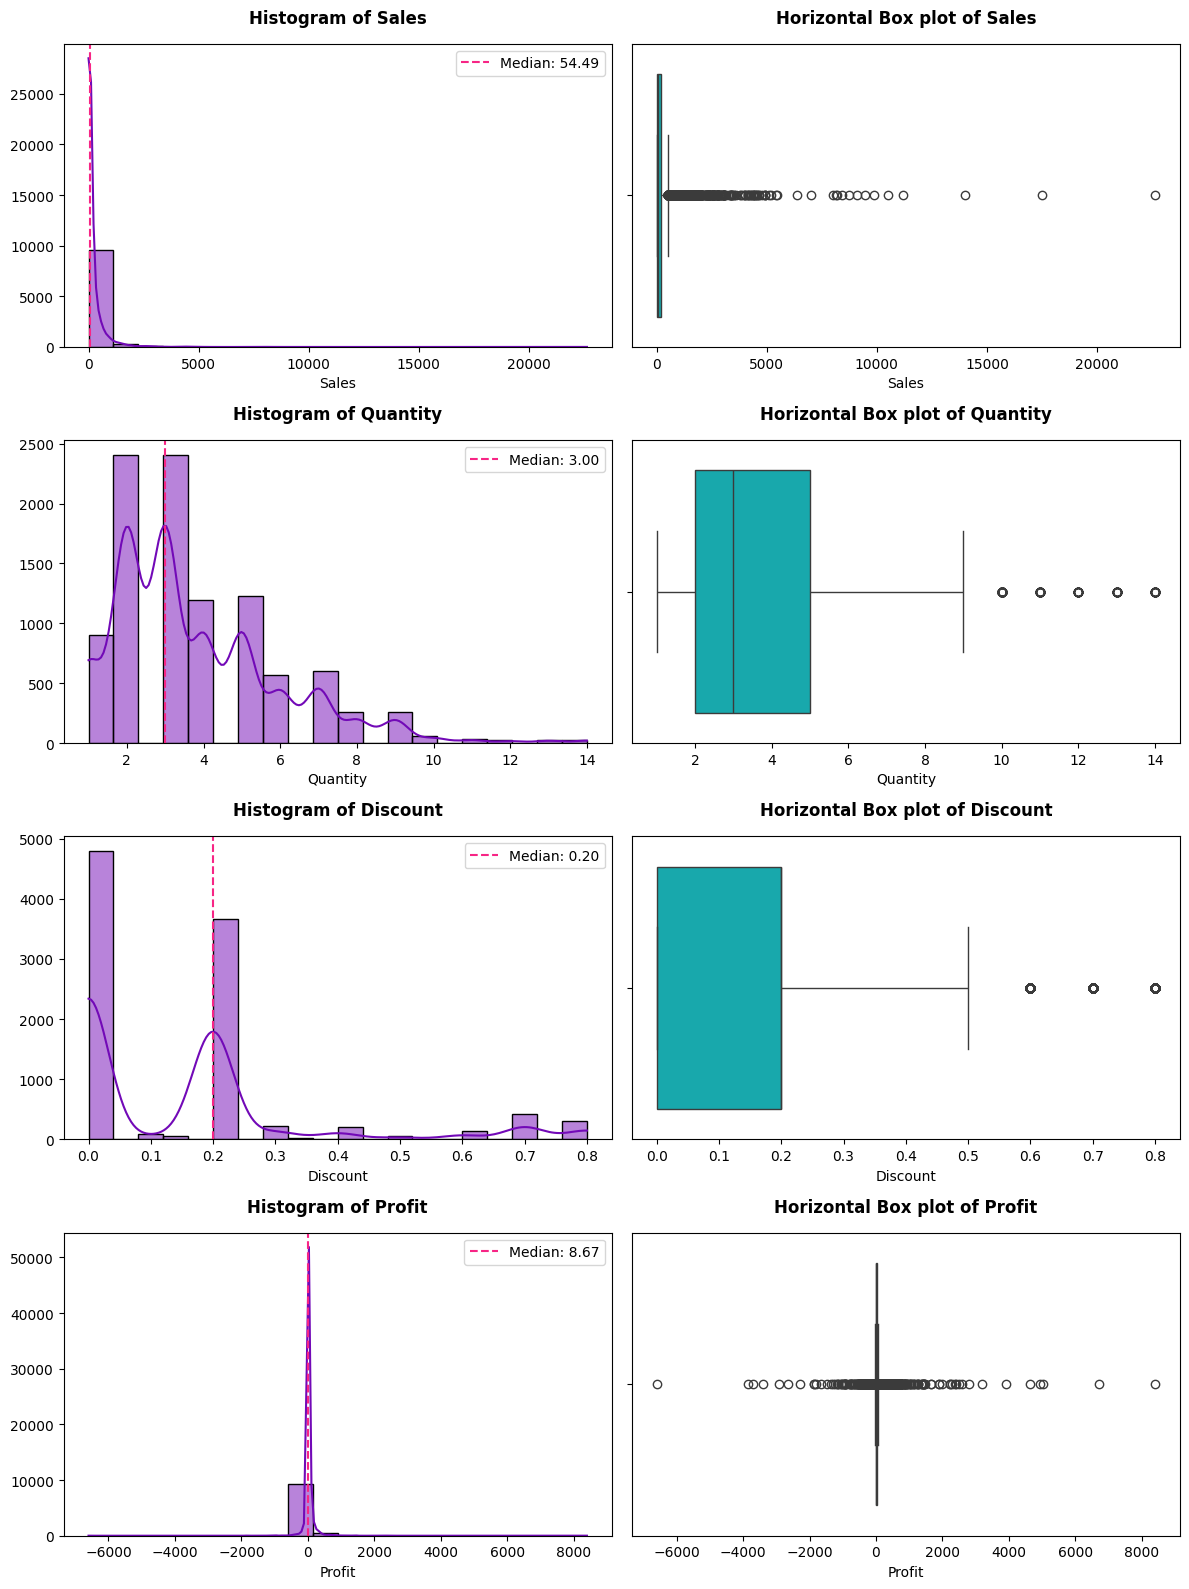

In [12]:
def plot_numerical_features(df=df, numerical_features = num_features):
    """
    Plot histogram and boxplot for each numerical feature.

    - Histogram shows distribution and skewness.
    - Boxplot highlights median and potential outliers.
    """
    # Create subplot grid: one row per feature, 2 columns (histogram + boxplot)
    fig, ax = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features)*4))
    # Ensure ax is always 2D for consistent indexing
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(numerical_features):
        # Histogram with KDE
        sns.histplot(data=df[feature], color="#7209b7", bins = 20, kde=True, ax=ax[i, 0])
        ax[i, 0].set_title(f"Histogram of {feature}", fontsize=12, pad=15, weight="bold")
        ax[i, 0].set_ylabel("")
        # Median reference line
        ax[i, 0].axvline(df[feature].median(), color="#f72585", linestyle="--", label=f"Median: {df[feature].median():.2f}")
        ax[i, 0].legend()

        # Horizontal boxplot for outlier visualization
        sns.boxplot(data=df[feature], color="#00BFC4", orient="h", ax=ax[i, 1])
        ax[i, 1].set_title(f"Horizontal Box plot of {feature}", fontsize=12, pad=15, weight="bold")
        ax[i, 1].set_xlabel(feature)

     # Adjust layout to prevent overlapping
    plt.tight_layout()
    plt.show()

# Run visualization for numerical features
plot_numerical_features()

In [13]:
def check_skewness(data, dataset_name, numerical_features=num_features, sort=True, logger=logger):
    """
    Analyze skewness of numerical features in a dataset and log summary insights.

    This function computes the skewness for each numerical feature, optionally
    sorts them by absolute skewness, and categorizes features based on the
    degree of skewness. Detailed results are logged at DEBUG level, while
    high-level insights and recommendations are logged at INFO level.

    Parameters
    ----------
    data : pandas.DataFrame
        The input dataset containing numerical features to be analyzed.

    dataset_name : str
        A descriptive name of the dataset, used for logging and reporting.

    numerical_features : list of str, optional
        List of numerical feature names to evaluate.
        Default is `num_features`.

    sort : bool, optional (default=True)
        If True, sort features by absolute skewness in descending order.

    logger : logging.Logger
        Logger object used to output analysis results and insights.

    Returns
    -------
    list of str
        A list of feature names that are considered highly skewed
        (|skewness| > 1).

    Notes
    -----
    - Skewness interpretation:
        * |skew| ≤ 0.5  : Approximately symmetric
        * 0.5 < |skew| ≤ 1 : Moderately skewed
        * |skew| > 1   : Highly skewed
    - Highly skewed features may benefit from transformations such as:
        log, Box-Cox, or Yeo-Johnson.
    - This function is intended for exploratory data analysis (EDA)
      and feature preprocessing stages.
    """

    skewness_dict = {}
    skew_features = []
    for feature in numerical_features:
        skew = data[feature].skew(skipna=True)
        skewness_dict[feature] = skew

    skew_df = pd.DataFrame.from_dict(skewness_dict, orient="index", columns=["Skewness"])
    if sort:
        skew_df = skew_df.reindex(skew_df["Skewness"].abs().sort_values(ascending=False).index)

    # ===== Summary header =====
    logger.info(f"Skewness analysis for {dataset_name}")
    logger.info(f"Total numerical features checked: {len(skew_df)}")

    # ===== Detailed table (DEBUG) =====
    logger.debug("-"*70)
    logger.debug(f"{'Feature':<30} | {'Skewness':<9} | {'Remark'}")
    logger.debug("-"*70)
    for feature, row in skew_df.iterrows():
        skew = row["Skewness"]
        abs_skew = abs(skew)
        if abs_skew > 1:
            remark = "Highly skewed"
            skew_features.append(feature)
        elif abs_skew > 0.5:
            remark = "Moderately skewed"
        else:
            remark = "Approximately symmetric"
        logger.debug(f"{feature:<30} | {skew:>+9.4f} | {remark}")
    logger.debug("-" * 70)

    # ===== Summary insight =====
    if skew_features:
        logger.info(f"{len(skew_features)} features are highly skewed (|skew| > 1).")
        logger.info(f"Recommendation: Consider log / Box-Cox / Yeo-Johnson transformation.")
    else:
        logger.info("No highly skewed features detected.")

    return skew_features

skew_feature = check_skewness(df, "Data Superstore")
logger.info("-" * 70)
logger.info("Checking skewness successfully completed the dataset.")

2026-06-01 17:20:45 | INFO | Skewness analysis for Data Superstore
2026-06-01 17:20:45 | INFO | Total numerical features checked: 4
2026-06-01 17:20:45 | DEBUG | ----------------------------------------------------------------------
2026-06-01 17:20:45 | DEBUG | Feature                        | Skewness  | Remark
2026-06-01 17:20:45 | DEBUG | ----------------------------------------------------------------------
2026-06-01 17:20:45 | DEBUG | Sales                          |  +12.9728 | Highly skewed
2026-06-01 17:20:45 | DEBUG | Profit                         |   +7.5614 | Highly skewed
2026-06-01 17:20:45 | DEBUG | Discount                       |   +1.6843 | Highly skewed
2026-06-01 17:20:45 | DEBUG | Quantity                       |   +1.2785 | Highly skewed
2026-06-01 17:20:45 | DEBUG | ----------------------------------------------------------------------
2026-06-01 17:20:45 | INFO | 4 features are highly skewed (|skew| > 1).
2026-06-01 17:20:45 | INFO | Recommendation: Consider l

**Insight**

* **All numerical features are highly right-skewed** (|skew| > 1), indicating **non-normal distributions** across core business metrics.

* **Sales (skew ≈ +13.0)**
  → Extremely right-skewed, driven by a **small number of very large orders** dominating total revenue.

* **Profit (skew ≈ +7.6)**
  → Strong right skew with **extreme gains and losses**, highlighting **high volatility in profitability**.

* **Discount (skew ≈ +1.7)**
  → Skewed toward low values, as **most transactions receive little or no discount**, with few aggressive promotions.

* **Quantity (skew ≈ +1.3)**
  → Right skew caused by **occasional bulk purchases** beyond typical order sizes.

## Categorical Feature Distributions

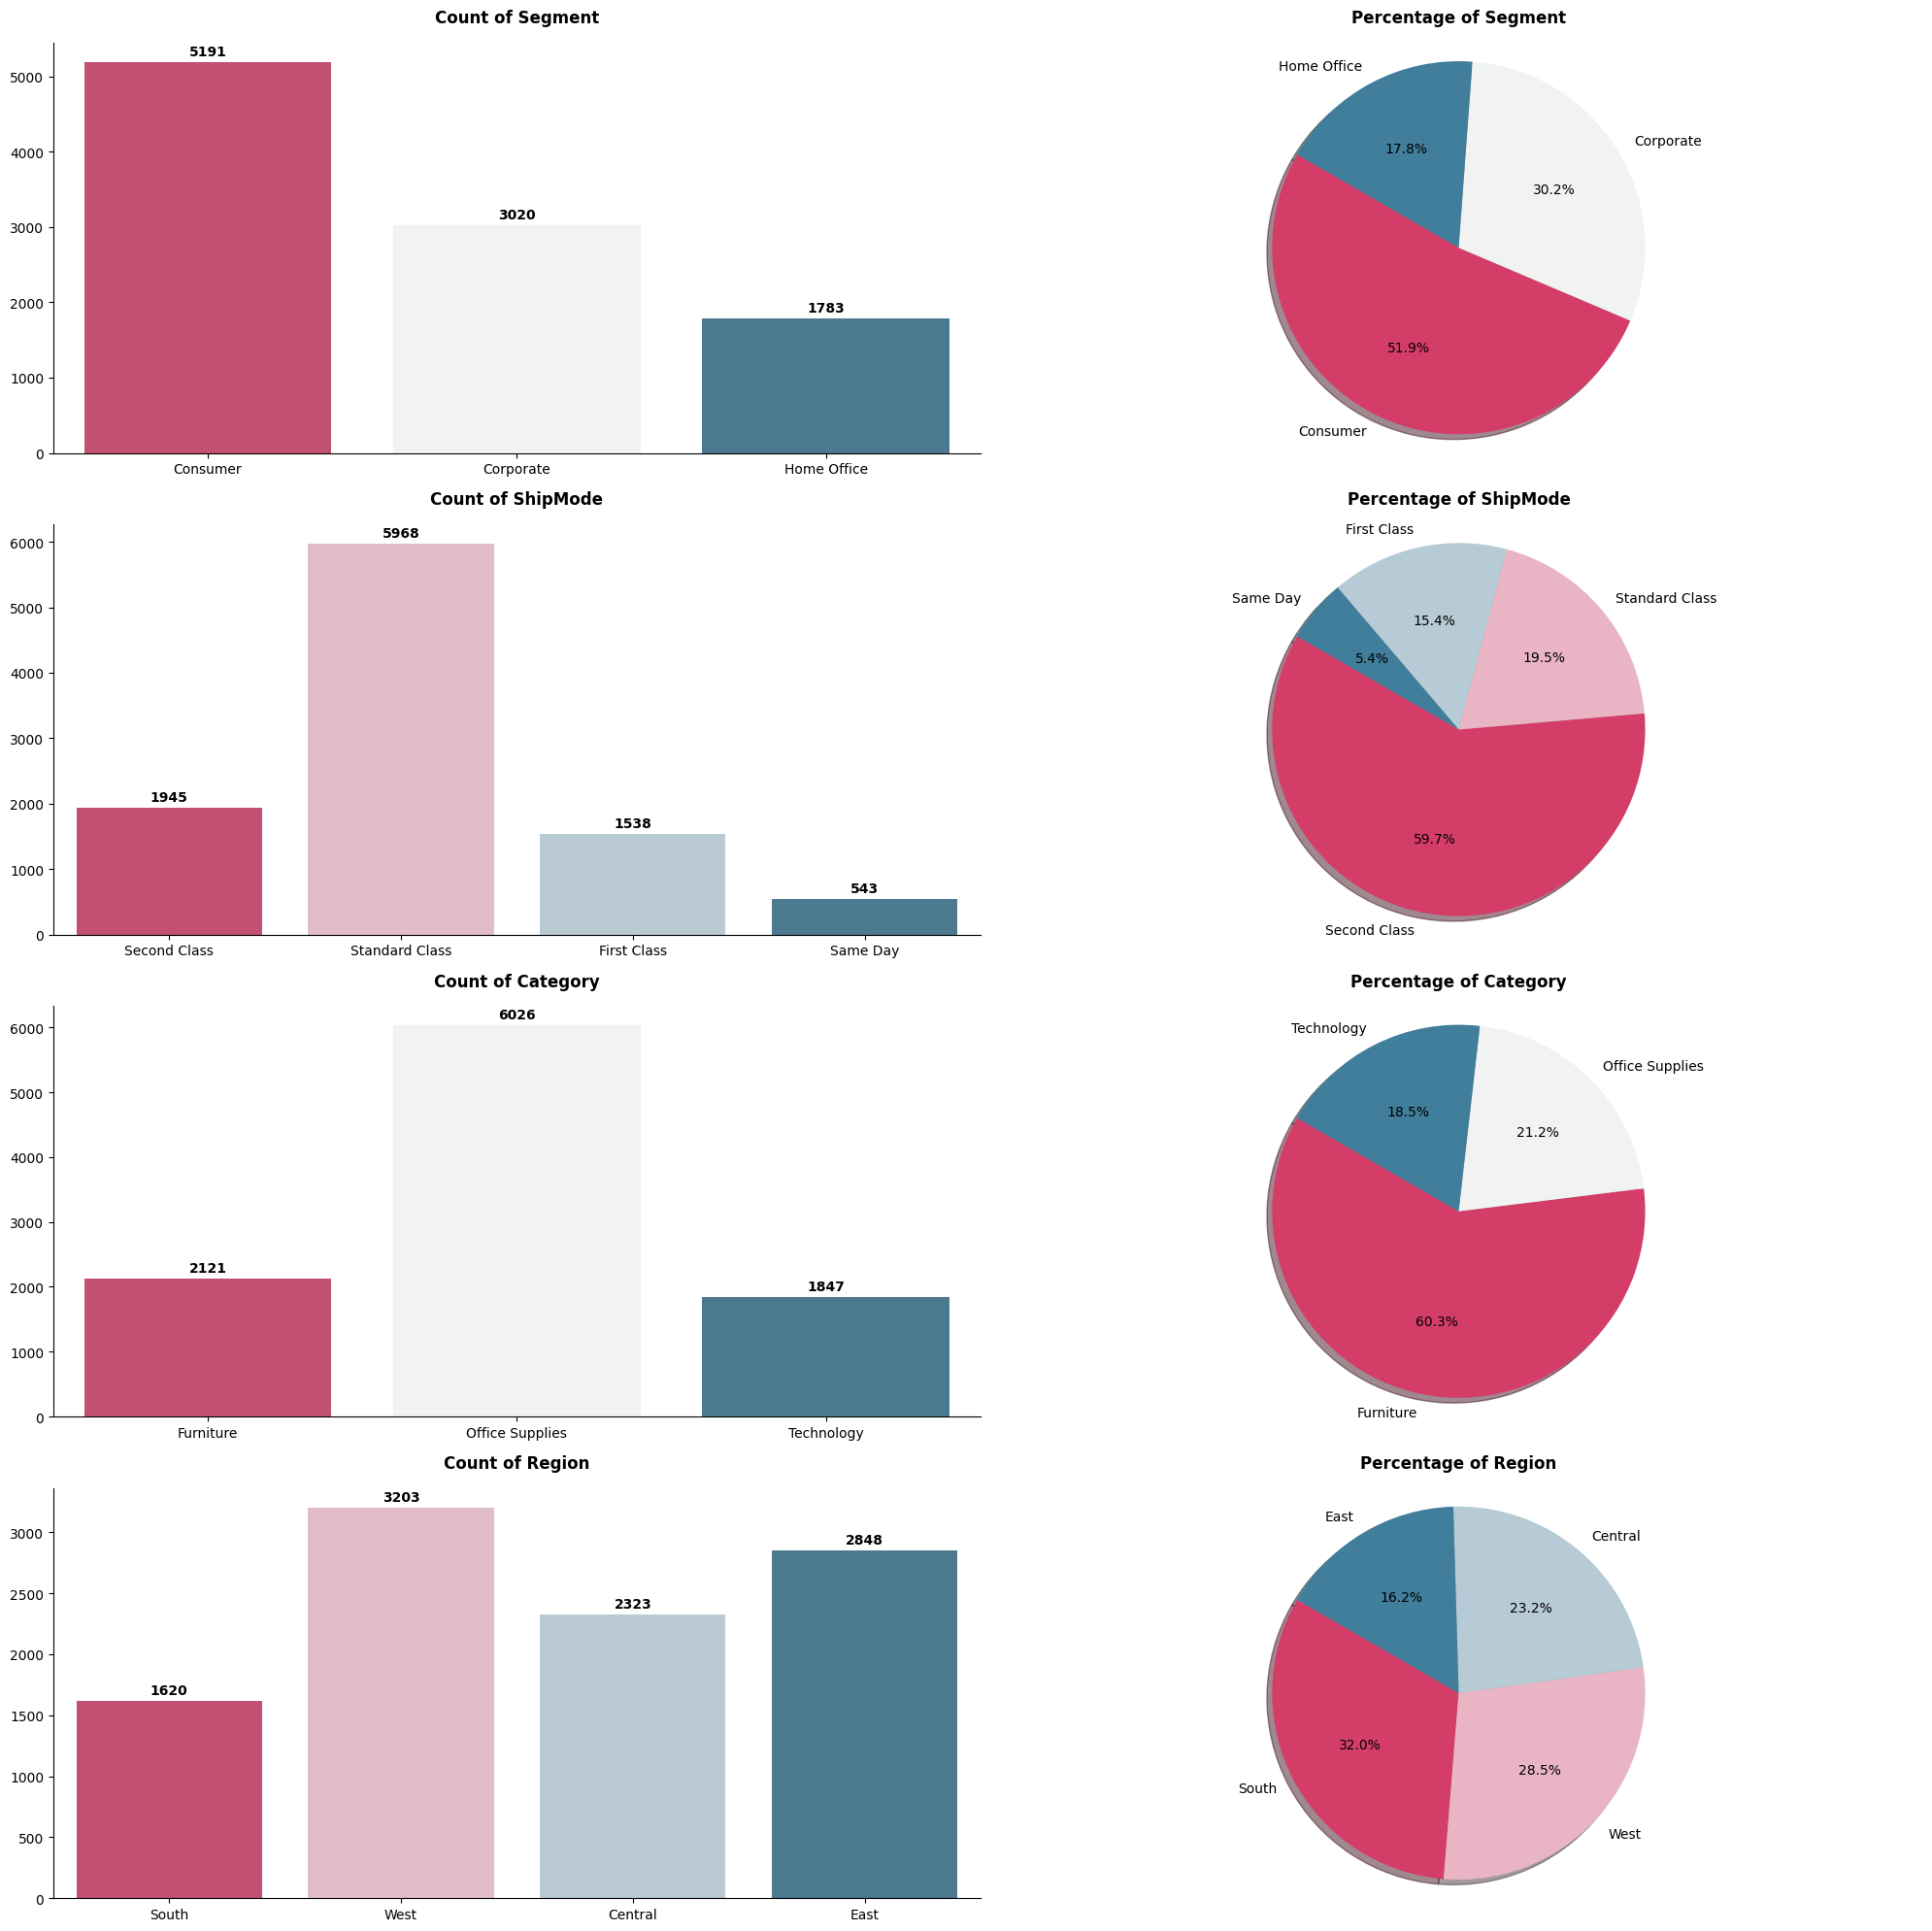

In [14]:
cat_features_2 = ["Segment", "ShipMode", "Category", "Region"]
def plot_categorical_distribution(df, cat_features):
    """
    Plot count and percentage distribution for categorical features.

    - Left: countplot with value labels.
    - Right: pie chart showing percentage distribution.
    """
    # Create subplot grid: one row per feature, 2 columns (countplot + pie)
    fig, ax = plt.subplots(len(cat_features), 2, figsize=(20, len(cat_features) * 5))
    ax = np.atleast_2d(ax)

    for i, feature in enumerate(cat_features):
        # Preserve original category order
        order_feature = df[feature].unique().tolist()

        # LEFT: Countplot for frequency distribution
        sns.countplot(data=df, x=feature, ax=ax[i, 0], palette=color(n_colors=len(df[feature].unique())), 
                      order=order_feature)
        ax[i, 0].set_title(f"Count of {feature}", fontsize=12, pad=15, weight="bold")
        ax[i, 0].set_xlabel("")
        ax[i, 0].set_ylabel("")
        sns.despine(ax=ax[i, 0], top=True, right=True)

        # Add count labels on bars
        for p in ax[i, 0].patches:
            height = p.get_height()
            x = p.get_x() + p.get_width() / 2
            ax[i, 0].text(x, height + max(df[feature].value_counts()) * 0.01,
                          f"{int(height)}", ha="center", va="bottom",
                          fontsize=10, fontweight="bold")

        # RIGHT: Pie chart for percentage distribution
        feature_counts = df[feature].value_counts(normalize=True)
        sizes = feature_counts.values * 100  # percentage
        colors = color(n_colors=len(df[feature].unique()))

        wedges, texts, autotexts = ax[i, 1].pie(
            sizes, labels=order_feature, autopct="%1.1f%%", shadow= True,
            startangle=150, colors=colors, textprops={"fontsize": 10}
        )
        ax[i, 1].set_title(f"Percentage of {feature}", fontsize=12, pad=15, weight="bold")
        ax[i, 1].axis("equal")

    # Adjust layout to avoid overlapping
    plt.tight_layout()
    plt.show()

# Run categorical distribution plots
plot_categorical_distribution(df=df, cat_features=cat_features_2)

## RFM Analysis

In [15]:
# Define the reference date = the latest order date + 1 day
# +1 day is added to avoid Recency = 0 for customers who ordered on the last day
recency_date = df["OrderDate"].max() + pd.Timedelta(days=1)

# Calculate RFM for each customer (CustomerID)
df_rfm = df.groupby("CustomerID").agg({
    # Recency = (reference date - most recent transaction date of the customer)
    "OrderDate": lambda x: (recency_date - x.max()).days,

    # Frequency = number of order (count unique OrderID)
    "OrderID": "nunique",

    # Monetary = total_sales
    "Sales": "sum"
}).reset_index()

# Rename columns for better readability
df_rfm.columns = ["CustomerID", "recency", "frequency", "monetary"]
display(df_rfm.head())

,CustomerID,recency,frequency,monetary
0,AA-10315,185,5,5563.560
1,AA-10375,20,9,1056.390
2,AA-10480,260,4,1790.512
3,AA-10645,56,6,5086.935
4,AB-10015,416,3,886.156


In [16]:
# R score: lower recency (more recent purchase) → higher score
P20 = df_rfm["recency"].quantile(0.2)
P40 = df_rfm["recency"].quantile(0.4)
P60 = df_rfm["recency"].quantile(0.6)
P80 = df_rfm["recency"].quantile(0.8)

conditions = [
    df_rfm["recency"] <= P20,
    df_rfm["recency"] <= P40,
    df_rfm["recency"] <= P60,
    df_rfm["recency"] <= P80
]
choices = [5, 4, 3, 2]

df_rfm["r_score"] = np.select(conditions, choices, default=1)

# F score: higher purchase frequency → higher score
P20 = df_rfm["frequency"].quantile(0.2)
P40 = df_rfm["frequency"].quantile(0.4)
P60 = df_rfm["frequency"].quantile(0.6)
P80 = df_rfm["frequency"].quantile(0.8)

conditions = [
    df_rfm["frequency"] >= P80,
    df_rfm["frequency"] >= P60,
    df_rfm["frequency"] >= P40,
    df_rfm["frequency"] >= P20
]
choices = [5, 4, 3, 2]

df_rfm["f_score"] = np.select(conditions, choices, default=1)

# M score: higher monetary value → higher score
P20 = df_rfm["monetary"].quantile(0.2)
P40 = df_rfm["monetary"].quantile(0.4)
P60 = df_rfm["monetary"].quantile(0.6)
P80 = df_rfm["monetary"].quantile(0.8)

conditions = [
    df_rfm["monetary"] >= P80,
    df_rfm["monetary"] >= P60,
    df_rfm["monetary"] >= P40,
    df_rfm["monetary"] >= P20
]
choices = [5, 4, 3, 2]

df_rfm["m_score"] = np.select(conditions, choices, default=1)

# Combine R, F, M scores into a 3-digit RFM score
df_rfm["rfm_score"] = (
    df_rfm["r_score"].astype(str)
    + df_rfm["f_score"].astype(str)
    + df_rfm["m_score"].astype(str)
)

# Map RFM score to business-defined customer segments
df_rfm["rfm_segment"] = df_rfm["rfm_score"].apply(config.rfm_segment)
display(df_rfm.head())

,CustomerID,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,rfm_segment
0,AA-10315,185,5,5563.560,2,3,5,235,At Risk
1,AA-10375,20,9,1056.390,5,5,2,552,Potential Loyalist
2,AA-10480,260,4,1790.512,1,2,3,123,Hibernating Customers
3,AA-10645,56,6,5086.935,3,3,5,335,Loyal
4,AB-10015,416,3,886.156,1,1,1,111,Lost Customers


In [17]:
# 1. Merge transaction data with RFM segmentation
#    - Join df (transaction-level) with df_rfm (customer-level RFM segment)
df_merged = df.merge(
    df_rfm[["CustomerID", "rfm_segment"]],
    on="CustomerID",
    how="inner"
)

# 2. Create derived metric: Spend
#    - Spend represents actual customer spending
#    - Formula: Spend = Sales - Profit
df_merged["Spend"] = df_merged["Sales"] - df_merged["Profit"]

# 3. Create RFM summary DataFrame
summary_rfm_df = (
    df_merged
    .groupby("rfm_segment", as_index=False)
    .agg(
        customer_count=("CustomerID", "nunique"),   # Number of unique customers per segment
        total_sales=("Sales", "sum"),               # Total sales revenue
        total_quantity=("Quantity", "sum"),         # Total units sold
        total_discount=("Discount", "sum"),         # Total discount amount
        total_spend=("Spend", "sum"),               # Net customer spend
        total_profit=("Profit", "sum")              # Total profit
    )
    .sort_values("total_sales", ascending=False)    # Show largest segments first
    .reset_index(drop=True)
)

# 4. Create styled table for presentation (PRESENTATION LAYER)
#    - Styling is applied ONLY for display
#    - Does not affect the underlying DataFrame
summary_rfm_style = (
    summary_rfm_df
    .style
    .set_caption("RFM Summary by Segment")
    
    # Format numeric columns
    .format({
        "total_sales": "{:,.2f}",
        "total_discount": "{:,.2f}",
        "total_profit": "{:,.2f}",
        "total_spend": "{:,.2f}"
    })
    
    # Style table header and caption
    .set_table_styles([
        {"selector": "th", "props": [("text-align", "center")]},
        {"selector": "caption", "props": [
            ("caption-side", "top"),
            ("font-size", "16px"),
            ("font-weight", "bold")
        ]}
    ])
    
    # Apply general cell properties
    .set_properties(**{
        "text-align": "center",
        "font-size": "12px"
    })
    
    # Apply color gradient to highlight magnitude differences
    .background_gradient(
        subset=[
            "customer_count", "total_sales", "total_quantity",
            "total_discount", "total_spend", "total_profit"
        ],
        cmap="Blues"
    )
)

# 5. Display styled RFM summary table
display(summary_rfm_style)

,rfm_segment,customer_count,total_sales,total_quantity,total_discount,total_spend,total_profit
0,Champions,100,"540,868.28",7470,313.88,"473,264.02","67,604.26"
1,At Risk,124,"508,436.18",6999,270.71,"428,856.83","79,579.35"
2,Loyal,89,"430,183.87",5634,230.35,"389,177.49","41,006.38"
3,Potential Loyalist,133,"215,023.39",6287,267.53,"192,151.27","22,872.12"
4,Need Attention,64,"211,235.77",3172,121.09,"180,845.46","30,390.30"
5,Hibernating Customers,98,"146,886.14",3305,138.47,"132,914.38","13,971.76"
6,Cannot Lose Them,18,"92,188.60",1131,40.20,"74,207.61","17,980.99"
7,Promising,21,"59,421.33",650,23.75,"51,733.79","7,687.54"
8,Lost Customers,71,"44,504.84",1420,64.52,"44,861.63",-356.79
9,About To Sleep,38,"25,191.01",1084,59.72,"21,674.98","3,516.03"


2026-06-01 17:20:46 | INFO | Pareto Analysis of Total Sales by RFM Segment


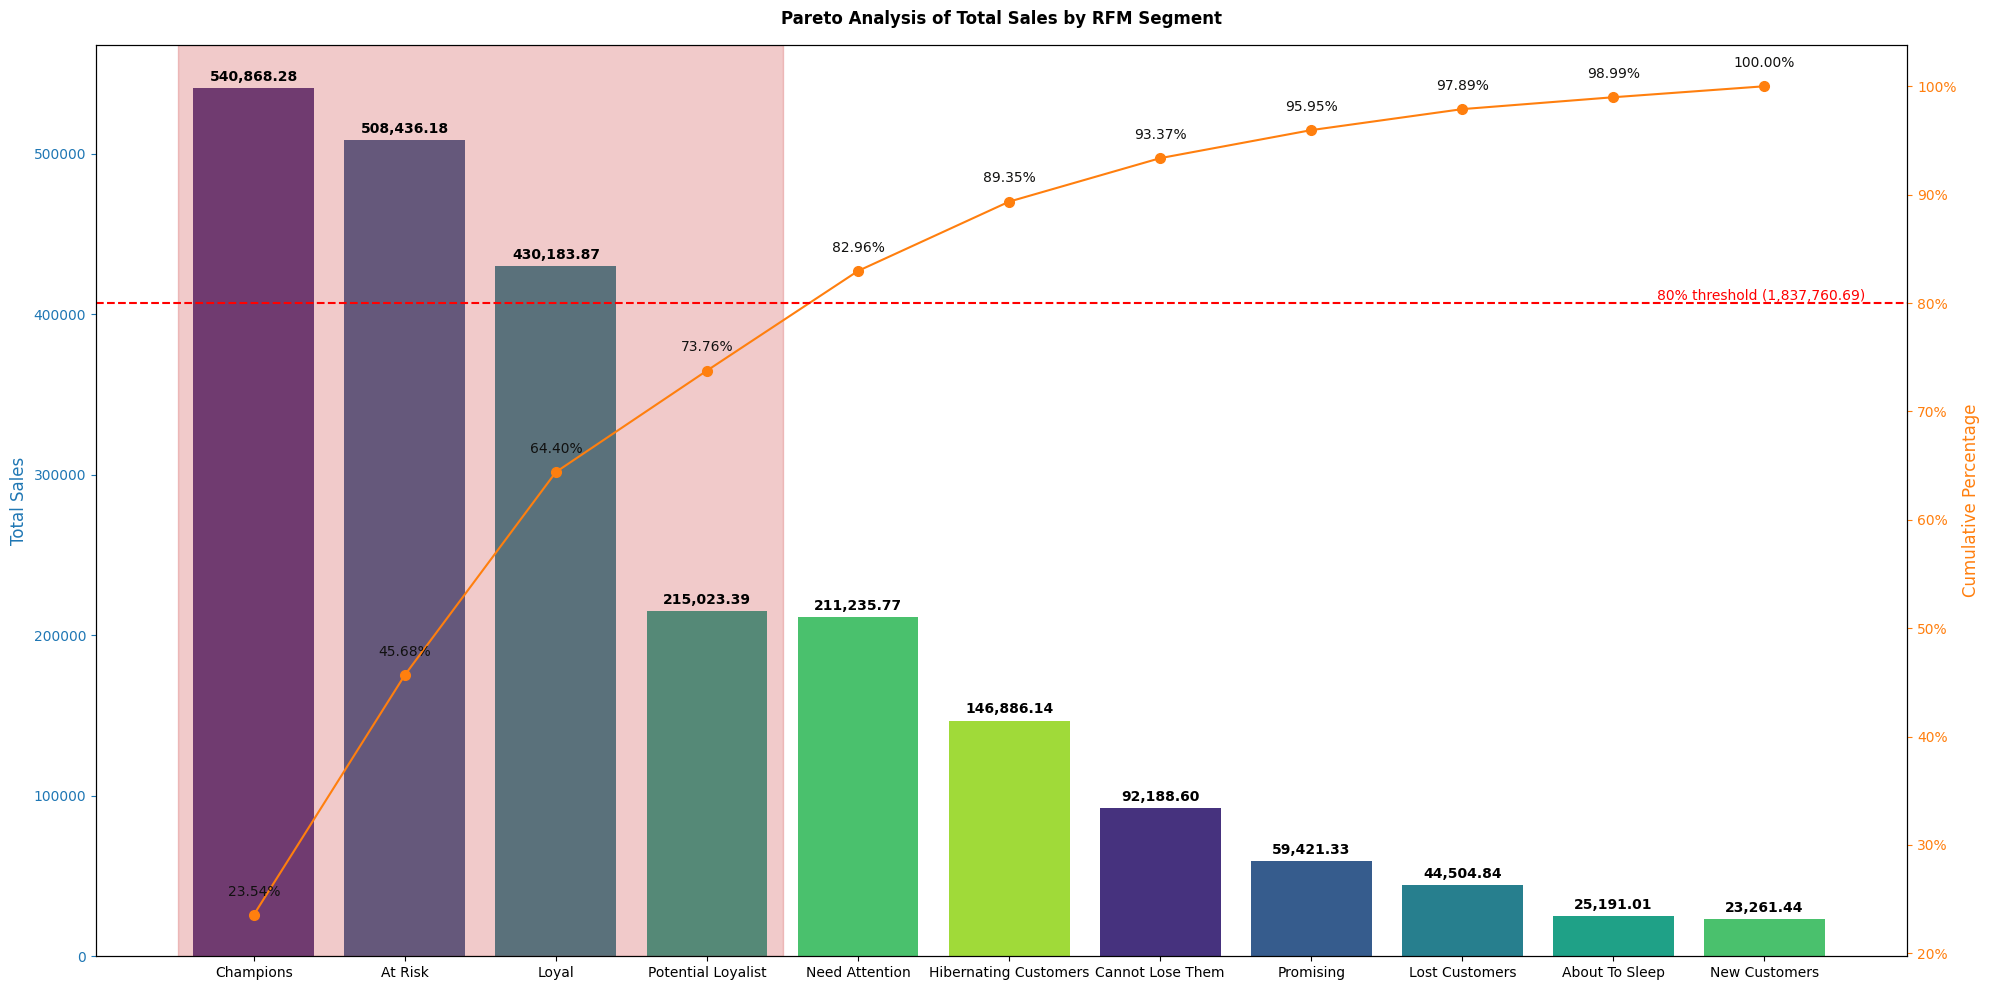

2026-06-01 17:20:46 | INFO | Pareto Analysis of Total Quantity by RFM Segment


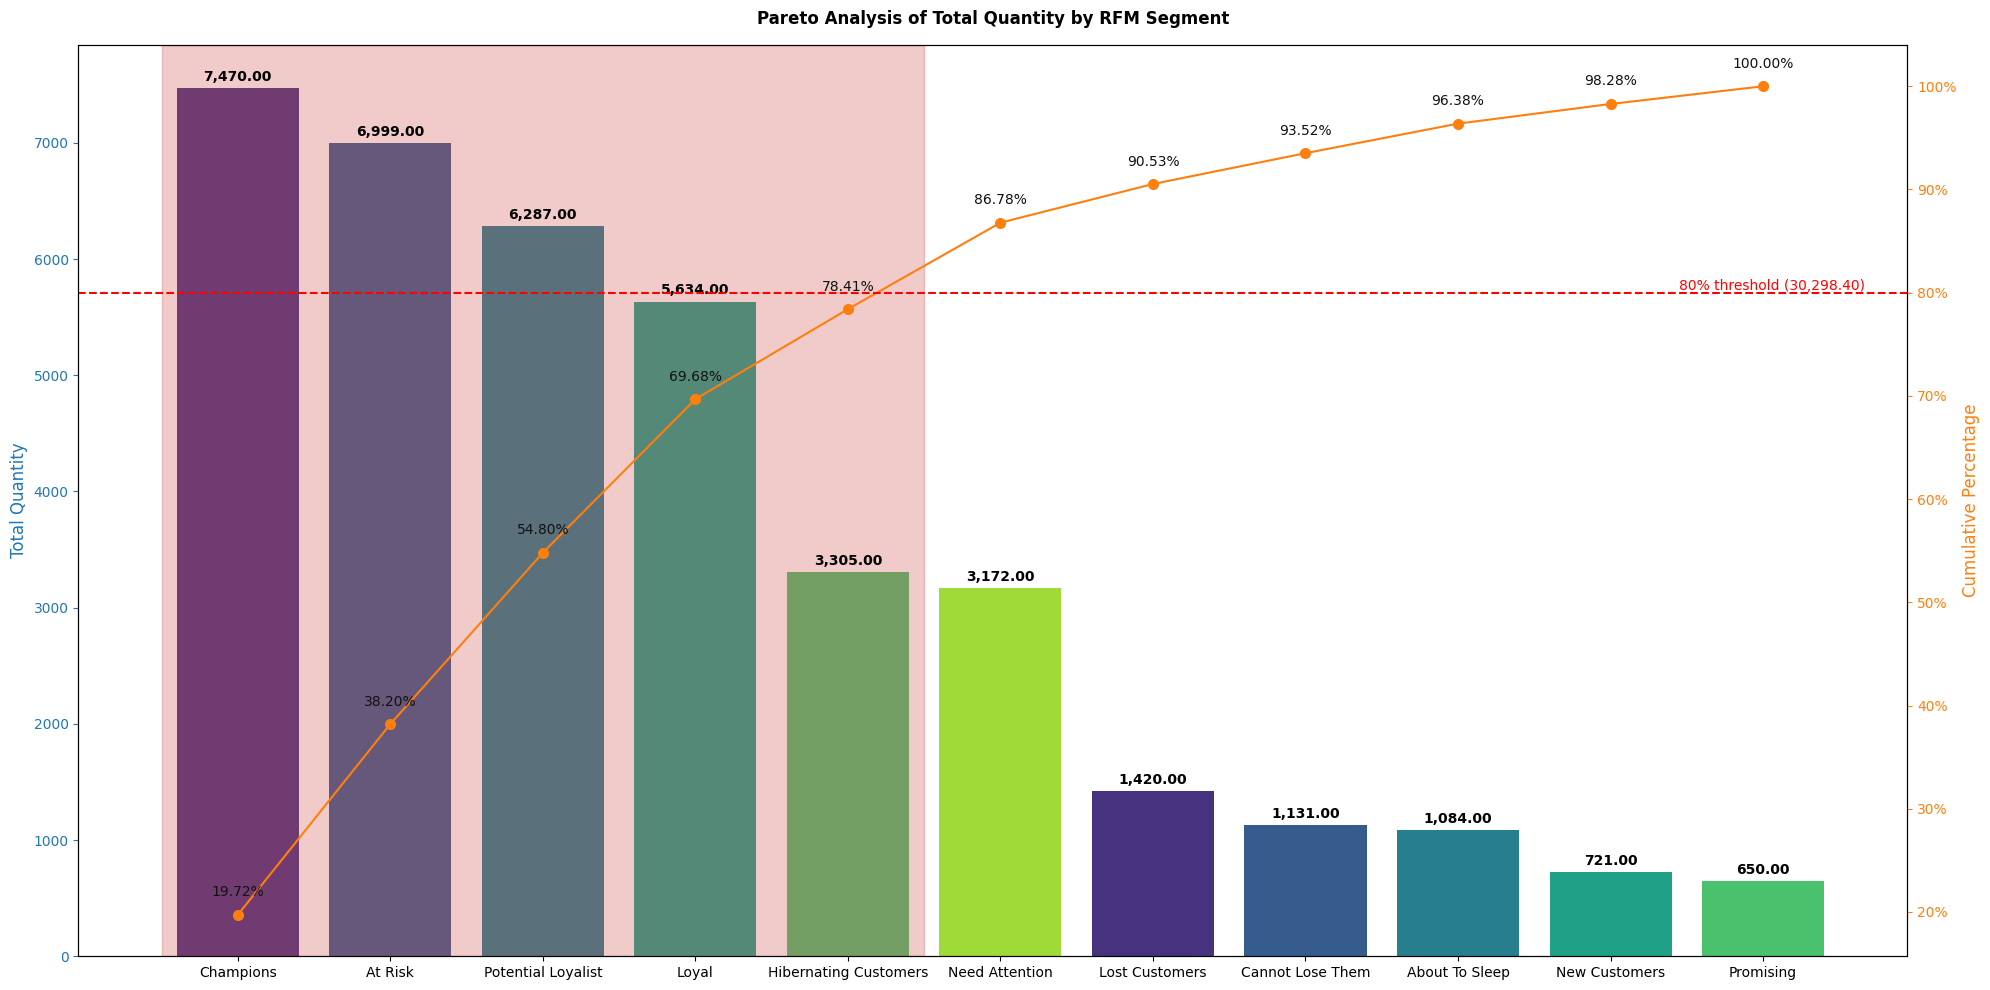

2026-06-01 17:20:47 | INFO | Pareto Analysis of Total Discount by RFM Segment


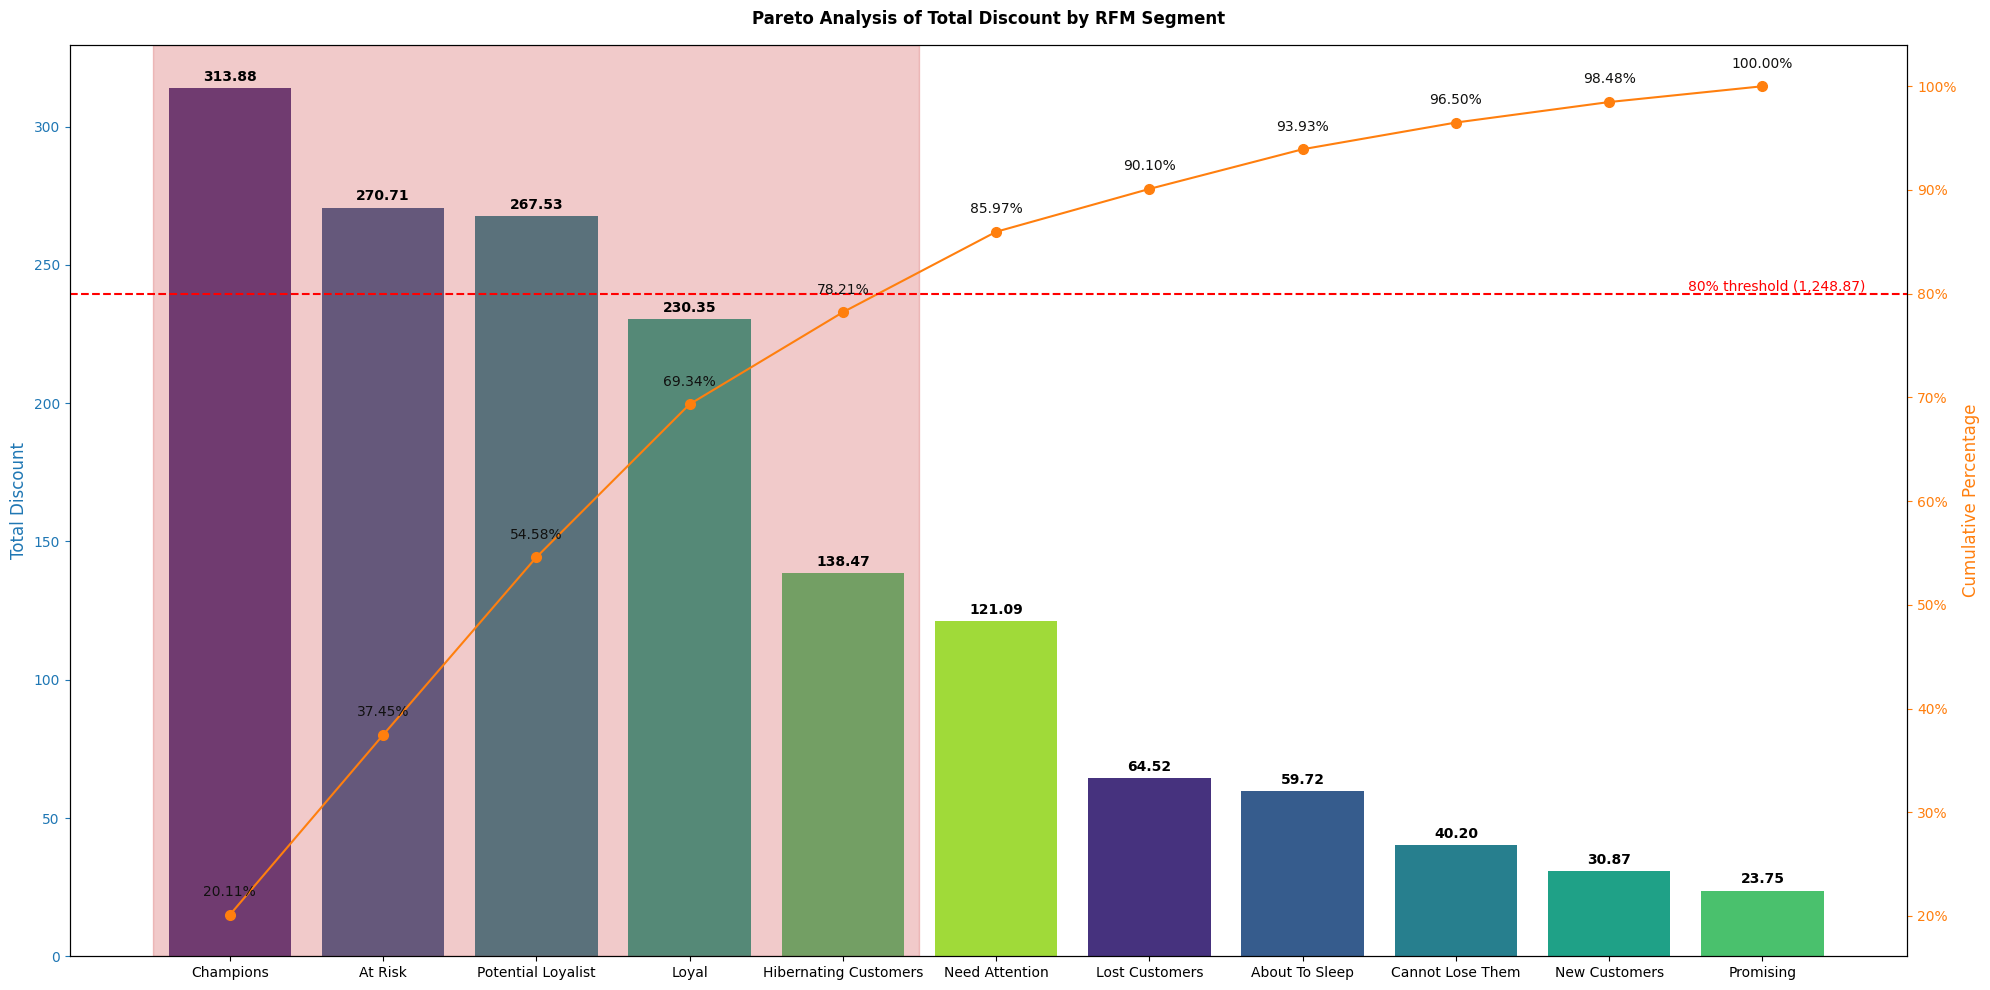

2026-06-01 17:20:47 | INFO | Pareto Analysis of Total Spend by RFM Segment


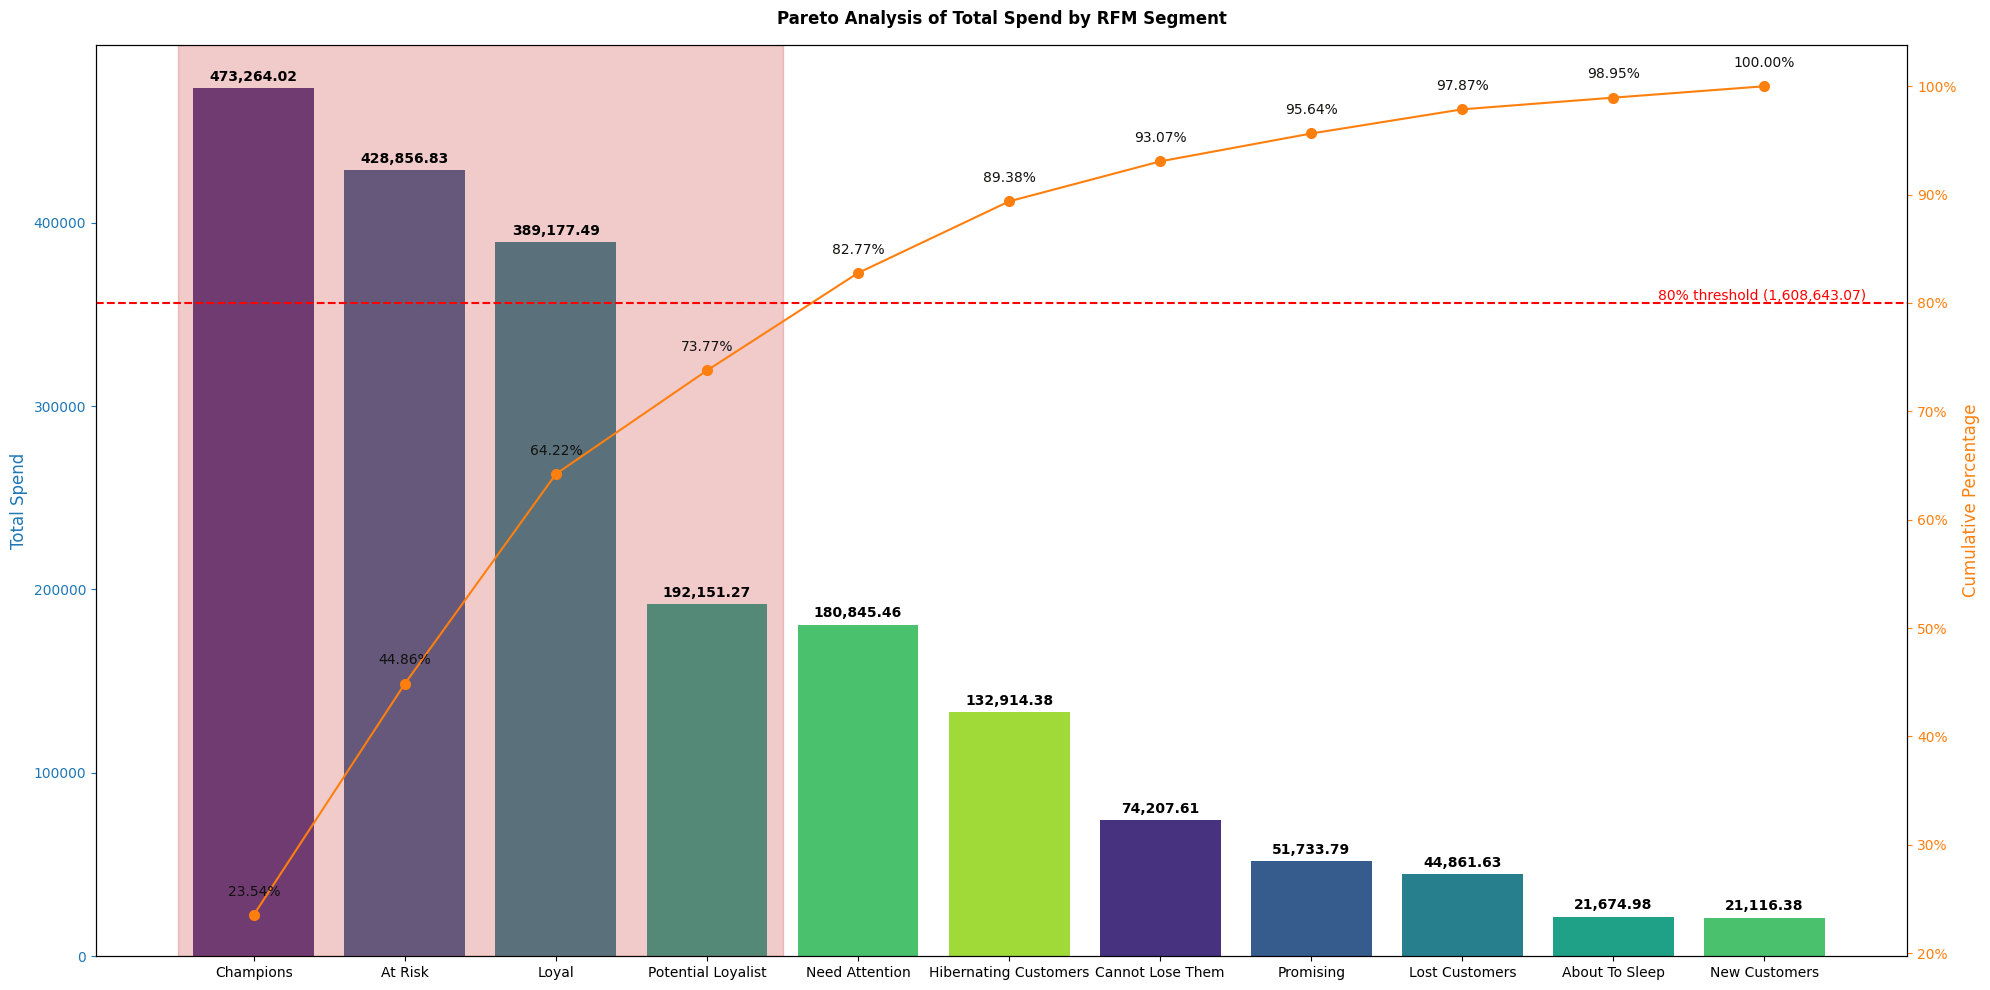

2026-06-01 17:20:47 | INFO | Pareto Analysis of Total Profit by RFM Segment


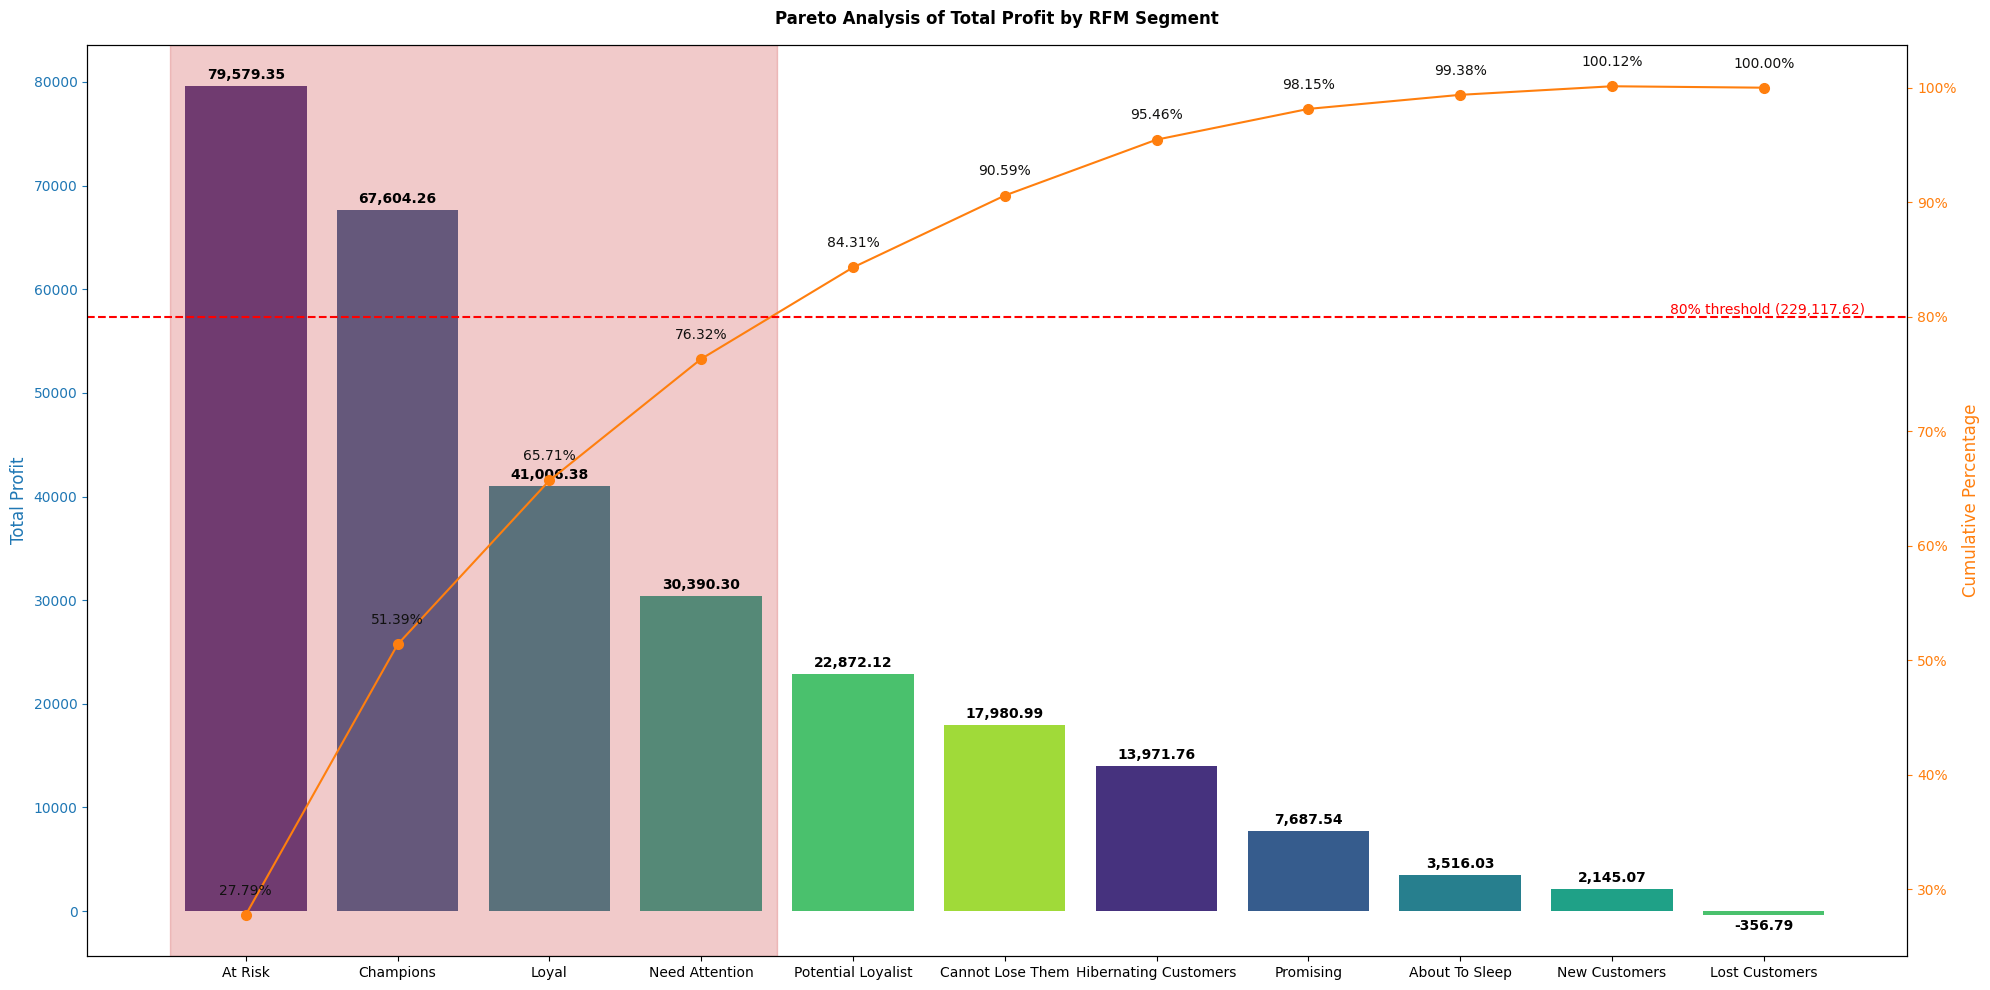

In [18]:
def pareto_analysis(feature="total_sales", summary_rfm_df=summary_rfm_df):
    """Plot Pareto chart to identify top 80% contributing RFM segments."""

    # Sort segments by selected metric (descending)
    summary_rfm_pareto = summary_rfm_df.sort_values(
        by=feature, ascending=False
    ).reset_index(drop=True)

    # Calculate cumulative percentage
    summary_rfm_pareto["cumpercentage"] = (
        summary_rfm_pareto[feature].cumsum()
        / summary_rfm_pareto[feature].sum() * 100
    )

    # Flag segments contributing to top 80%
    summary_rfm_pareto["Top80"] = summary_rfm_pareto["cumpercentage"] <= 80

    # Initialize Pareto chart
    fig, ax = plt.subplots(figsize=(20, 10))

    palette = color(n_colors=summary_rfm_pareto["rfm_segment"].nunique(), tone="viridis")
    bars = ax.bar(
        summary_rfm_pareto["rfm_segment"],
        summary_rfm_pareto[feature],
        color=palette
    )

    # Highlight background area for top 80%
    cutoff_index = summary_rfm_pareto[summary_rfm_pareto["Top80"]].index.max()
    ax.axvspan(-0.5, cutoff_index + 0.5, color="#d35252", alpha=0.3)

    # Add value labels on bars
    ax.bar_label(
        bars,
        labels=[f"{v:,.2f}" for v in summary_rfm_pareto[feature]],
        padding=3,
        fontsize=10,
        color="black",
        weight="bold"
    )

    # Plot cumulative percentage line
    ax1 = ax.twinx()
    ax1.plot(
        summary_rfm_pareto["rfm_segment"],
        summary_rfm_pareto["cumpercentage"],
        color="#ff7f0e",
        marker="o",
        ms=7
    )
    ax1.yaxis.set_major_formatter(PercentFormatter())

    for x, y in zip(summary_rfm_pareto["rfm_segment"], summary_rfm_pareto["cumpercentage"]):
        ax1.text(x, y + 1.5, f"{y:.2f}%", color="#111110", fontsize=10, ha="center", va="bottom")

    # Draw 80% threshold line and label
    total_m_sum = summary_rfm_pareto[feature].sum()
    threshold_80_value = total_m_sum * 0.8
    ax1.axhline(80, color="red", linestyle="--", linewidth=1.5)
    ax1.text(
        len(summary_rfm_pareto) * 0.97,
        80,
        f"80% threshold ({threshold_80_value:,.2f})",
        color="red",
        fontsize=10,
        ha="right",
        va="bottom"
    )

    # Axis styling and labels
    ax.set_ylabel(feature.replace("_", " ").title(), color="C0", fontsize=12)
    ax1.set_ylabel("Cumulative Percentage", color="#ff7f0e", fontsize=12)
    ax.tick_params(axis="y", colors="C0")
    ax1.tick_params(axis="y", colors="#ff7f0e")
    # plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.title(f"Pareto Analysis of {feature.replace('_', ' ').title()} by RFM Segment", fontsize=12, pad=15, weight="bold")

    fig.tight_layout()
    plt.show()

for feature in ["total_sales", "total_quantity", "total_discount", "total_spend", "total_profit"]:
    logger.info(f"Pareto Analysis of {feature.replace('_', ' ').title()} by RFM Segment")
    pareto_analysis(feature=feature)

**RFM Pareto – Executive Summary**

* Business value is **highly concentrated**, following the **Pareto (80/20) principle**
* **4 RFM segments** generate **~80% of revenue, volume, spend, and profit**
* **Segment size ≠ profitability**

**Key Segment Insights**

* **Champions**

  * Highest and most stable contributor across sales, spend, and profit
  * Core segment to protect and reward

* **At Risk** *(Most Critical)*

  * **Top profit contributor** with high revenue and spend
  * **High churn risk** → immediate retention priority

* **Loyal & Potential Loyalist**

  * Strong sales and volume
  * Profitability depends on **discount control**

* **Low-value segments** (*Lost / New Customers*)

  * Minimal or negative profit
  * Limited short-term investment value

**Business Actions**

* **Retain & Protect:** At Risk, Champions
* **Optimize Costs:** Reduce ineffective discounts
* **Deprioritize:** Low-profit segments

**Executive One-Liner**

> **~80% of business value comes from four RFM segments, with “At Risk” customers delivering the highest profit yet facing the greatest churn risk—making them the top priority for immediate action.**

## Cohort Analysis

### Customer Retention

In [19]:
df_cohort = df_merged.copy()

# OrderDate
df_cohort["cohort"] = df_cohort.groupby("CustomerID")["OrderDate"].transform("min").dt.to_period("M")
df_cohort["order_month"] = df_cohort["OrderDate"].dt.to_period("M")
# Create cohort dataframe
df_cohort = df_cohort.groupby(["cohort", "order_month"]).agg(n_customers=("CustomerID", "nunique")).reset_index(drop=False)

# period_number
df_cohort["period_number"] = (df_cohort.order_month - df_cohort.cohort).apply(attrgetter("n"))
display(df_cohort.head())

,cohort,order_month,n_customers,period_number
0,2014-01,2014-01,32,0
1,2014-01,2014-02,3,1
2,2014-01,2014-04,2,3
3,2014-01,2014-05,2,4
4,2014-01,2014-07,2,6


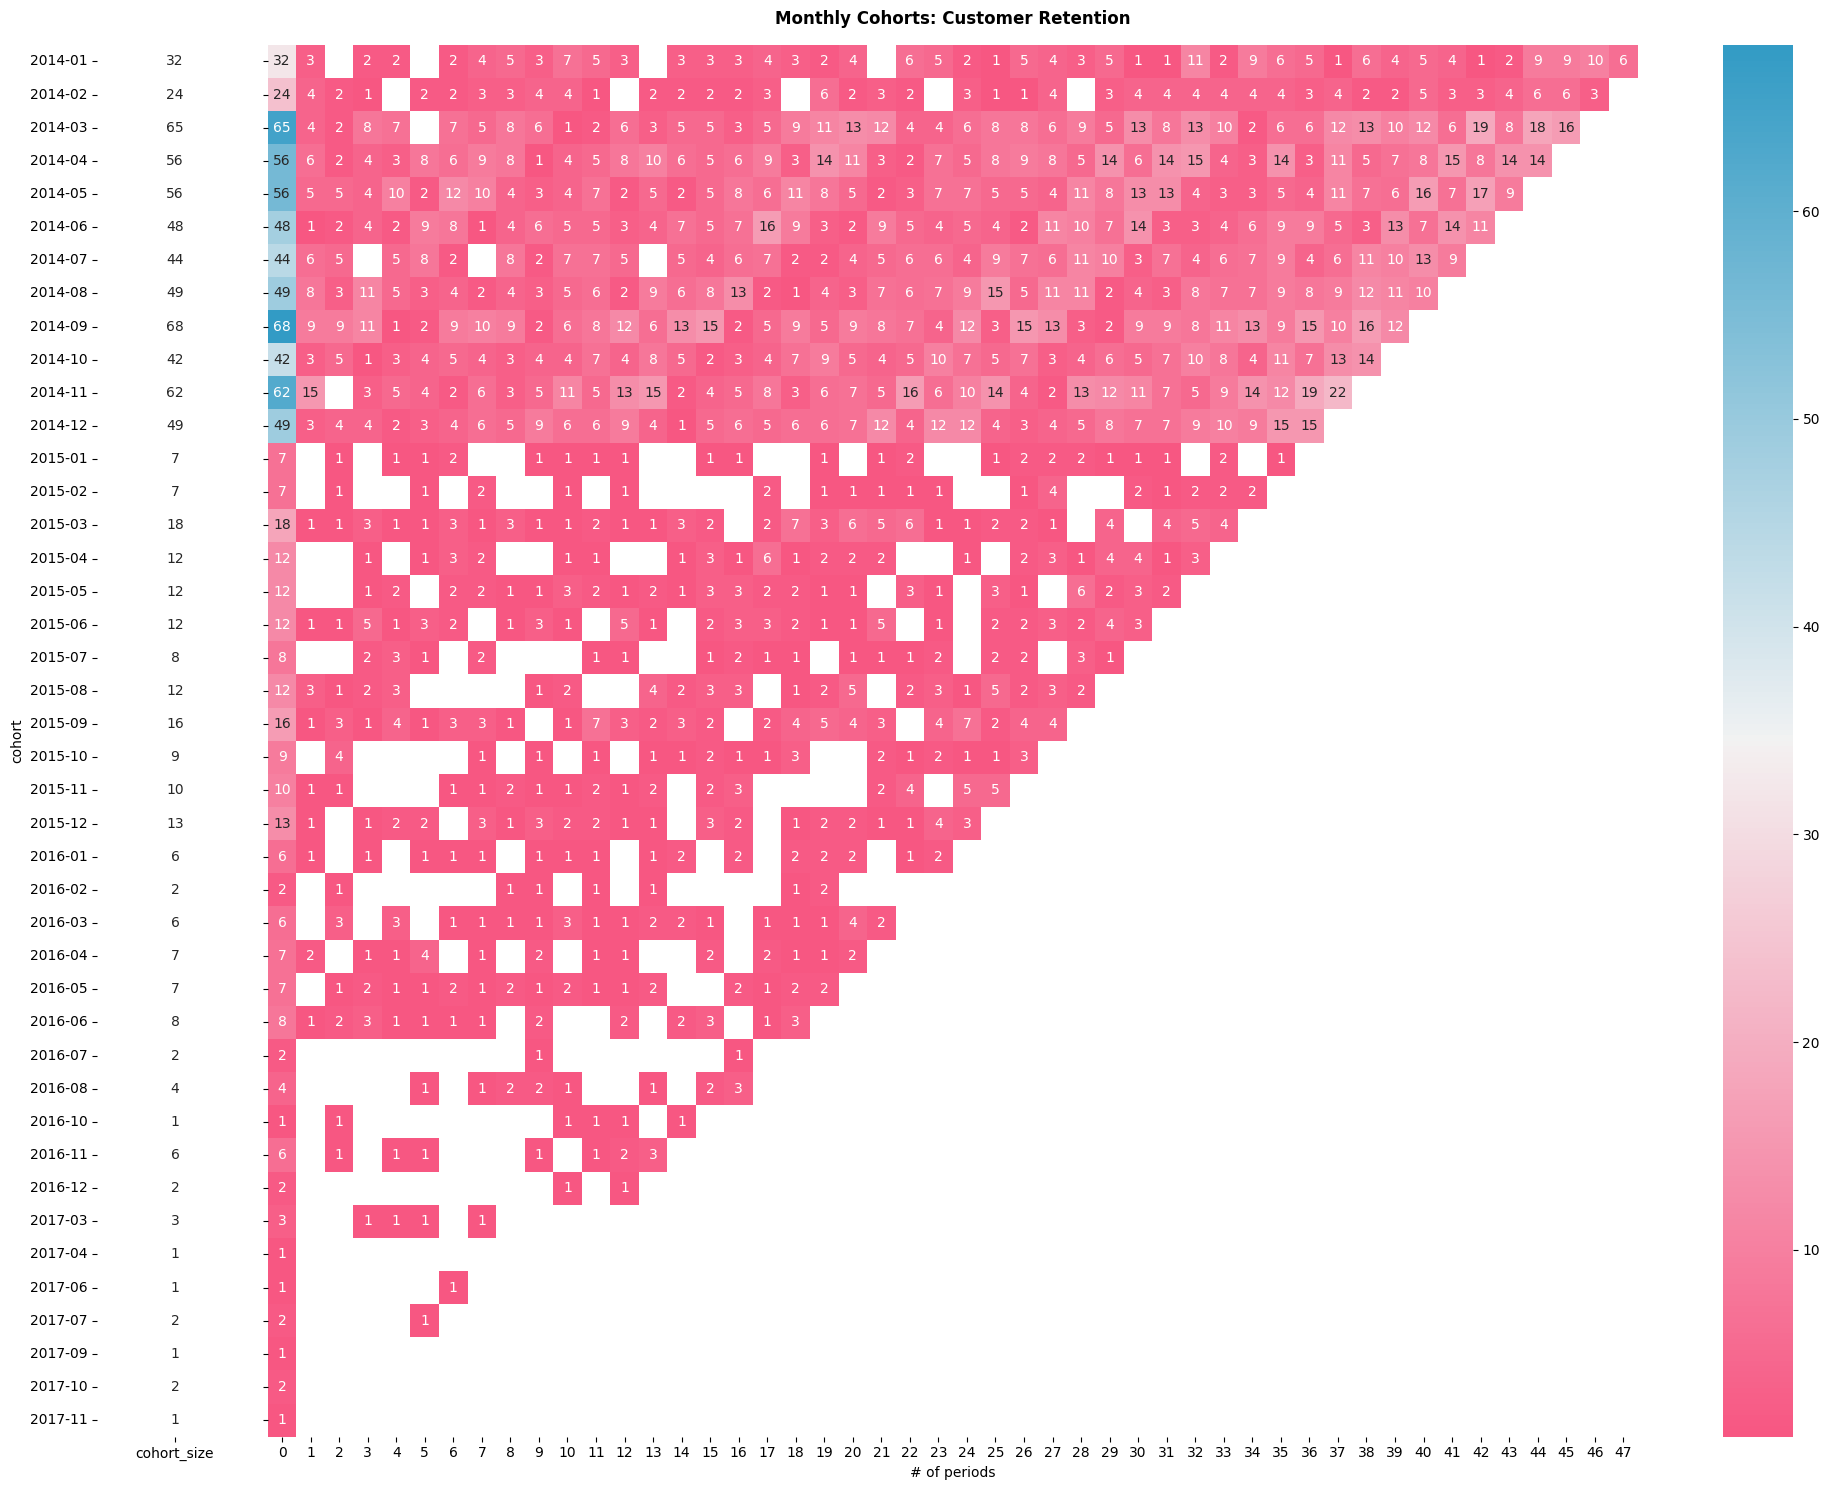

In [20]:
cohort_pivot = df_cohort.pivot_table(index="cohort", columns="period_number", values="n_customers")
cohort_size = cohort_pivot.iloc[:, 0]
fig, ax = plt.subplots(1, 2, figsize=(20, 15), sharey=True, gridspec_kw={"width_ratios": [1, 11]})
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
# retention matrix
sns.heatmap(cohort_pivot, mask=cohort_pivot.isnull(), annot=True, fmt=".0f", cmap=cmap, ax=ax[1])
ax[1].set_title("Monthly Cohorts: Customer Retention", fontsize=12, pad=15, weight="bold")
ax[1].set(xlabel="# of periods", ylabel="")

# cohort size
cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: "cohort_size"})
white_cmap = mcolors.ListedColormap(["white"])
sns.heatmap(cohort_size_df, annot=True, cbar=False, fmt="g", cmap=white_cmap, ax=ax[0])

plt.tight_layout()
plt.show()

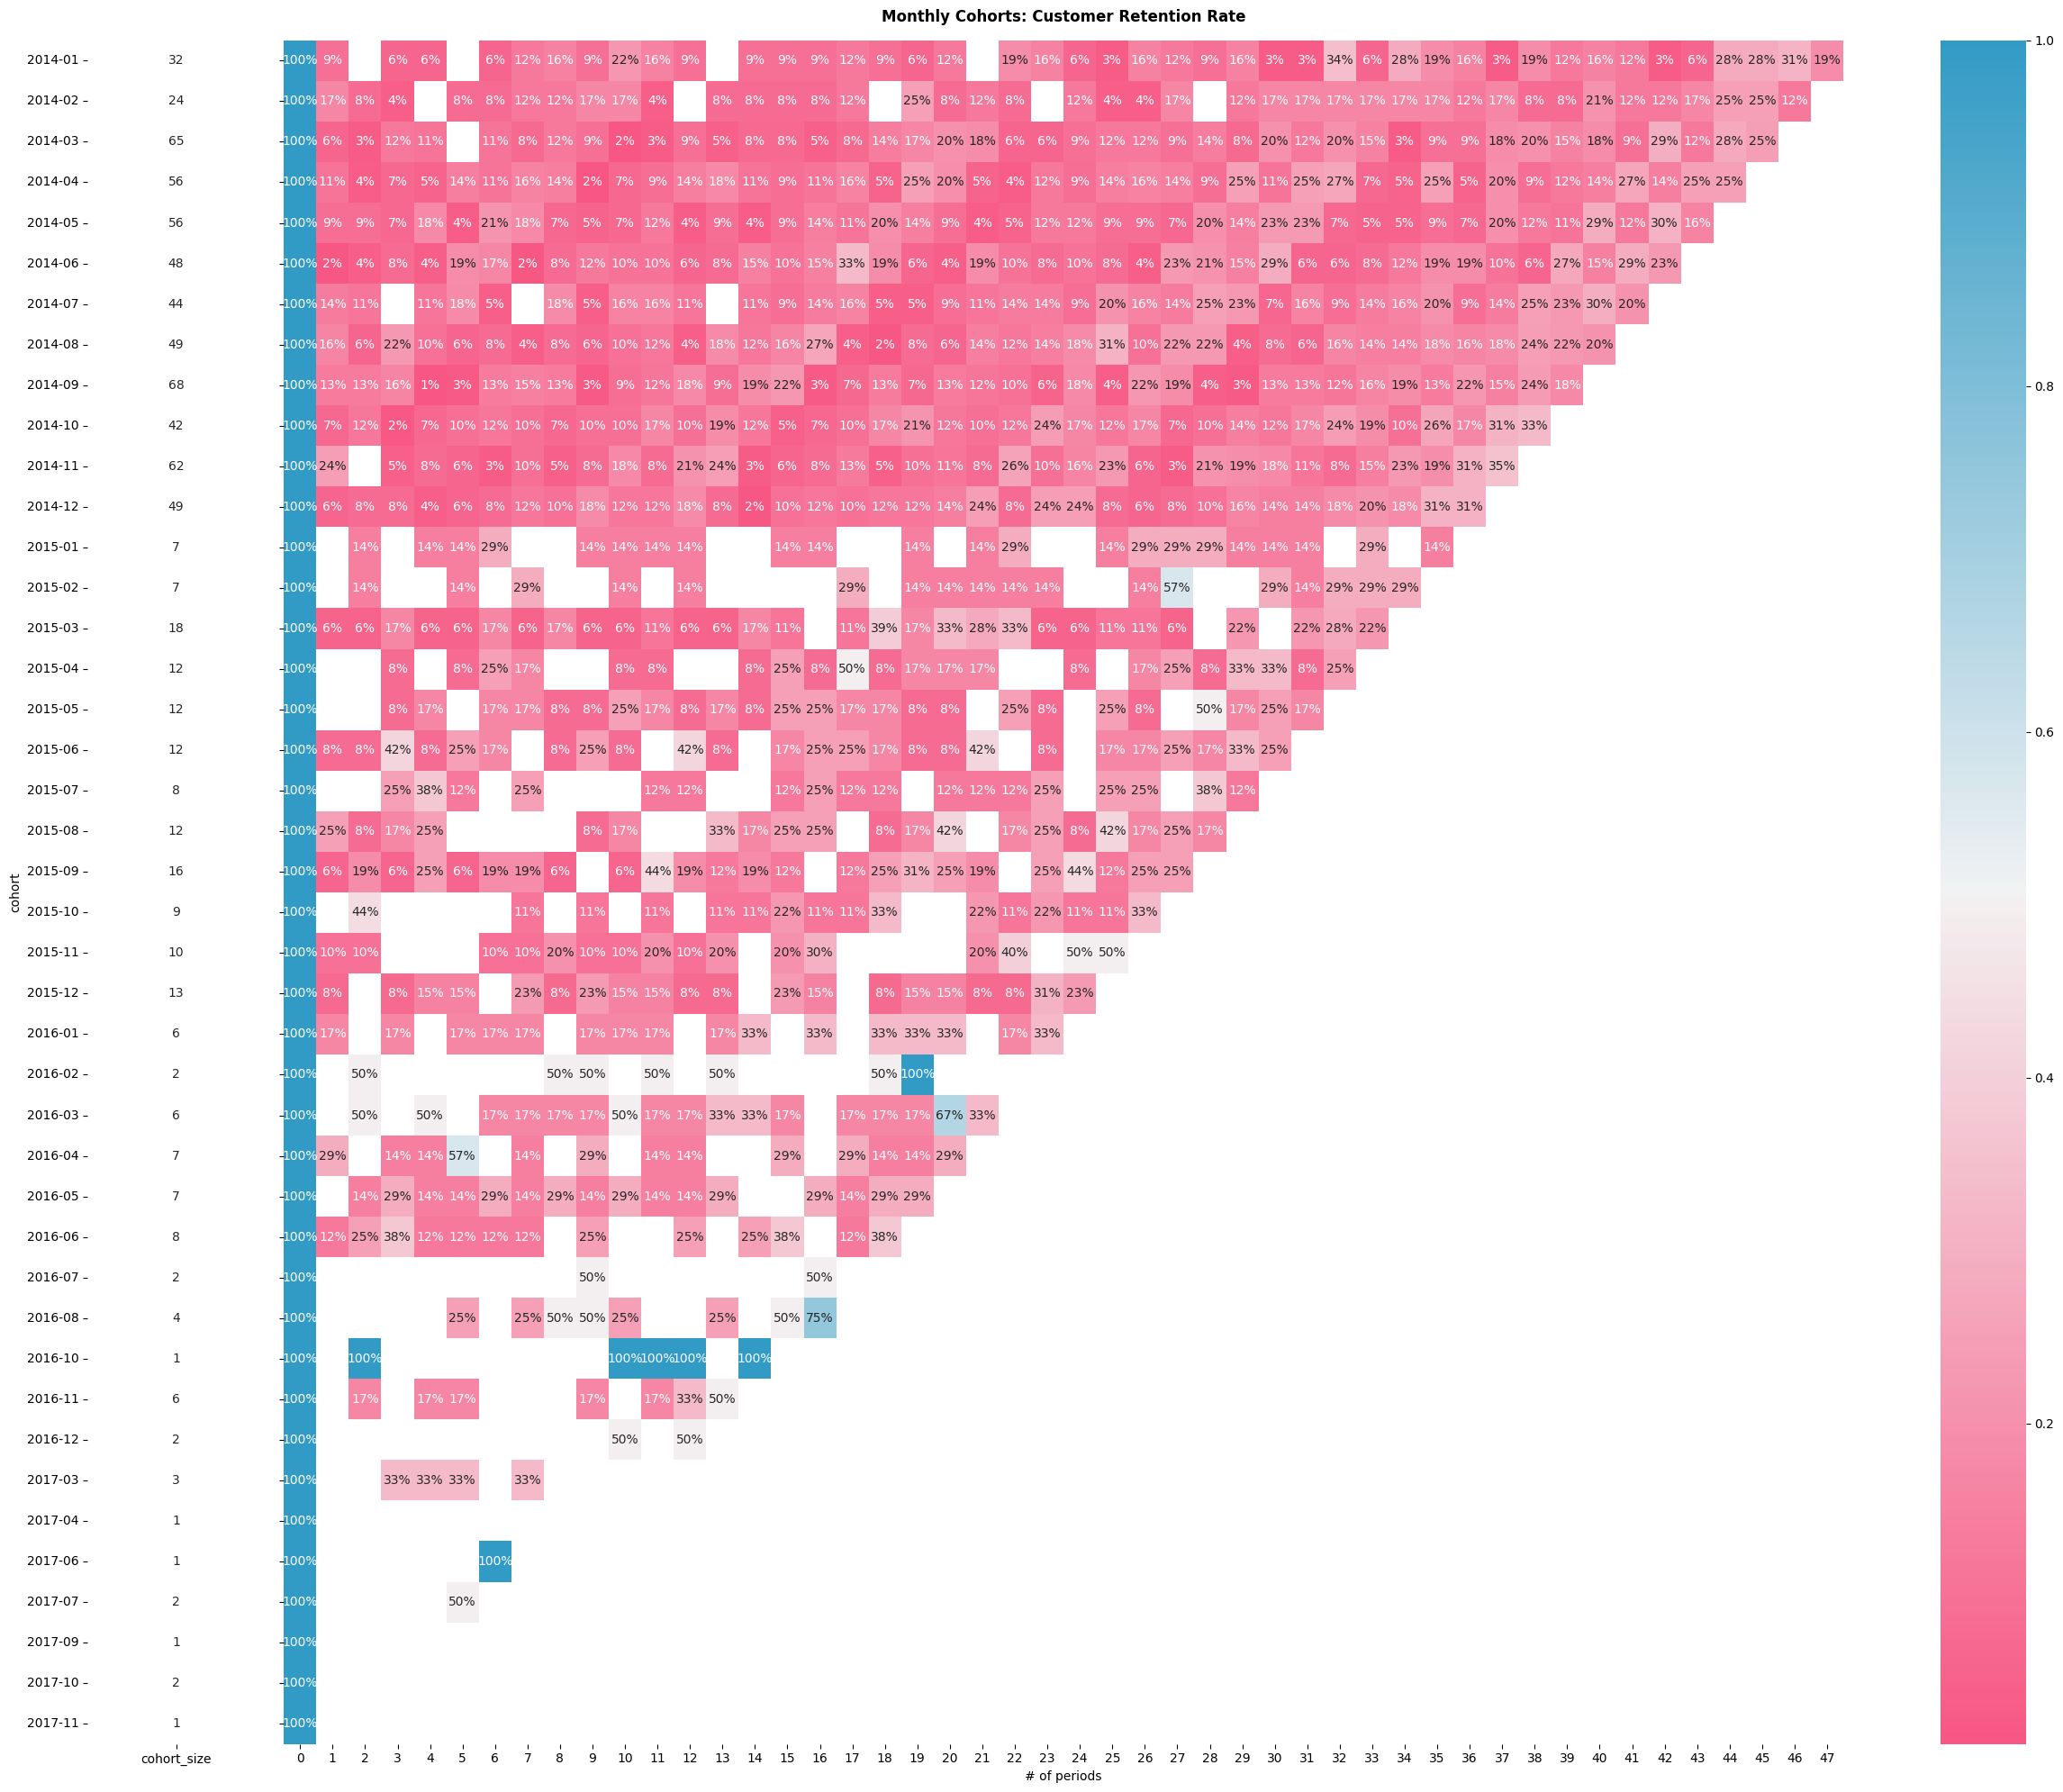

In [21]:
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
fig, ax = plt.subplots(1, 2, figsize=(25, 20), sharey=True, gridspec_kw={"width_ratios": [1, 11]})
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
# retention matrix
sns.heatmap(retention_matrix, mask=retention_matrix.isnull(), annot=True, fmt=".0%", cmap=cmap, ax=ax[1])
ax[1].set_title("Monthly Cohorts: Customer Retention Rate", fontsize=12, pad=15, weight="bold")
ax[1].set(xlabel="# of periods", ylabel="")

# cohort size
cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: "cohort_size"})
white_cmap = mcolors.ListedColormap(["white"])
sns.heatmap(cohort_size_df, annot=True, cbar=False, fmt="g", cmap=white_cmap, ax=ax[0])

plt.tight_layout()
plt.show()

### Customer Churn

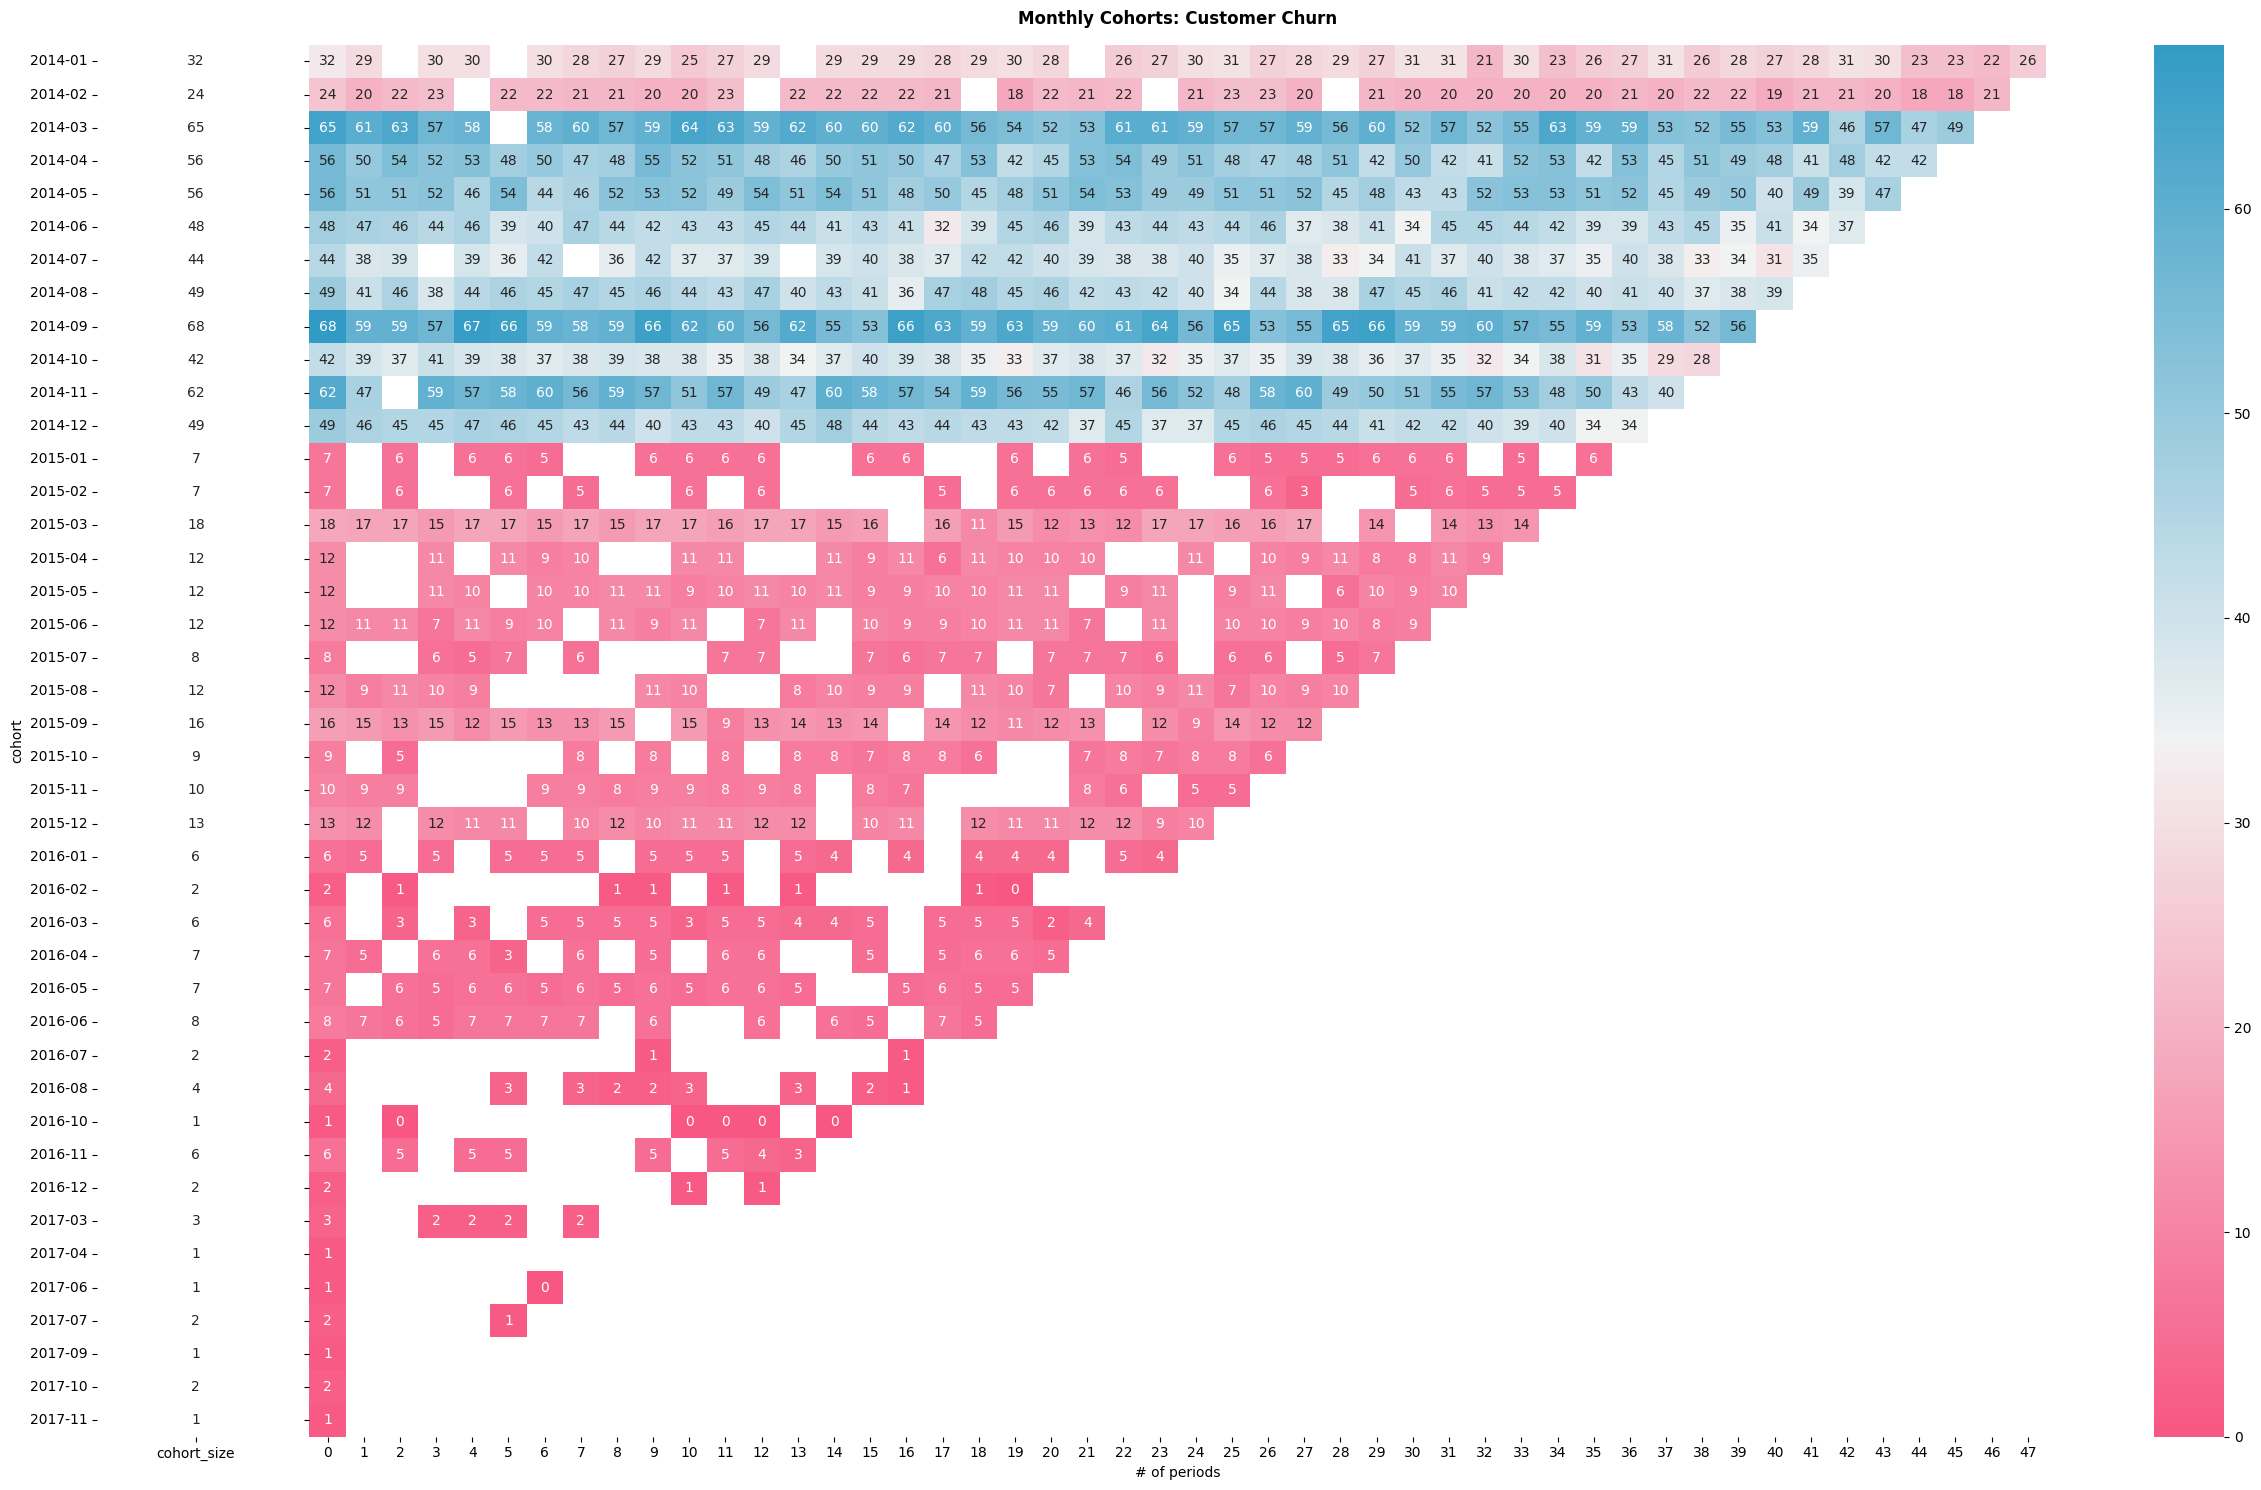

In [22]:
base = cohort_pivot[0]
n_customer_churn = cohort_pivot.apply(lambda col: base - col, axis=0)
n_customer_churn[0] = base
cohort_size_churn = n_customer_churn.iloc[:, 0]
fig, ax = plt.subplots(1, 2, figsize=(25, 15), sharey=True, gridspec_kw={"width_ratios": [1, 11]})
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
# retention matrix
sns.heatmap(n_customer_churn, mask=n_customer_churn.isnull(), annot=True, fmt=".0f", cmap=cmap, ax=ax[1])
ax[1].set_title("Monthly Cohorts: Customer Churn", fontsize=12, pad=15, weight="bold")
ax[1].set(xlabel="# of periods", ylabel="")

# cohort size
cohort_size_df = pd.DataFrame(cohort_size_churn).rename(columns={0: "cohort_size"})
white_cmap = mcolors.ListedColormap(["white"])
sns.heatmap(cohort_size_df, annot=True, cbar=False, fmt="g", cmap=white_cmap, ax=ax[0])

plt.tight_layout()
plt.show()

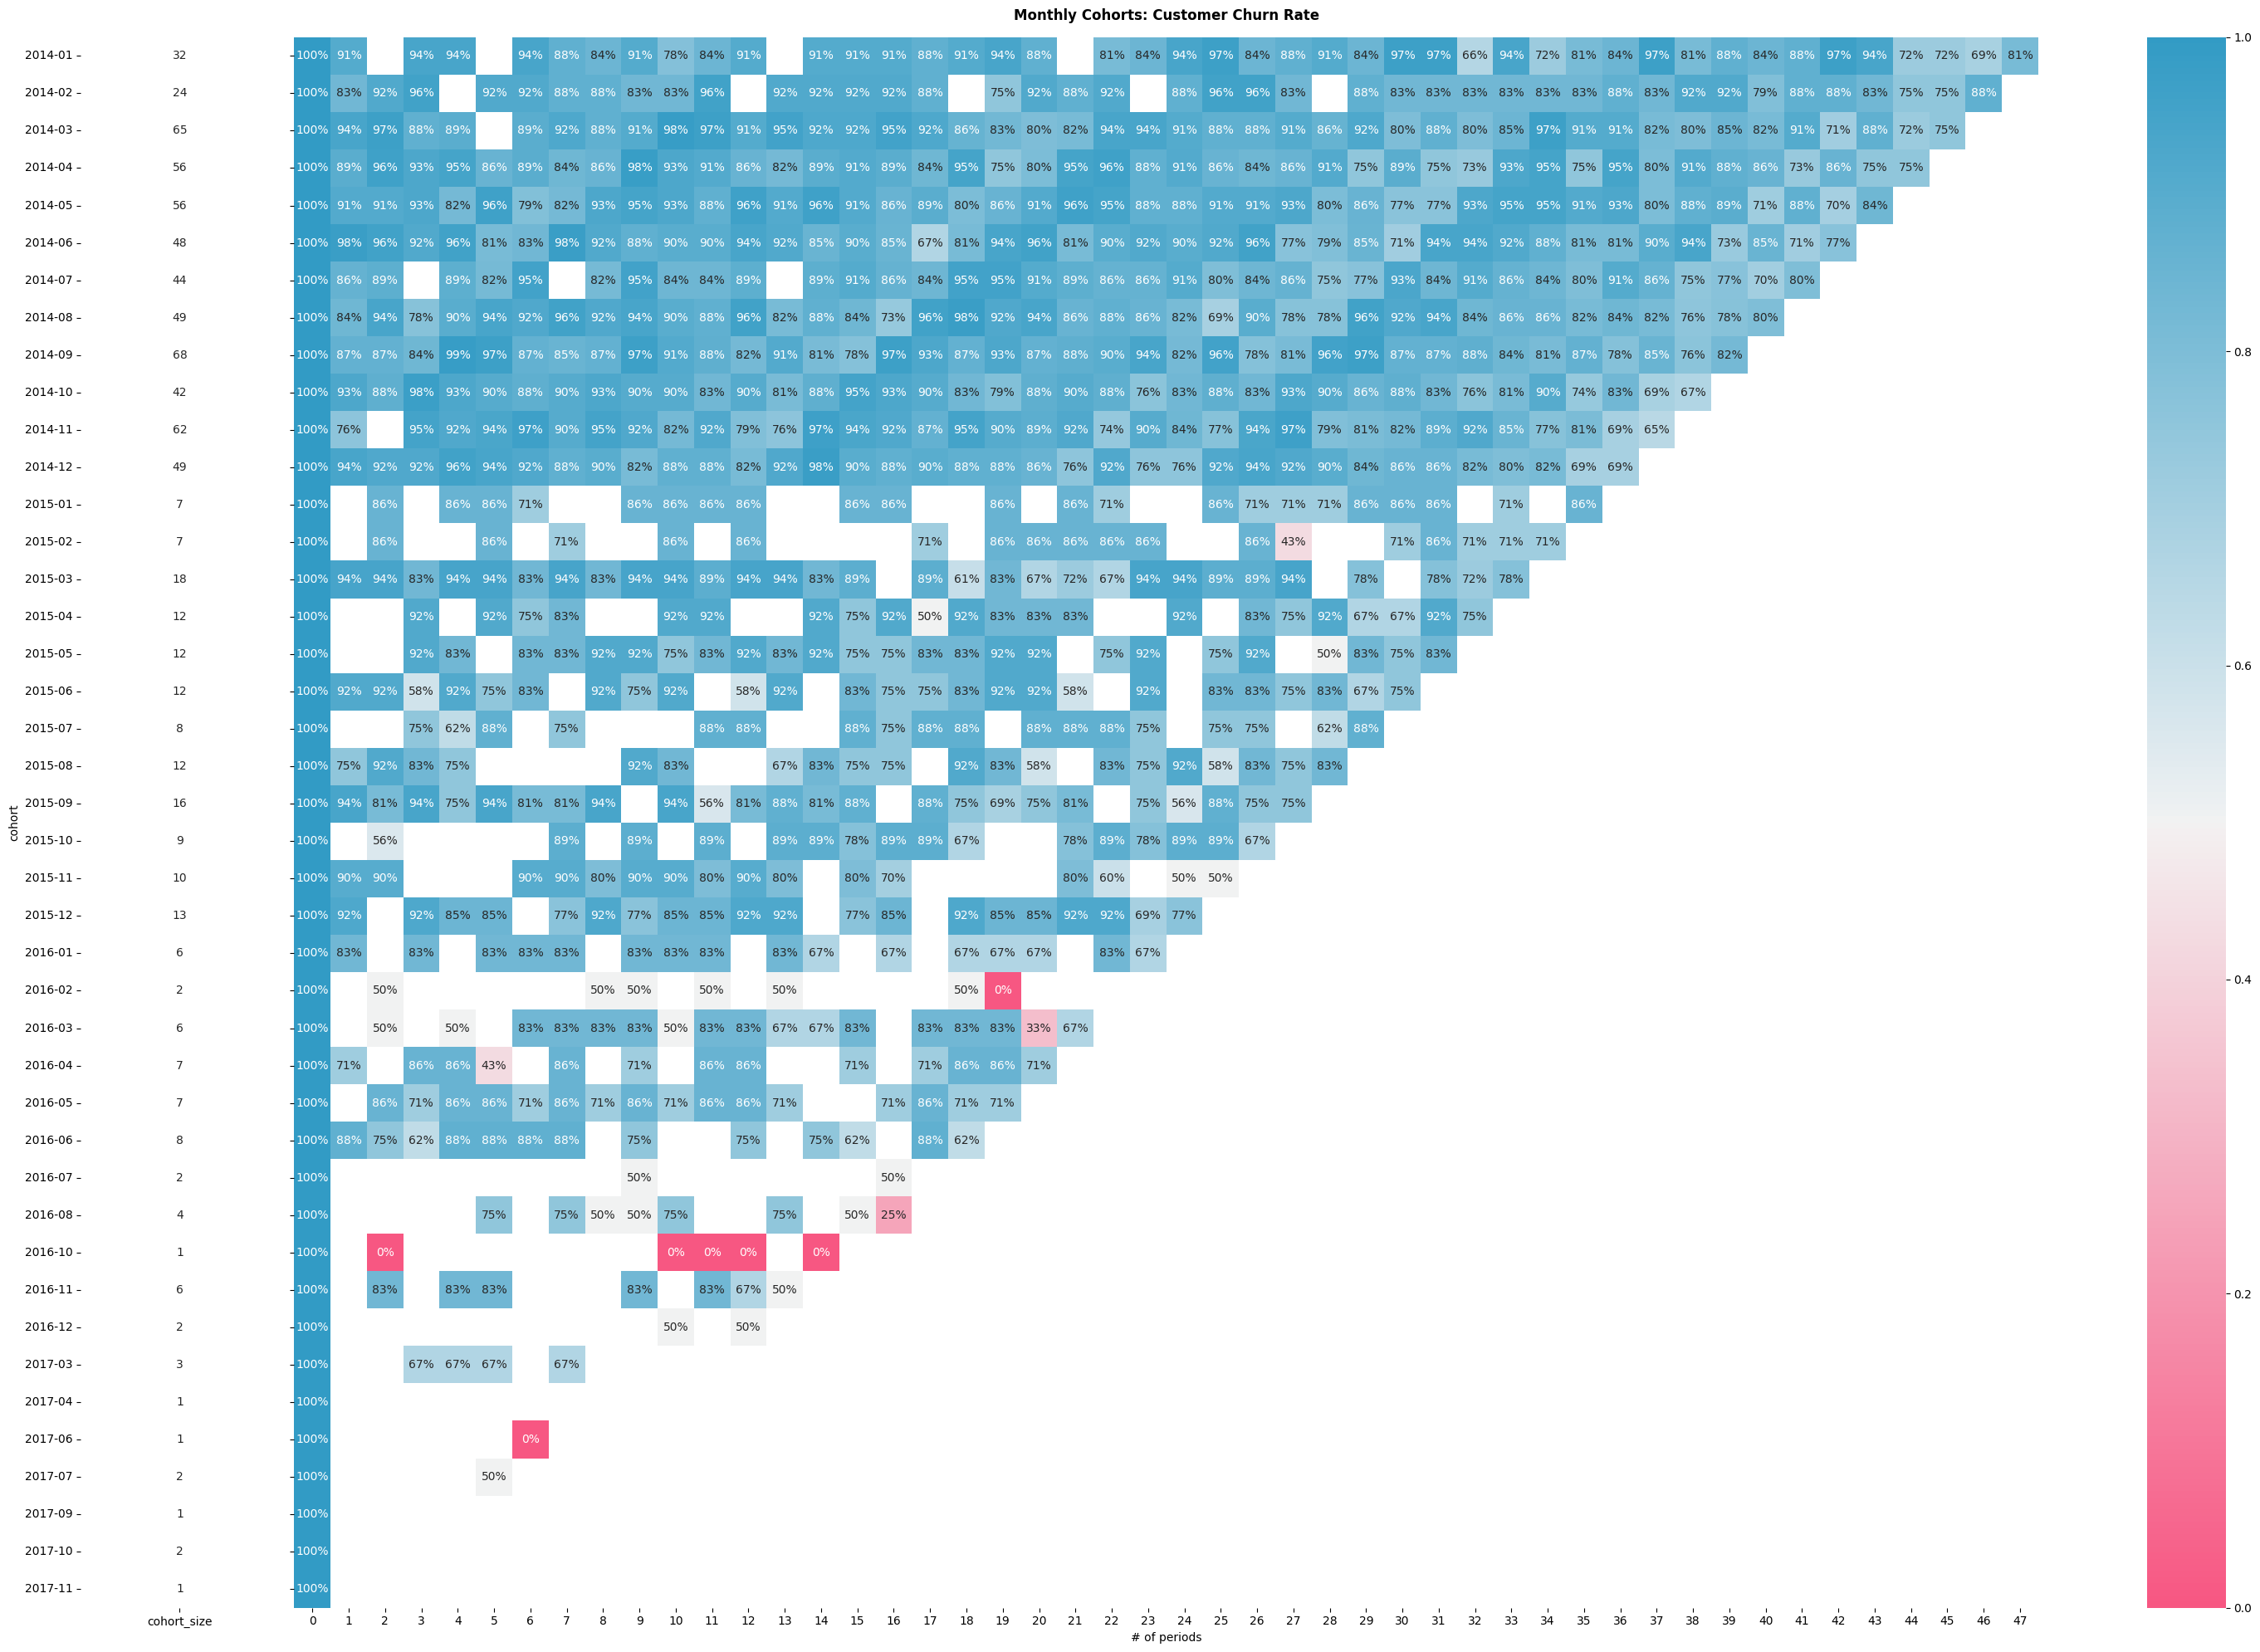

In [23]:
churn_rate_matrix = n_customer_churn.divide(cohort_size_churn, axis=0)
fig, ax = plt.subplots(1, 2, figsize=(30, 20), sharey=True, gridspec_kw={"width_ratios": [1, 11]})
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)
# retention matrix
sns.heatmap(churn_rate_matrix, mask=churn_rate_matrix.isnull(), annot=True, fmt=".0%", cmap=cmap, ax=ax[1])
ax[1].set_title("Monthly Cohorts: Customer Churn Rate", fontsize=12, pad=15, weight="bold")
ax[1].set(xlabel="# of periods", ylabel="")

# cohort size
cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: "cohort_size"})
white_cmap = mcolors.ListedColormap(["white"])
sns.heatmap(cohort_size_df, annot=True, cbar=False, fmt="g", cmap=white_cmap, ax=ax[0])

plt.tight_layout()
plt.show()

**Monthly Cohort Analysis – Executive Summary**

* Customer retention **drops sharply in early periods**; churn is **front-loaded**
* Only a **small core of customers** remains long term
* **Early cohorts (2014)** show **stronger and longer retention**
* **Later cohorts** churn faster, indicating **declining acquisition quality**
* Customers who survive the early phase tend to **stay for a long time**

**Key Business Actions**

* **Prioritize early retention (first 3–6 periods)** through onboarding and early engagement
* **Improve acquisition quality**, not just customer volume
* **Protect and maximize value** from long-term loyal customers

**Executive One-Liner**

> **Early-stage churn drives overall retention outcomes; improving acquisition quality and early customer engagement is critical to building long-term customer loyalty.**

## QoQ Analysis

2026-06-01 17:20:55 | INFO | Quarterly Sales and QoQ Growth Trend


,quarter,total_feature,account_count,qoq_growth,qoq_growth_label
0,2014Q1,74447.7960,121,NaN,–
1,2014Q2,86538.7596,180,16.24,+16.24%
2,2014Q3,143633.2123,228,65.98,+65.98%
3,2014Q4,179627.7302,305,25.06,+25.06%
4,2015Q1,68851.7386,135,-61.67,-61.67%
5,2015Q2,89124.1870,192,29.44,+29.44%
6,2015Q3,130259.5752,233,46.16,+46.16%
7,2015Q4,182297.0082,310,39.95,+39.95%
8,2016Q1,93237.1810,162,-48.85,-48.85%
9,2016Q2,136082.3010,240,45.95,+45.95%


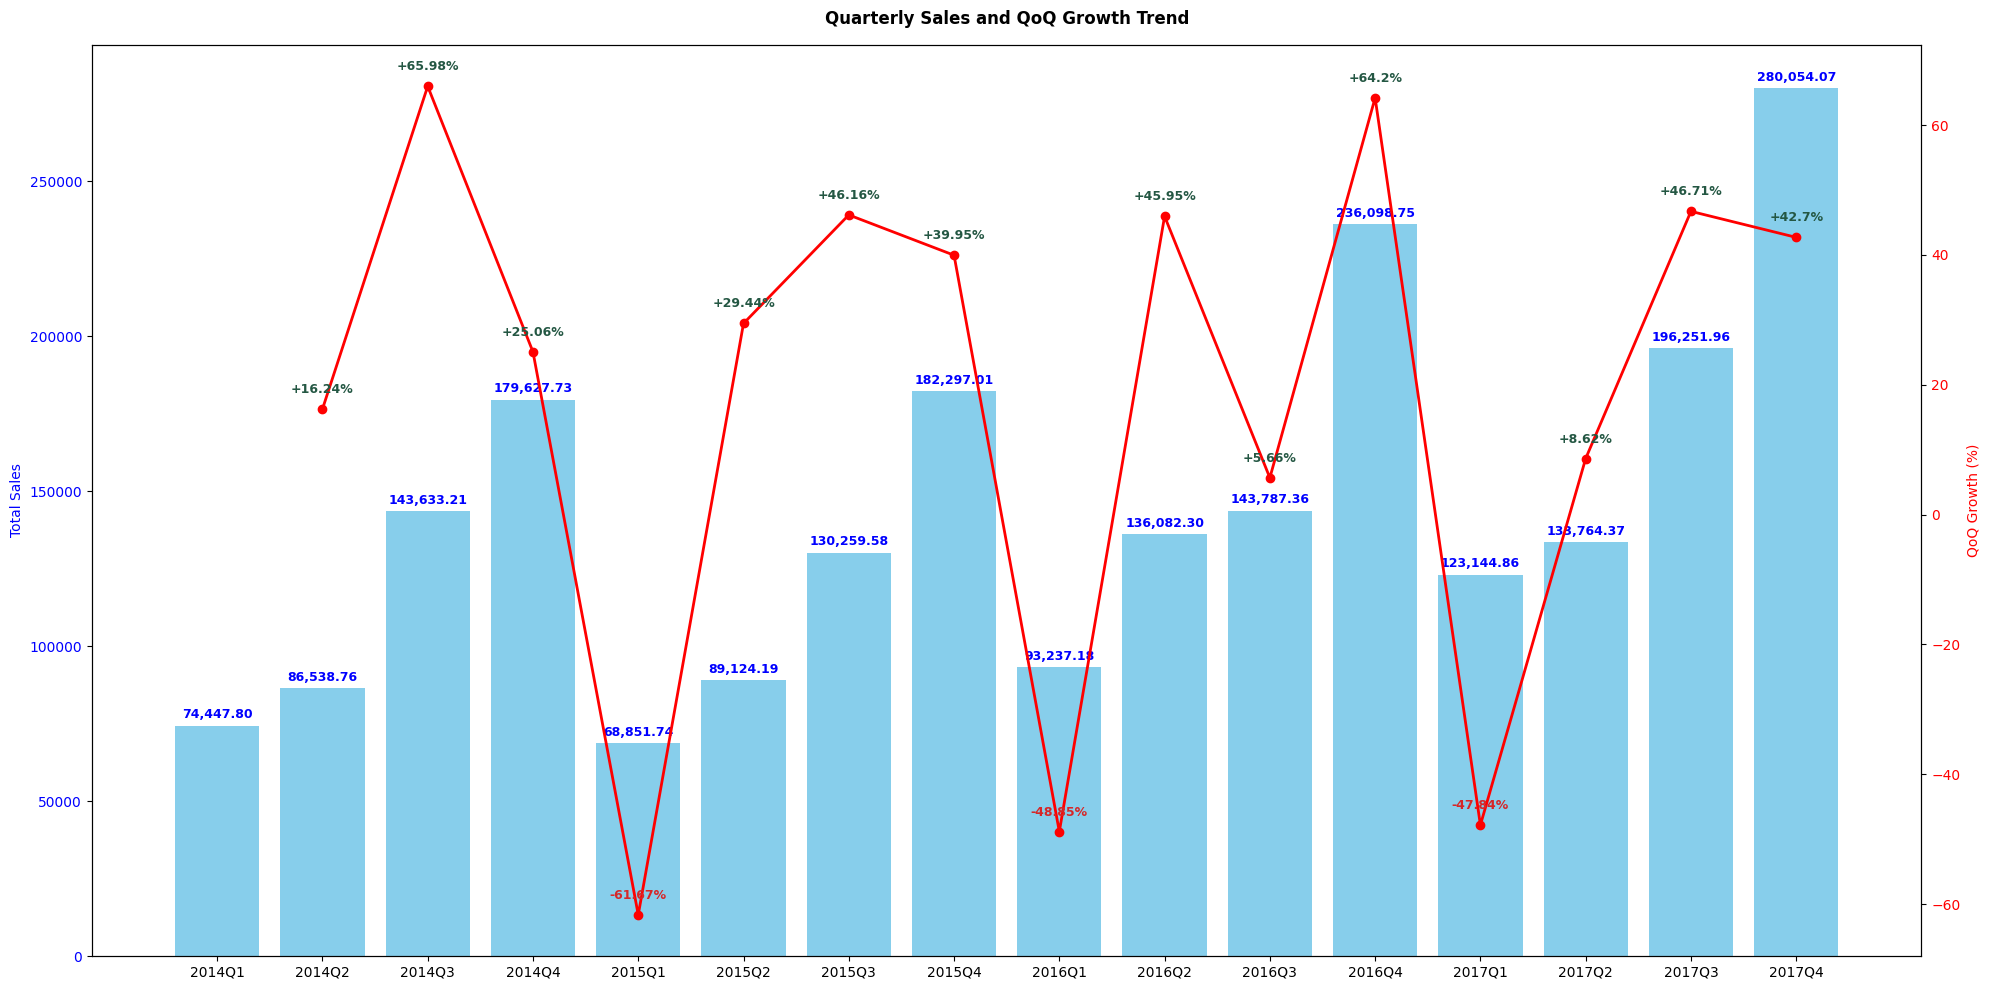

2026-06-01 17:20:56 | INFO | Quarterly Quantity and QoQ Growth Trend


,quarter,total_feature,account_count,qoq_growth,qoq_growth_label
0,2014Q1,1028,121,NaN,–
1,2014Q2,1523,180,48.15,+48.15%
2,2014Q3,2159,228,41.76,+41.76%
3,2014Q4,2871,305,32.98,+32.98%
4,2015Q1,990,135,-65.52,-65.52%
5,2015Q2,1604,192,62.02,+62.02%
6,2015Q3,2241,233,39.71,+39.71%
7,2015Q4,3144,310,40.29,+40.29%
8,2016Q1,1243,162,-60.46,-60.46%
9,2016Q2,2240,240,80.21,+80.21%


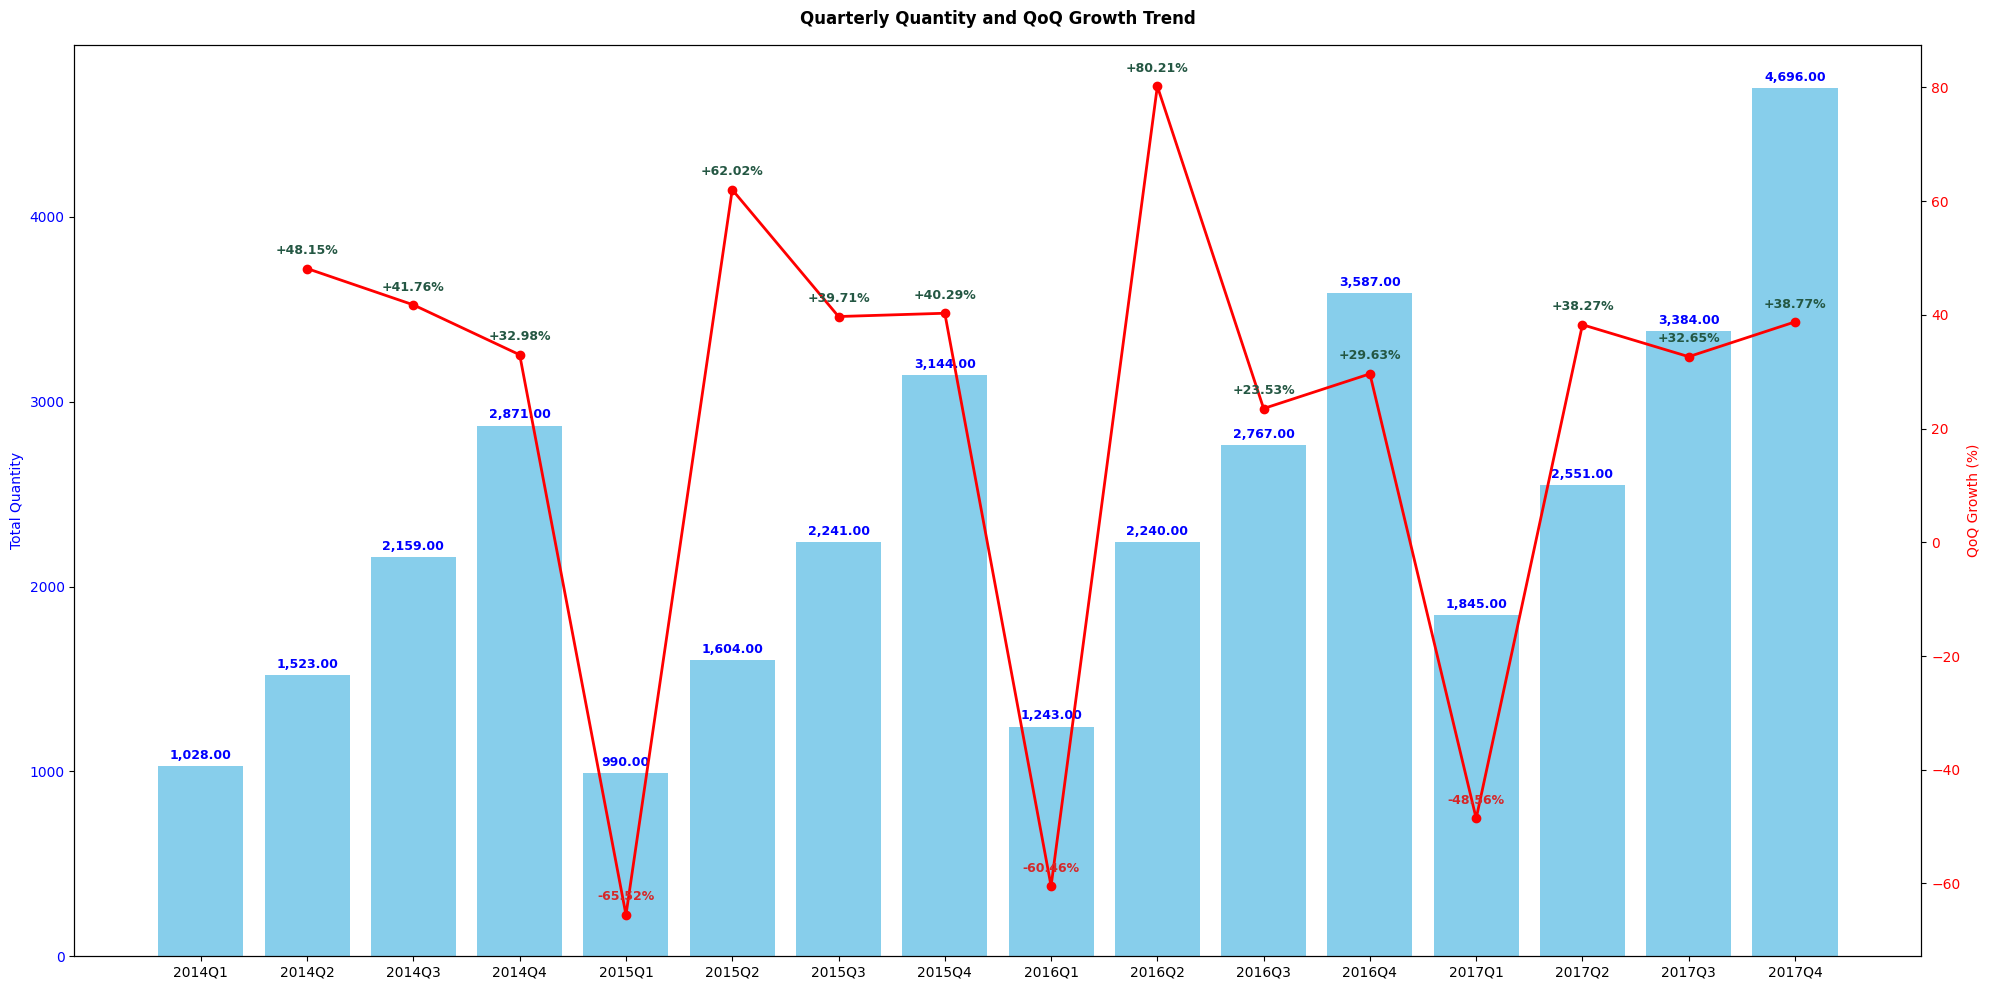

2026-06-01 17:20:56 | INFO | Quarterly Discount and QoQ Growth Trend


,quarter,total_feature,account_count,qoq_growth,qoq_growth_label
0,2014Q1,44.40,121,NaN,–
1,2014Q2,57.02,180,28.42,+28.42%
2,2014Q3,87.47,228,53.40,+53.4%
3,2014Q4,126.57,305,44.70,+44.7%
4,2015Q1,37.96,135,-70.01,-70.01%
5,2015Q2,76.20,192,100.74,+100.74%
6,2015Q3,90.02,233,18.14,+18.14%
7,2015Q4,122.91,310,36.54,+36.54%
8,2016Q1,50.92,162,-58.57,-58.57%
9,2016Q2,95.60,240,87.75,+87.75%


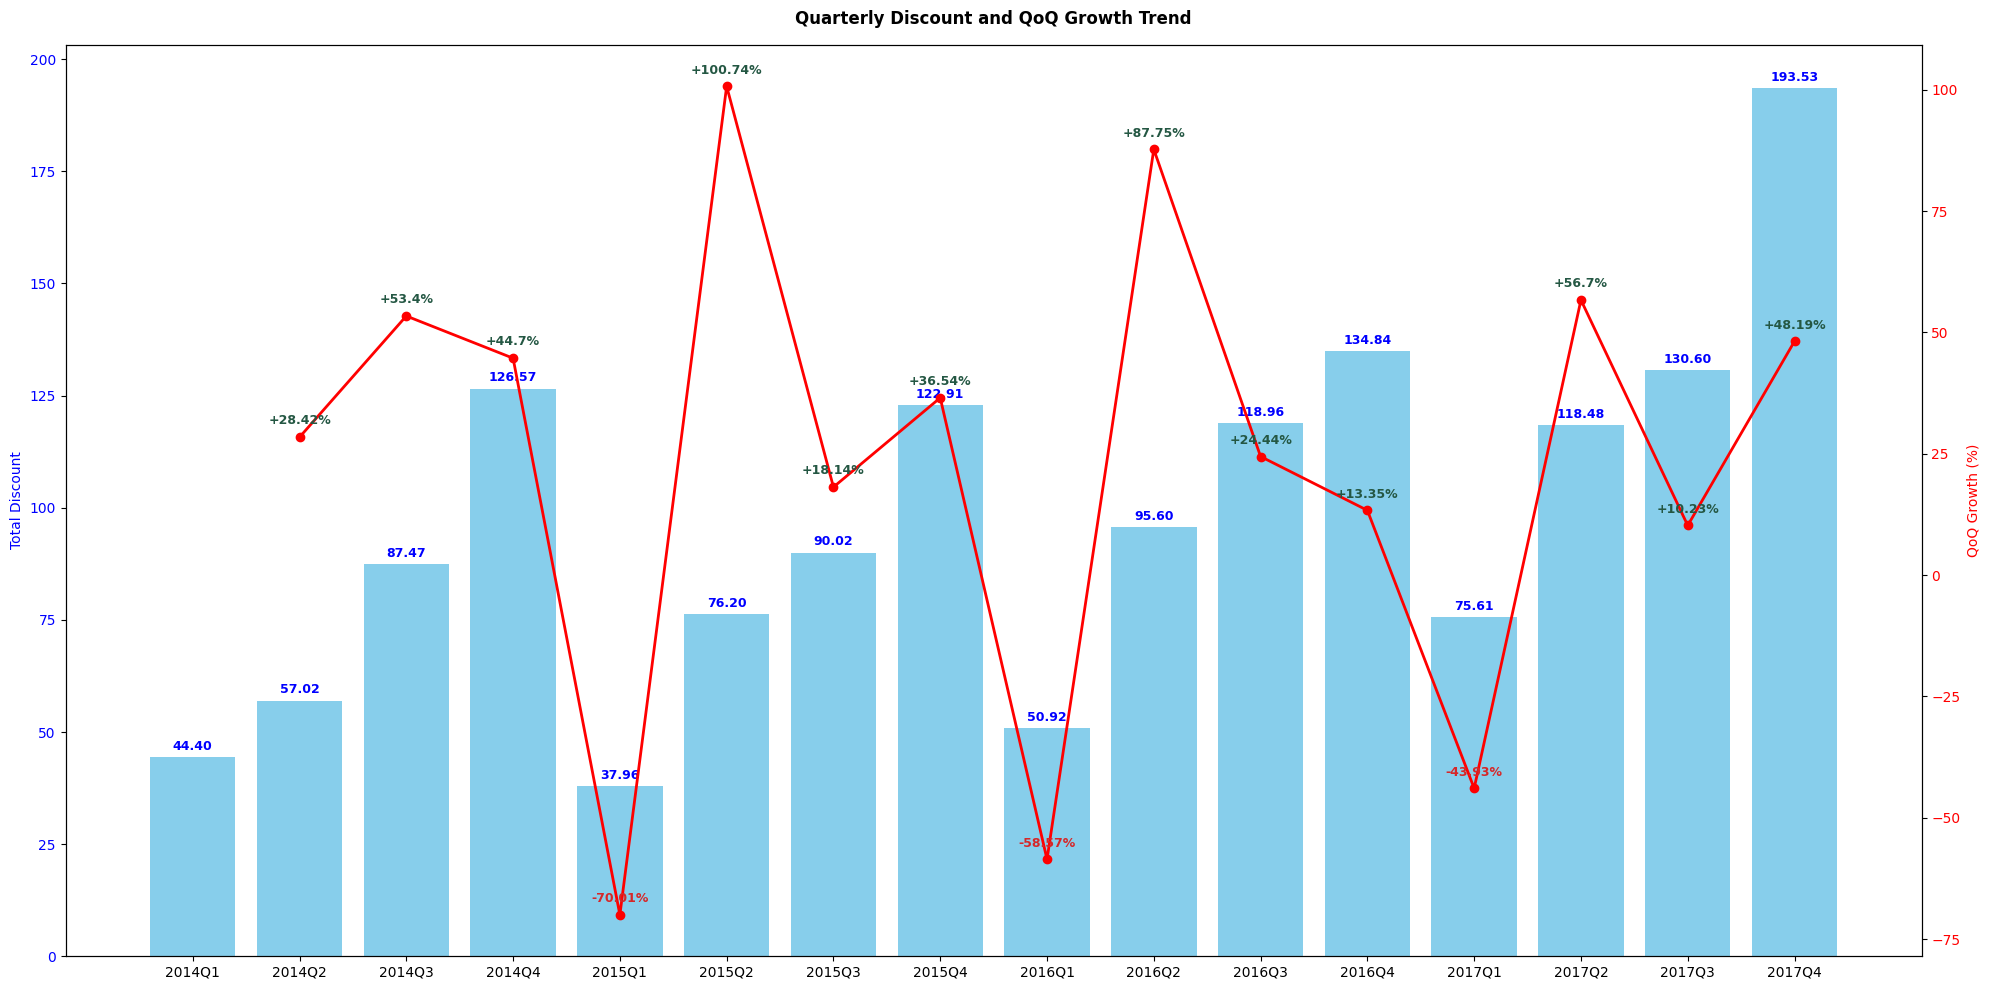

2026-06-01 17:20:56 | INFO | Quarterly Profit and QoQ Growth Trend


,quarter,total_feature,account_count,qoq_growth,qoq_growth_label
0,2014Q1,3811.2290,121,NaN,–
1,2014Q2,11204.0692,180,193.98,+193.98%
2,2014Q3,12804.7218,228,14.29,+14.29%
3,2014Q4,21723.9541,305,69.66,+69.66%
4,2015Q1,9264.9416,135,-57.35,-57.35%
5,2015Q2,12190.9224,192,31.58,+31.58%
6,2015Q3,16853.6194,233,38.25,+38.25%
7,2015Q4,23309.1203,310,38.30,+38.3%
8,2016Q1,11441.3708,162,-50.91,-50.91%
9,2016Q2,16390.3394,240,43.26,+43.26%


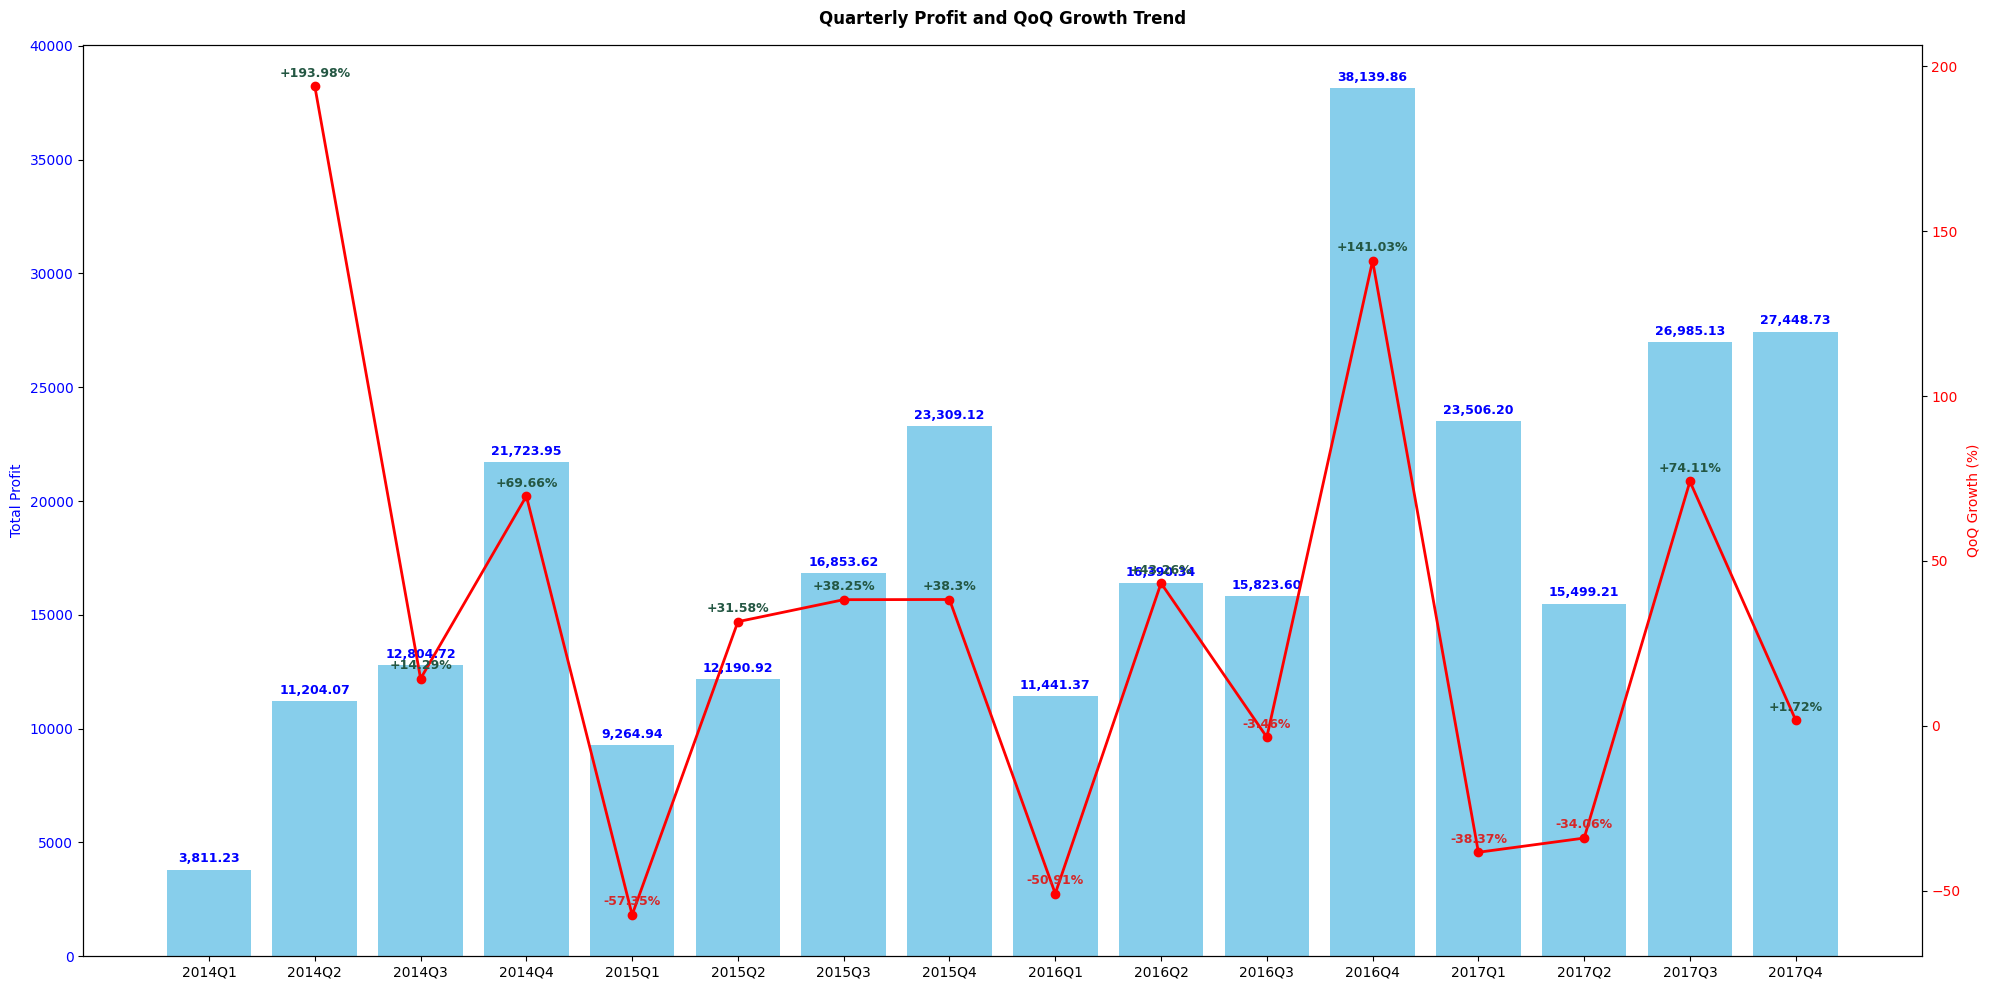

2026-06-01 17:20:57 | INFO | Quarterly Spend and QoQ Growth Trend


,quarter,total_feature,account_count,qoq_growth,qoq_growth_label
0,2014Q1,70636.5670,121,NaN,–
1,2014Q2,75334.6904,180,6.65,+6.65%
2,2014Q3,130828.4905,228,73.66,+73.66%
3,2014Q4,157903.7761,305,20.70,+20.7%
4,2015Q1,59586.7970,135,-62.26,-62.26%
5,2015Q2,76933.2646,192,29.11,+29.11%
6,2015Q3,113405.9558,233,47.41,+47.41%
7,2015Q4,158987.8879,310,40.19,+40.19%
8,2016Q1,81795.8102,162,-48.55,-48.55%
9,2016Q2,119691.9616,240,46.33,+46.33%


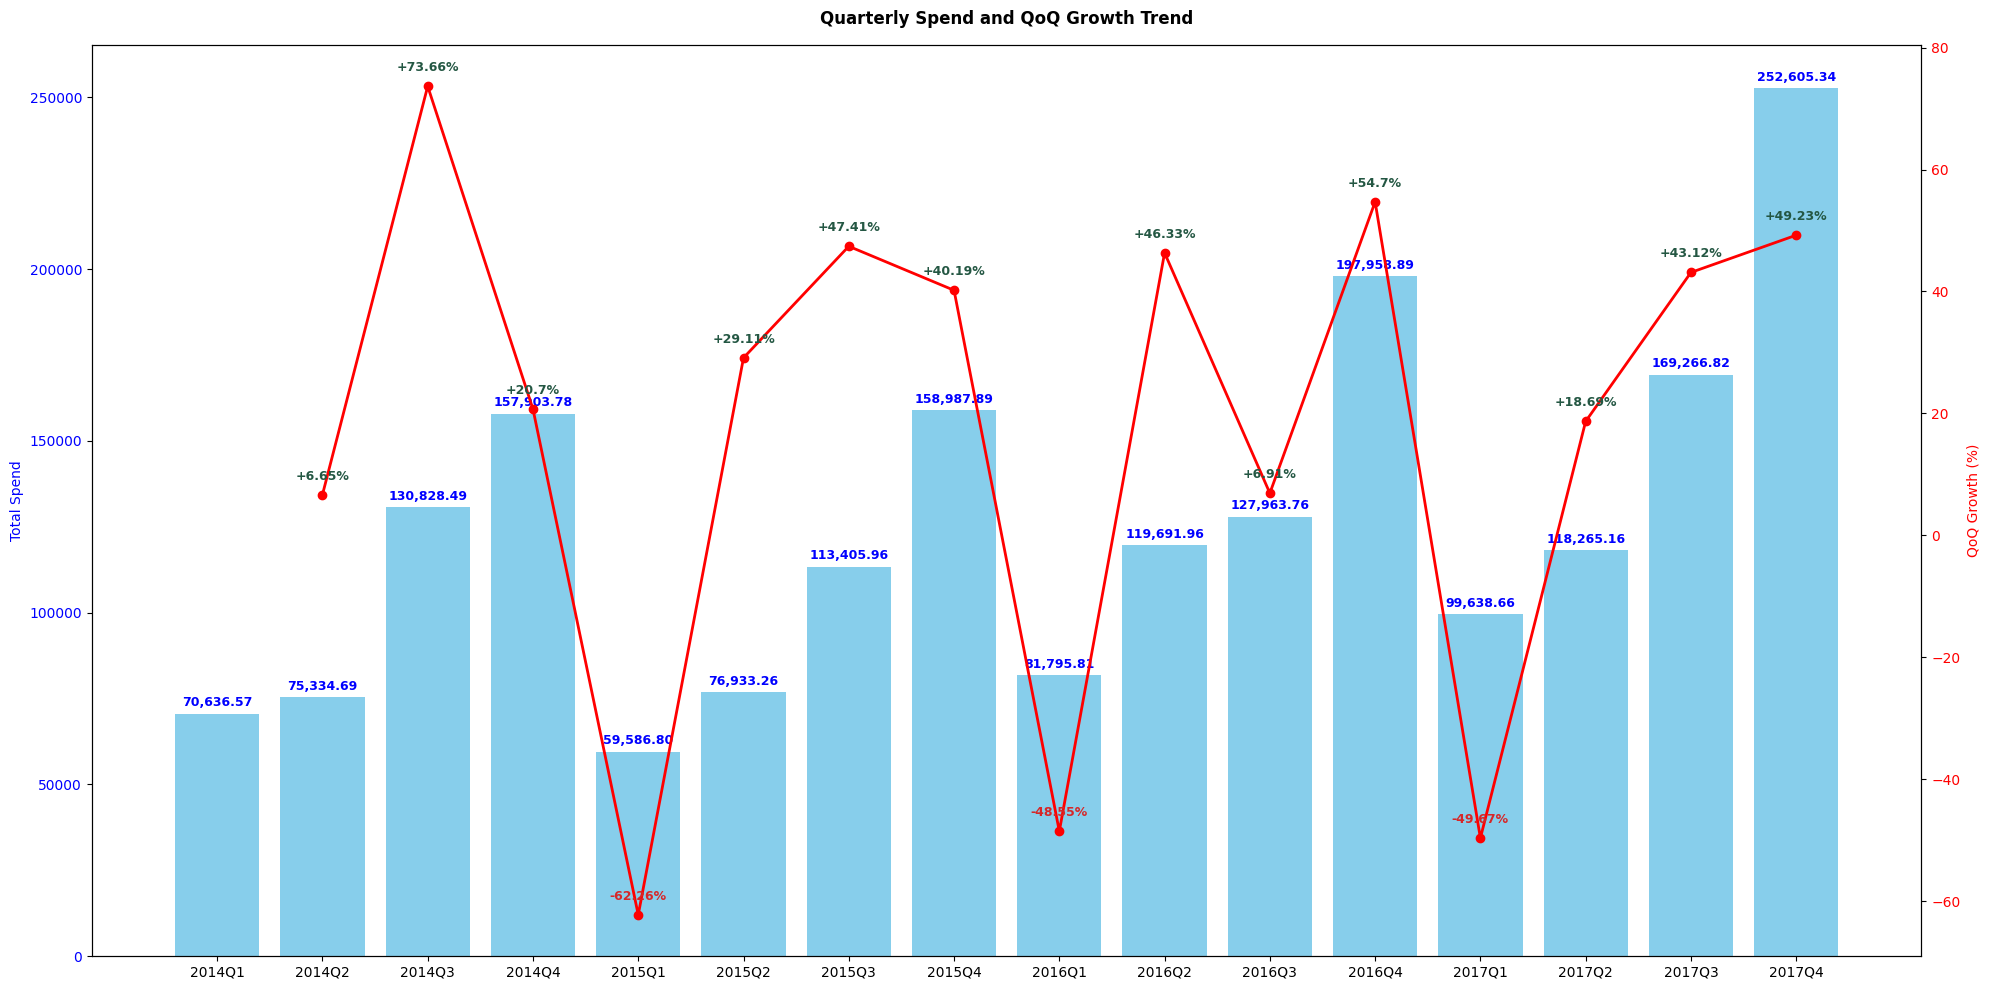

In [24]:
def qoq_analysis(df=df_merged, feature=feature, logger=logger):
    """
    Plot quarterly performance of a given feature with its QoQ growth trend.

    - Bar chart shows total feature value per quarter.
    - Line chart shows quarter-over-quarter (QoQ) growth percentage.
    - QoQ labels are color-coded for positive/negative growth.
    """

    logger.info(f"Quarterly {feature} and QoQ Growth Trend")
    # Extract quarter period (e.g., 2020Q1) from order_date
    df["quarter"] = (
        df["OrderDate"]
        .dt.to_period("Q")
        .astype(str)
    )

    # Aggregate quarterly "feature" and number of unique accounts
    quarterly_summary = df.groupby("quarter").agg(
        total_feature=(feature, "sum"),                      # total_feature (Total Sales, Total Profit,...) per quarter
        account_count=("CustomerID", "nunique")              # Number of unique accounts per quarter
    ).reset_index()

    # Calculate quarter-over-quarter (QoQ) growth (%)
    quarterly_summary["qoq_growth"] = (quarterly_summary["total_feature"].pct_change() * 100).round(2)

     # Create formatted QoQ growth labels
    quarterly_summary["qoq_growth_label"] = quarterly_summary["qoq_growth"].apply(
        lambda x: f"+{x}%" if pd.notnull(x) and x > 0 
        else (f"{x}%" if pd.notnull(x) else "–")
    )

    # Display the first few rows for validation
    display(quarterly_summary)

    # Initialize figure and primary axis
    fig, ax1 = plt.subplots(figsize=(20, 10))

    # Bar chart: total feature by quarter
    bars = ax1.bar(quarterly_summary["quarter"], quarterly_summary["total_feature"],
                color="skyblue", label=f"Total {feature}".title())
    ax1.set_ylabel(f"Total {feature}".title(), color="blue")
    ax1.tick_params(axis="y", labelcolor="blue")

    # Add value labels on top of each bar
    ax1.bar_label(bars, labels=[f"{v:,.2f}" for v in quarterly_summary["total_feature"]],
                padding=3, fontsize=9, color="blue", weight="bold")

    # Secondary axis: QoQ growth (%)
    ax2 = ax1.twinx()
    ax2.plot(quarterly_summary["quarter"], quarterly_summary["qoq_growth"], color="red",
            marker="o", linewidth=2, label="QoQ Growth (%)")
    ax2.set_ylabel("QoQ Growth (%)", color="red")
    ax2.tick_params(axis="y", labelcolor="red")

    # Add QoQ growth labels near markers
    y_offset = 2  # Offset in percentage points for label positioning

    for x, growth, label in zip(
        quarterly_summary["quarter"],
        quarterly_summary["qoq_growth"],
        quarterly_summary["qoq_growth_label"]
    ):
        # Determine color
        if pd.isna(growth):
            color = "#555555"         # first quarter = neutral gray
        elif growth > 0:
            color = "#245743"         # positive = green
        else:
            color = "#d62728"         # negative = red

        ax2.text(
            x,
            growth + y_offset,
            label,
            color=color,
            fontsize=9,
            ha="center",
            va="bottom",
            weight="bold"
        )

    # Chart title and layout
    plt.title(f"Quarterly {feature} and QoQ Growth Trend", fontsize=12, fontweight="bold", pad=15)
    fig.tight_layout()
    plt.show()

# Run QoQ analysis for selected feature
for feature in ["Sales", "Quantity", "Discount", "Profit", "Spend"]:
    qoq_analysis(feature=feature)

**Insight:**

**Quarterly Performance & QoQ Growth – Executive Insights**

**Overall Trend**

* Business shows **strong long-term growth**, despite short-term volatility
* QoQ growth is **cyclical**, with sharp drops followed by strong rebounds

**Sales & Spend**

* **Sales and Spend trend upward over time**, peaking in late 2016–2017
* Strong QoQ rebounds after downturns indicate **resilient demand**

*Insight:* Growth momentum is intact, but gives back gains after shocks.

**Quantity**

* Quantity growth is **more volatile than sales**, with extreme QoQ swings
* Volume spikes often **do not scale proportionally** with revenue

*Insight:* Growth is partly driven by **pricing / mix**, not just volume.

**Discount**

* Discount shows **large QoQ spikes**, especially during recovery periods
* High discount growth often **precedes sales rebounds**

*Insight:* Discounts are used as a tactical lever to stimulate demand.

**Profit**

* Profit is **highly sensitive** to QoQ changes
* Strong profit surges follow sales rebounds, but **drawdowns are steep**

*Insight:* Margin stability is fragile during downturn periods.


> **The business demonstrates strong long-term growth with high short-term volatility; sales recover quickly after downturns, often driven by aggressive discounting, while profit remains highly sensitive to quarterly shocks.**

## CLV Analysis

> **CLV = Total profit a customer generates during their relationship with the company.**
> It measures **long-term customer value** and helps optimize **marketing spend, retention, and growth strategy.**

$$
CLV = (Average Purchase Value × Gross Margin) × Purchase Frequency × Lifespan
$$

* **Average Purchase Value × Gross Margin:** Profit per purchase.
* **Purchase Frequency:** How often customers buy (e.g., times per year).
* **Lifespan:** Average years a customer stays active.

**Interpretation:** Total lifetime profit from an average customer.

In [25]:
# Compute average purchase value (APV), purchase frequency, and lifespan
clv_df = df.groupby("CustomerID").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    num_order=("OrderID", "nunique"),
    first_order=("OrderDate", "min"),
    last_order=("OrderDate", "max")
).reset_index()

display(clv_df.head())

,CustomerID,total_sales,total_profit,num_order,first_order,last_order
0,AA-10315,5563.560,-362.8825,5,2014-03-31,2017-06-29
1,AA-10375,1056.390,277.3824,9,2014-04-21,2017-12-11
2,AA-10480,1790.512,435.8274,4,2014-05-04,2017-04-15
3,AA-10645,5086.935,857.8033,6,2014-06-22,2017-11-05
4,AB-10015,886.156,129.3465,3,2014-02-18,2016-11-10


In [26]:
# Average purchase value per transaction
clv_df["apv"] = clv_df["total_sales"] / clv_df["num_order"]

# frequency (number of order)
clv_df["frequency"] = clv_df["num_order"]

# Lifespan: number of months between first and last purchase (+1 to avoid division by zero)
clv_df["lifespan_months"] = ((clv_df["last_order"] - clv_df["first_order"]).dt.days / 30).clip(lower=1)

clv_df["gross_margin"] = clv_df["total_profit"] / clv_df["total_sales"]

# Customer Lifetime Value
clv_df["CLV"] = clv_df["apv"] * clv_df["gross_margin"] * clv_df["frequency"] * clv_df["lifespan_months"]

# Calculate the average CLV across all customers ---
avg_clv = clv_df["CLV"].mean()
logger.info(f"Average CLV across all customers: {avg_clv:.2f}")

fig = go.Figure()
# Histogram CLV
fig.add_trace(
    go.Histogram(
        x=clv_df["CLV"],
        nbinsx=60,
        name="No.Customer",
        marker=dict(line=dict(width=0.5, color="black")),
        opacity=0.75
    )
)

# Vertical line for Average CLV
fig.add_trace(
    go.Scatter(
        x=[avg_clv, avg_clv],
        y=[0, clv_df.shape[0]],
        mode="lines",
        name=f"Avg CLV = {avg_clv:.2f}",
        line=dict(color="red", dash="dash", width=2)
    )
)

# Layout
fig.update_layout(
    title=dict(text="<b>Distribution of Customer Lifetime Value (CLV)<b>",
        font=dict(size=12, family="Segoe UI", color="white")
    ),
    xaxis_title=dict(text="CLV",
        font=dict(size=12, family="Segoe UI", color="white")
    ),
    yaxis_title=dict(text="Number of Customers",
        font=dict(size=12, family="Segoe UI", color="white")
    ),
    bargap=0.05,
    legend=dict(orientation="h", font=dict(size=12, color="white", family="Segoe UI")),
    hovermode="x unified",
    template="plotly_dark",
    width=1200,
    height=500,
    # Footer annotation
    annotations=[
        dict(
            text="Created By Thuan Dao.",
            xref="paper", yref="paper",
            x=1, y=-.15,
            showarrow=False,
            font=dict(size=10, color="white", family="Segoe UI")
        )
    ],
)

fig.show()

# Display top customers with highest CLV (VIP customers)
logger.info("Top 10 High-Value Customers:")
display(clv_df.sort_values(by="CLV", ascending=False).reset_index(drop=True).head(10))

2026-06-01 17:20:57 | INFO | Average CLV across all customers: 12436.08


2026-06-01 17:20:58 | INFO | Top 10 High-Value Customers:


,CustomerID,total_sales,total_profit,num_order,first_order,last_order,apv,frequency,lifespan_months,gross_margin,CLV
0,HL-15040,12873.298,5622.4292,6,2014-01-20,2017-11-17,2145.549667,6,46.566667,0.436751,261817.786413
1,TC-20980,19052.218,8981.3239,5,2014-11-07,2016-11-26,3810.443600,5,25.000000,0.471406,224533.097500
2,SC-20095,14142.334,5757.4119,9,2014-02-12,2017-01-15,1571.370444,9,35.600000,0.407105,204963.863640
3,AB-10105,14473.571,5444.8055,10,2014-12-20,2017-11-19,1447.357100,10,35.500000,0.376190,193290.595250
4,TA-21385,14595.620,4703.7883,4,2014-09-12,2017-10-22,3648.905000,4,37.866667,0.322274,178116.783627
5,CM-12385,8954.020,3899.8904,4,2015-03-16,2017-11-23,2238.505000,4,32.766667,0.435546,127786.408773
6,DR-12940,8350.868,2869.0760,8,2014-03-28,2017-11-10,1043.858500,8,44.100000,0.343566,126526.251600
7,RB-19360,15117.339,6976.0959,6,2016-04-01,2017-09-25,2519.556500,6,18.066667,0.461463,126034.799260
8,SE-20110,12209.438,2650.6769,11,2014-04-11,2017-12-21,1109.948909,11,45.000000,0.217101,119280.460500
9,NM-18445,6459.344,2751.6849,7,2014-02-08,2017-07-23,922.763429,7,42.033333,0.426001,115662.488630


**Customer Lifetime Value (CLV) – Key Insights**

* **CLV distribution is highly right-skewed**: most customers generate low-to-medium value, while a **small group of VIP customers contributes disproportionately high value** (long-tail effect).
* **Average CLV ≈ 12.4k**, but the **median is significantly lower**, indicating that the mean is pulled up by high-value customers.
* **Negative CLV still exists**, suggesting some customers are **unprofitable** due to low margins, high discounts, or low purchase frequency.
* **Top 10 high-CLV customers** create exceptional value and typically show:

  * High purchase frequency
  * Long customer lifespan (3–4 years)
  * Stable gross margins

## Customer Analysis
### Customers' Spending By Geolocation

#### Top 10 Selling State

In [27]:
df_state = (df_merged.groupby(by="State").agg(
                total_quantity = ("Quantity", "sum"),
                total_sales = ("Sales", "sum"), # GMV
                total_discount=("Discount", "sum"),
                total_profit=("Profit", "sum"),
                total_spend=("Spend", "sum"),
                orders_count=("OrderID", "nunique")
            )
            .sort_values("total_sales", ascending=False)
            .reset_index()
)
display(df_state.head(10))

# Create main figure
fig = go.Figure()

# Add bar chart for number of orders per State
fig.add_trace(
    go.Bar(
        x=df_state["State"].head(10),           # Top 10 countries by orders
        y=df_state["orders_count"].head(10),
        name="Orders Count",
        marker_color="rgb(64,224,208)",         # Turquoise color for bars
        # hovertemplate = "%{x}" +  "<br>Number of orders: %{y}",
    )
)

# Add line chart for total GMV per country
fig.add_trace(
    go.Scatter(
        x=df_state["State"].head(10),
        y=df_state["total_sales"].head(10),
        name="GMV",
        yaxis="y2",                             # Assign to secondary axis
        marker_color="rgb(255,160,122)",        # Light salmon color
        mode="lines+markers",
        # hovertemplate = "%{x}" + "<br>GMV: $%{y}",
    )
)

# Customize layout
fig.update_layout(
    title=dict(
        text="<b>Top 10 Selling Geolocation<b>",
        font=dict(size=12, family="Segoe UI", color="white")
    ),

    # Left axis for order count
    yaxis=dict(
        side="left",
        range=[0, max(df_state["orders_count"]) + 1000],
        showgrid=False,
        zeroline=True,
        showline=False,
        showticklabels=False
    ),

    # Right axis for total GMV
    yaxis2=dict(
        side="right",
        overlaying="y",
        showgrid=False,
        zeroline=False,
        showline=False,
        showticklabels=False
    ),

    xaxis=dict(
        showline=True,
        linecolor="rgb(204, 204, 204)",
        linewidth=2
    ),

    legend=dict(orientation="h"),

    # Footer annotation
    annotations=[
        dict(
            text="Created By Thuan Dao.",
            xref="paper", yref="paper",
            x=1, y=-.15,
            showarrow=False,
            font=dict(size=10, color="white", family="Segoe UI")
        )
    ],

    hovermode="x unified",
    template="plotly_dark",
    width=1200,
    height=600
)

# Render the chart
fig.show()

,State,total_quantity,total_sales,total_discount,total_profit,total_spend,orders_count
0,California,7667,457687.6315,145.60,76381.3871,381306.2444,1021
1,New York,4224,310876.2710,62.40,74038.5486,236837.7224,562
2,Texas,3724,170188.0458,364.64,-25729.3563,195917.4021,487
3,Washington,1883,138641.2700,32.40,33402.6517,105238.6183,256
4,Pennsylvania,2153,116511.9140,192.90,-15559.9603,132071.8743,288
5,Florida,1379,89473.7080,114.65,-3399.3017,92873.0097,200
6,Illinois,1845,80166.1010,191.90,-12607.8870,92773.9880,276
7,Ohio,1759,78258.1360,152.40,-16971.3766,95229.5126,236
8,Michigan,946,76269.6140,1.80,24463.1876,51806.4264,117
9,Virginia,893,70636.7200,0.00,18597.9504,52038.7696,115


**Top 10 Selling States – Key Insights**

* **California clearly leads** in both **GMV (~457k)** and **order volume (~1,021 orders)**, making it the most strategic market.
* **New York and Texas** follow as **key revenue contributors**, though there is a significant gap compared to California.
* **Order volume and GMV are not perfectly correlated**:

  * States like **Illinois and Ohio** show relatively high order counts but **lower GMV**, indicating lower average order value.
* **Several states generate high GMV but negative profit** (Pennsylvania, Florida, Illinois, Ohio, Michigan):

  * Likely driven by **high discounts, high costs, or an inefficient product mix**.

**Business Implications**

* Prioritize **investment and expansion in California, New York, and Texas** to maximize revenue growth.
* **Review pricing and discount strategies** in loss-making states.

#### Consumers' spending by location

In [28]:
def world_map_transaction(df=df_state, feature = "State", logger=logger):
    """
    Create an interactive world (state-level) transaction map using Folium.

    This function:
    - Geocodes each unique state to obtain latitude & longitude
    - Attaches aggregated transaction metrics to each location
    - Visualizes results on a dark-themed Folium map with interactive tooltips

    Parameters
    ----------
    df : pandas.DataFrame, default=df_state

    feature : str, default="State"
        Column name representing geographic locations to be geocoded.

    logger : logging.Logger
        Logger instance for tracking progress and errors.

    Returns
    -------
    folium.Map
        An interactive Folium map object with transaction markers.
    """

    # 1. Copy input DataFrame to avoid modifying original data
    df_location = df.copy()

    # 2. Extract unique geographic locations (states)
    unique_state = df_location[feature].unique()
    state_coords = {}

    # 3. Initialize geocoder with rate limiting
    #    - Prevents hitting API request limits
    #    - Retries automatically on temporary failures
    geolocator = Nominatim(user_agent="location_mapper")
    geocode = RateLimiter(
        geolocator.geocode,
        min_delay_seconds=1,
        max_retries=3,
        error_wait_seconds=3,
        swallow_exceptions=False
    )

    logger.info(f"Fetching coordinates for {len(unique_state)} unique state...")

    # 4. Fetch latitude & longitude for each state
    for state in unique_state:
        try:
            loc = geocode(f"{state}", timeout=15)
            if loc:
                state_coords[state] = (loc.latitude, loc.longitude)
            else:
                logger.warning(f"Coordinates not found for {state}")
        except Exception as e:
            logger.error(f"Error fetching coordinates for {state}: {e}")

    # 5. Map coordinates back to DataFrame
    df_location[feature] = df_location[feature].astype(str)
    df_location["Coordinates"] = df_location[feature].map(state_coords)
    df_location = df_location[
        df_location["Coordinates"].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 2)
    ]

    # 6. Initialize Folium map
    #    - Centered at the first available coordinate
    if len(state_coords) > 0:
        initial_coords = list(state_coords.values())[0]
    else:
        logger.warning("No coordinates found — initializing map")
        initial_coords = [0, 0]

    mymap = folium.Map(location=initial_coords, zoom_start=5, tiles="CartoDB dark_matter")

     # 7. Add markers with rich HTML tooltips
    for _, row in df_location.iterrows():
        coords = row["Coordinates"]

        tooltip_html = f"""
        <div style='font-size:13px; line-height:1.5'>
            <b>State:</b> {row[feature]}<br>
            <b>Number Order:</b> {row['orders_count']}<br>
            <b>Total Quantity:</b> {row['total_quantity']:,.0f}<br>
            <b>Total Discount:</b> {row['total_discount']:,.2f}<br>
            <b>GMV:</b> ${row['total_sales']:,.2f}<br>
            <b>Total Profit:</b> ${row['total_profit']:,.2f}<br>
            <b>Total Spend:</b> ${row['total_spend']:,.2f}<br>
        </div>
        """

        folium.Marker(
            location=coords,
            tooltip=folium.Tooltip(tooltip_html, sticky=True),
            icon=folium.Icon(color="lightgray", icon="info-sign")
        ).add_to(mymap)

    # 8. Save map to HTML file
    map_path = f"./saved-map.html"
    mymap.save(map_path)
    logger.info(f"Map saved successfully: {map_path}")

    return mymap

world_map_transaction()

2026-06-01 17:20:58 | INFO | Fetching coordinates for 49 unique state...
2026-06-01 17:21:46 | INFO | Map saved successfully: ./saved-map.html


### Customers Returned and New Customers

In [29]:
df_order_items_ = df_merged.groupby(by=["OrderID", "ProductID", "CustomerID", "OrderDate"]).agg(
    product_counts = ("ProductID", "count"),
    total_sales = ("Sales", "sum"),
    total_quantity = ("Quantity", "sum"),
    total_discount = ("Discount", "sum"),
    total_profit = ("Profit", "sum"),
    total_spend = ("Spend", "sum")
).sort_values("OrderDate", ascending=True).reset_index()
df_order_items_["year_month"] = df_order_items_["OrderDate"].dt.to_period("M")

# Create an order index per customer based on purchase timestamp
# Rank orders chronologically for each customer
df_order_items_["order_index"] = df_order_items_.groupby("CustomerID")["OrderDate"].rank(method="first", ascending=True)

display(df_order_items_.head())

,OrderID,ProductID,CustomerID,OrderDate,product_counts,total_sales,total_quantity,total_discount,total_profit,total_spend,year_month,order_index
0,CA-2014-103800,OFF-PA-10000174,DP-13000,2014-01-03,1,16.448,2,0.2,5.5512,10.8968,2014-01,1.0
1,CA-2014-112326,OFF-BI-10004094,PO-19195,2014-01-04,1,3.540,2,0.8,-5.4870,9.0270,2014-01,1.0
2,CA-2014-112326,OFF-LA-10003223,PO-19195,2014-01-04,1,11.784,3,0.2,4.2717,7.5123,2014-01,2.0
3,CA-2014-112326,OFF-ST-10002743,PO-19195,2014-01-04,1,272.736,3,0.2,-64.7748,337.5108,2014-01,3.0
4,CA-2014-141817,OFF-AR-10003478,MB-18085,2014-01-05,1,19.536,3,0.2,4.8840,14.6520,2014-01,1.0


In [30]:
# Create a monthly summary of new vs returning customers
data_timeseries = (
    # Step 1: Aggregate new customers (first order of each customer)
    df_order_items_.query("order_index == 1")  # select only first orders
    .groupby("year_month")
    .agg(
        new_cus_count=("CustomerID", "nunique"),          # number of new customers
        new_cus_sales=("total_sales", "sum"),             # total sales of new customers
        new_cus_quantity=("total_quantity", "sum"),       # total quantity of new customers
        new_cus_discount=("total_discount", "sum"),       # total discount of new customers
        new_cus_profit=("total_profit", "sum"),           # total profit of new customers
        new_cus_spend=("total_spend", "sum"),             # total spend of new customers
    )

    # Step 2: Merge with returning customers (orders after first)
    .merge(
        right=(
            df_order_items_.query("order_index > 1")  # select repeat orders
            .groupby("year_month")
            .agg(
                return_cus_count=("CustomerID", "nunique"),          # number of new customers
                return_cus_sales=("total_sales", "sum"),             # total sales of new customers
                return_cus_quantity=("total_quantity", "sum"),       # total quantity of new customers
                return_cus_discount=("total_discount", "sum"),       # total discount of new customers
                return_cus_profit=("total_profit", "sum"),           # total profit of new customers
                return_cus_spend=("total_spend", "sum"),             # total spend of new customers
            )
        ),
        how="left",  # keep all months from new customers
        on="year_month"
    )
    .fillna(0)  # fill months with no returning customers with 0
    .reset_index()  # reset index for clean DataFrame
)

display(data_timeseries.head())

,year_month,new_cus_count,new_cus_sales,new_cus_quantity,new_cus_discount,new_cus_profit,new_cus_spend,return_cus_count,return_cus_sales,return_cus_quantity,return_cus_discount,return_cus_profit,return_cus_spend
0,2014-01,32,5307.448,107,5.25,1263.4366,4044.0114,17,8929.447,177,4.75,1186.7541,7742.6929
1,2014-02,24,1611.400,85,4.20,463.4074,1147.9926,13,2908.492,74,3.90,398.9010,2509.5910
2,2014-03,65,37426.430,252,12.15,-1829.3050,39255.7350,40,18264.579,333,14.15,2328.0349,15936.5441
3,2014-04,56,9778.738,212,5.90,1873.5526,7905.1854,38,18516.607,324,8.95,1615.2826,16901.3244
4,2014-05,56,12514.092,220,8.40,1788.0794,10726.0126,37,11134.195,246,10.55,950.6302,10183.5648


In [31]:
def plot_new_vs_returning_customers(
    df=data_timeseries,
    new_count_col="new_cus_count",
    new_value_col="new_cus_sales",
    return_count_col="return_cus_count",
    return_value_col="return_cus_sales",
    title="Monthly New vs Returning Customers: Volume & Revenue",
    name = "Revenue"
):
    """
    Plot monthly new vs returning customers:
    - Bar chart: number of customers
    - Line chart: revenue/quantity/discount/profit/spend
    using dual y-axes.
    """

    fig = go.Figure()

    # New customers - count (bar)
    fig.add_trace(
        go.Bar(
            x = df["year_month"].astype(str),
            y = df[new_count_col],
            name = "No. of new customers",
            marker_color = "mediumaquamarine"
        )
    )

    # New customers - revenue/quantity/discount/profit/spend (line)
    fig.add_trace(
        go.Scatter(
            x = df["year_month"].astype(str),
            y = df[new_value_col],
            name = f"{name} from new customers",
            yaxis = "y2",
            marker_color = "indianred",
            mode="lines+markers"
        )
    )

    # Returning customers - count (bar)
    fig.add_trace(
        go.Bar(
            x = df["year_month"].astype(str),
            y = df[return_count_col],
            name = "No. of returned customers",
            marker_color = "powderblue"
        )
    )

    # Returning customers - revenue/quantity/discount/profit/spend (line)
    fig.add_trace(
        go.Scatter(
            x = df["year_month"].astype(str),
            y = df[return_value_col],
            name = f"{name} from returned customers",
            yaxis = "y2",
            marker_color = "sandybrown",
            mode="lines+markers"
        )
    )

    # Layout
    fig.update_layout(
        title=dict(text=f"<b>{title}</b>", font=dict(size=12, family="Segoe UI", color="white")),
        barmode = "stack",
        yaxis = dict(side = "left", showgrid = False, zeroline = True, showline = False, showticklabels = False),
        yaxis2 = dict(side = "right", overlaying = "y", showgrid = False, zeroline = False, showline = False, showticklabels = False),
        xaxis = dict(showline = True, linecolor = "rgb(204, 204, 204)", linewidth = 2),
        legend = dict(orientation="h"),
        hovermode = "x unified",
        annotations=[dict(text="Created By Thuan Dao.", xref="paper", yref="paper", x=1.05, y=-0.15, 
        showarrow=False, font=dict(size=10, color="white", family="Segoe UI"))],
        template="plotly_dark",
        width=1500,
        height=600
    )
    fig.show()

# Sales
plot_new_vs_returning_customers()

In [32]:
# Quantity
plot_new_vs_returning_customers(
    df=data_timeseries,
    new_value_col="new_cus_quantity",
    return_value_col="return_cus_quantity",
    title="Monthly New vs Returning Customers: Volume & Quantity",
    name = "Quantity"
)

In [33]:
# Discount
plot_new_vs_returning_customers(
    df=data_timeseries,
    new_value_col="new_cus_discount",
    return_value_col="return_cus_discount",
    title="Monthly New vs Returning Customers: Volume & Discount",
    name = "Discount"
)

In [34]:
# Profit
plot_new_vs_returning_customers(
    df=data_timeseries,
    new_value_col="new_cus_profit",
    return_value_col="return_cus_profit",
    title="Monthly New vs Returning Customers: Volume & Profit",
    name = "Profit"
)

In [35]:
# Spend
plot_new_vs_returning_customers(
    df=data_timeseries,
    new_value_col="new_cus_spend",
    return_value_col="return_cus_spend",
    title="Monthly New vs Returning Customers: Volume & Spend",
    name = "Spend"
)

**Monthly New vs Returning Customers: Volume & Revenue**

* Returning customers **generate the majority of revenue over time**.
* New customer volume **declines gradually** and contributes limited revenue.
* Overall growth is **primarily driven by returning customers**.

**Monthly New vs Returning Customers: Volume & Quantity**

* Returning customers show **significantly higher purchase quantities**.
* New customers purchase less and **do not form a sustained growth trend**.
* Repeat purchasing behavior is the **main driver of sales volume**.

**Monthly New vs Returning Customers: Volume & Discount**

* Discounts are **predominantly applied to returning customers**.
* New customers receive **fewer discounts**, with limited impact on volume.
* Promotional strategy is **more retention-focused than acquisition-focused**.

**Monthly New vs Returning Customers: Volume & Profit**

* Profit from returning customers is **higher and shows stronger seasonal variation**.
* New customers contribute **low and relatively flat profit**.
* Profit growth depends more on **customer retention than acquisition**.

**Monthly New vs Returning Customers: Volume & Spend**

* Returning customers exhibit **higher and increasing spending over time**.
* Spending from new customers remains **low and stable**.
* Customer lifetime value (LTV) is **substantially higher for returning customers**.

**Key Takeaways**

* **Returning customers are the core growth engine**, driving revenue, volume, profit, and spend.
* New customer acquisition **has not yet translated into long-term value**.
* Business performance should prioritize **Retention over Acquisition**.

## Product Analysis

### Products Sold By Category

In [36]:
data_product = df_merged.groupby(by="Category")\
                 .agg(
                    product_counts = ("ProductID", "count"),
                    total_sales = ("Sales", "sum"),
                    total_quantity = ("Quantity", "sum"),
                    total_spend= ("Spend", "sum"),
                    total_profit = ("Profit", "sum")
                 ).sort_values("total_sales", ascending=True).reset_index()

def plot_category_performance_overview(data_product):
    """
    Plot category-level performance using stacked subplots:
    - Row 1: Products Sold & Total Profit
    - Row 2: Products Sold & Total Sales
    - Row 3: Products Sold & Total Quantity
    - Row 4: Products Sold & Total Spend

    Parameters
    ----------
    data_product : pd.DataFrame
        DataFrame containing category-level metrics.
    """

    fig = make_subplots(
        rows=4, cols=1,
        shared_xaxes=True,
        vertical_spacing=0.08,
        specs=[[{"secondary_y": True}], [{"secondary_y": True}], [{"secondary_y": True}], [{"secondary_y": True}]],
        subplot_titles=[
            "Category Performance: Products Sold & Profit",
            "Category Performance: Products Sold & Sales",
            "Category Performance: Products Sold & Quantity",
            "Category Performance: Products Sold & Spend"
        ]
    )

    # Config for each subplot (loop-friendly)
    plot_configs = [
        # row, bar_col, line_col, bar_name, line_name, bar_color, line_color, currency
        (1, "product_counts", "total_profit",
         "Products Sold", "Total Profit",
         "rgb(102,204,255)", "rgb(255,178,102)", True),

        (2, "product_counts", "total_sales",
         "Products Sold", "Total Sales",
         "rgb(0,204,153)", "rgb(255,99,132)", True),

        (3, "product_counts", "total_quantity",
         "Products Sold", "Total Quantity",
         "rgb(167,176,42)", "rgb(176,42,96)", False),

        (4, "product_counts", "total_spend",
         "Products Sold", "Total Spend",
         "rgb(42,176,158)", "rgb(176,91,42)", True)
    ]

    for row, bar_col, line_col, bar_name, line_name, bar_color, line_color, is_currency in plot_configs:
        # Bar trace
        fig.add_trace(
            go.Bar(
                x=data_product["Category"],
                y=data_product[bar_col],
                name=bar_name,
                marker_color=bar_color
            ),
            row=row, col=1, secondary_y=False
        )

        # Line trace
        fig.add_trace(
            go.Scatter(
                x=data_product["Category"],
                y=data_product[line_col],
                name=line_name,
                mode="lines+markers",
                marker_color=line_color,
                hovertemplate="$%{y}" if is_currency else "%{y}"
            ),
            row=row, col=1, secondary_y=True
        )

    # Layout
    fig.update_layout(
        title=dict(
            text="<b>Product Categories Performance Overview</b>",
            font=dict(size=12, family="Segoe UI", color="white")
        ),
        template="plotly_dark",
        width=1500,
        height=800,
        hovermode="x unified",
        legend=dict(orientation="h"),
        annotations=[dict(
            text="Created By Thuan Dao.",
            xref="paper", yref="paper",
            x=1, y=-0.1,
            showarrow=False,
            font=dict(size=10, color="white", family="Segoe UI")
        )]
    )

    fig.update_yaxes(showgrid=False, showticklabels=False)
    fig.show()

plot_category_performance_overview(data_product)

In [37]:
def plot_sales_sankey_refined(df, category_col, subcategory_col, value_col):
    """
    Plot a refined Sankey diagram to visualize value distribution
    from Category to Sub-Category.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    category_col : str
        Category column name.
    subcategory_col : str
        Sub-category column name.
    value_col : str
        Metric column (e.g., Sales, Profit, Quantity).
    """

    # 1. Aggregate metric at Category → Sub-Category level
    df_agg = (
        df.groupby([category_col, subcategory_col], as_index=False)[value_col]
          .sum()
    )

    # 2. Build Sankey nodes (left: Category, right: Sub-Category)
    categories = df_agg[category_col].unique().tolist()
    subcategories = df_agg[subcategory_col].unique().tolist()
    labels = categories + subcategories

    # Map each node label to a numeric index (required by Plotly)
    label_index = {label: idx for idx, label in enumerate(labels)}

    # 3. Build Sankey links (flows)
    source = df_agg[category_col].map(label_index)      # Category → source
    target = df_agg[subcategory_col].map(label_index)   # Sub-Category → target
    value = df_agg[value_col]                            # Flow magnitude

    # Uniform semi-transparent link color for clean look
    link_colors = ["rgba(160,160,160,0.45)"] * len(value)

    # 4. Dynamic hover formatting (currency vs non-currency)
    if value_col in ["Discount", "Quantity"]:
        hover_value = "%{value:,.0f}"
    else:
        hover_value = "$%{value:,.0f}"

    # 5. Create Sankey chart
    fig = go.Figure()
    fig.add_trace(
        go.Sankey(
            arrangement="freeform",
            node=dict(
                label=labels,
                pad=30,        # Space between nodes
                thickness=20   # Node thickness
            ),
            link=dict(
                source=source,
                target=target,
                value=value,
                color=link_colors,
                hovertemplate=(
                    "<b>%{source.label}</b> → <b>%{target.label}</b><br>"
                    f"Value: <b>{hover_value}</b><extra></extra>"
                )
            )
        )
    )

    # 6. Layout styling
    fig.update_layout(
        title=dict(
            text=f"<b>{value_col} Distribution from Category to Sub-Category</b>",
            font=dict(size=12, family="Segoe UI", color="white")
        ),
        template="plotly_dark",
        width=1500,
        height=600
    )

    fig.show()

In [38]:
for col in ["Sales", "Profit", "Quantity", "Spend", "Discount"]:
    logger.info(f"{col} Distribution from Category to Sub-Category")
    plot_sales_sankey_refined(df=df_merged, category_col="Category", subcategory_col="Sub-Category", value_col=col)

2026-06-01 17:21:47 | INFO | Sales Distribution from Category to Sub-Category


2026-06-01 17:21:47 | INFO | Profit Distribution from Category to Sub-Category


2026-06-01 17:21:47 | INFO | Quantity Distribution from Category to Sub-Category


2026-06-01 17:21:47 | INFO | Spend Distribution from Category to Sub-Category


2026-06-01 17:21:47 | INFO | Discount Distribution from Category to Sub-Category


**Product Categories Performance – Key Insights**

* **Office Supplies** leads in **sales volume and total revenue**, serving as the main volume driver.
* **Technology** delivers the **highest revenue and profit per product**, despite lower sales volume.
* **Furniture** underperforms across both **volume and financial metrics**, indicating optimization opportunities.

**Business Implications**

* Maintain strong **volume performance in Office Supplies** to ensure a stable revenue base.
* Prioritize **Technology** for **profit-driven growth strategies**.
* Reassess the **Furniture category** (pricing, cost structure, or product mix).

### Products Segmentation

In [39]:
data_products_seg = df_merged.groupby(by="ProductID")\
                      .agg(
                            sales_volume=("ProductID", "count"),            # number of items sold
                            sales_values=("Sales", "sum"),                  # total sales value
                            quantity_values=("Quantity", "sum"),            # total quantity value
                            profit_values=("Profit", "sum"),                # total profit value
                            discount_values=("Discount", "sum")             # total discount value
                      )\
                      .sort_values(by="sales_values", ascending=False)\
                      .reset_index()
display(data_products_seg.head())

,ProductID,sales_volume,sales_values,quantity_values,profit_values,discount_values
0,TEC-CO-10004722,5,61599.824,20,2.519993e+04,0.6
1,OFF-BI-10003527,10,27453.384,31,7.753039e+03,2.4
2,TEC-MA-10002412,1,22638.480,6,-1.811078e+03,0.5
3,FUR-CH-10002024,8,21870.576,39,5.684342e-14,1.6
4,OFF-BI-10001359,11,19823.479,37,2.233505e+03,3.3


In [40]:
# Aggregate daily product sales
data_sales_his = (
    df_merged[["ProductID", "OrderDate"]]
    .groupby(["OrderDate", "ProductID"])
    .agg(
        product_sold=("ProductID", "count")  # count number of products sold per day
    )
    .sort_values(by="OrderDate", ascending=True)
    .reset_index()  # reset index for clean DataFrame
)

display(data_sales_his.head())

,OrderDate,ProductID,product_sold
0,2014-01-03,OFF-PA-10000174,1
1,2014-01-04,OFF-BI-10004094,1
2,2014-01-04,OFF-LA-10003223,1
3,2014-01-04,OFF-ST-10002743,1
4,2014-01-05,OFF-AR-10003478,1


In [41]:
# Rank each purchase date sequentially to create a "day" index
data_sales_his["day"] = data_sales_his["OrderDate"].rank(method="dense", ascending=True).astype(int)

# Pivot the DataFrame to have one row per product and one column per day
# Values are number of products sold on that day
data_sales_his = (
    data_sales_his
    .pivot(index="ProductID", columns="day", values="product_sold")
    .fillna(0)  # fill missing sales with 0
    .astype(int)
    .reset_index()
)

# Rename day columns to "day_1", "day_2", ...
data_sales_his.columns = [data_sales_his.columns[0]] + ["day_" + str(col) for col in data_sales_his.columns[1:]]

# Store the day columns for later calculations
sales_col = data_sales_his.columns[1:]

# Merge product-level sales summary (e.g., sales volume and value)
data_sales_his = data_sales_his.merge(data_products_seg, how="left", on="ProductID")

# Calculate the mean daily sales for each product
data_sales_his["mean"] = data_sales_his[sales_col].mean(axis=1)

# Keep only products with at least some sales
data_sales_his = data_sales_his.query("mean > 0")

# Calculate the standard deviation of daily sales for each product
data_sales_his["std"] = data_sales_his[sales_col].std(axis=1)

# Calculate the coefficient of variation (std / mean) for each product
# This measures sales variability relative to mean sales
data_sales_his["coef"] = data_sales_his["std"] / data_sales_his["mean"]

display(data_sales_his.head())

,ProductID,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,day_10,day_11,day_12,day_13,day_14,day_15,day_16,day_17,day_18,day_19,day_20,day_21,day_22,day_23,day_24,day_25,day_26,day_27,day_28,day_29,day_30,day_31,day_32,day_33,day_34,day_35,day_36,day_37,day_38,day_39,day_40,day_41,day_42,day_43,day_44,day_45,day_46,day_47,day_48,day_49,day_50,day_51,day_52,day_53,day_54,day_55,day_56,day_57,day_58,day_59,day_60,day_61,day_62,day_63,day_64,day_65,day_66,day_67,day_68,day_69,day_70,day_71,day_72,day_73,day_74,day_75,day_76,day_77,day_78,day_79,day_80,day_81,day_82,day_83,day_84,day_85,day_86,day_87,day_88,day_89,day_90,day_91,day_92,day_93,day_94,day_95,day_96,day_97,day_98,day_99,day_100,day_101,day_102,day_103,day_104,day_105,day_106,day_107,day_108,day_109,day_110,day_111,day_112,day_113,day_114,day_115,day_116,day_117,day_118,day_119,day_120,day_121,day_122,day_123,day_124,day_125,day_126,day_127,day_128,day_129,day_130,day_131,day_132,day_133,day_134,day_135,day_136,day_137,day_138,day_139,day_140,day_141,day_142,day_143,day_144,day_145,day_146,day_147,day_148,day_149,day_150,day_151,day_152,day_153,day_154,day_155,day_156,day_157,day_158,day_159,day_160,day_161,day_162,day_163,day_164,day_165,day_166,day_167,day_168,day_169,day_170,day_171,day_172,day_173,day_174,day_175,day_176,day_177,day_178,day_179,day_180,day_181,day_182,day_183,day_184,day_185,day_186,day_187,day_188,day_189,day_190,day_191,day_192,day_193,day_194,day_195,day_196,day_197,day_198,day_199,day_200,day_201,day_202,day_203,day_204,day_205,day_206,day_207,day_208,day_209,day_210,day_211,day_212,day_213,day_214,day_215,day_216,day_217,day_218,day_219,day_220,day_221,day_222,day_223,day_224,day_225,day_226,day_227,day_228,day_229,day_230,day_231,day_232,day_233,day_234,day_235,day_236,day_237,day_238,day_239,day_240,day_241,day_242,day_243,day_244,day_245,day_246,day_247,day_248,day_249,...,day_996,day_997,day_998,day_999,day_1000,day_1001,day_1002,day_1003,day_1004,day_1005,day_1006,day_1007,day_1008,day_1009,day_1010,day_1011,day_1012,day_1013,day_1014,day_1015,day_1016,day_1017,day_1018,day_1019,day_1020,day_1021,day_1022,day_1023,day_1024,day_1025,day_1026,day_1027,day_1028,day_1029,day_1030,day_1031,day_1032,day_1033,day_1034,day_1035,day_1036,day_1037,day_1038,day_1039,day_1040,day_1041,day_1042,day_1043,day_1044,day_1045,day_1046,day_1047,day_1048,day_1049,day_1050,day_1051,day_1052,day_1053,day_1054,day_1055,day_1056,day_1057,day_1058,day_1059,day_1060,day_1061,day_1062,day_1063,day_1064,day_1065,day_1066,day_1067,day_1068,day_1069,day_1070,day_1071,day_1072,day_1073,day_1074,day_1075,day_1076,day_1077,day_1078,day_1079,day_1080,day_1081,day_1082,day_1083,day_1084,day_1085,day_1086,day_1087,day_1088,day_1089,day_1090,day_1091,day_1092,day_1093,day_1094,day_1095,day_1096,day_1097,day_1098,day_1099,day_1100,day_1101,day_1102,day_1103,day_1104,day_1105,day_1106,day_1107,day_1108,day_1109,day_1110,day_1111,day_1112,day_1113,day_1114,day_1115,day_1116,day_1117,day_1118,day_1119,day_1120,day_1121,day_1122,day_1123,day_1124,day_1125,day_1126,day_1127,day_1128,day_1129,day_1130,day_1131,day_1132,day_1133,day_1134,day_1135,day_1136,day_1137,day_1138,day_1139,day_1140,day_1141,day_1142,day_1143,day_1144,day_1145,day_1146,day_1147,day_1148,day_1149,day_1150,day_1151,day_1152,day_1153,day_1154,day_1155,day_1156,day_1157,day_1158,day_1159,day_1160,day_1161,day_1162,day_1163,day_1164,day_1165,day_1166,day_1167,day_1168,day_1169,day_1170,day_1171,day_1172,day_1173,day_1174,day_1175,day_1176,day_1177,day_1178,day_1179,day_1180,day_1181,day_1182,day_1183,day_1184,day_1185,day_1186,day_1187,day_1188,day_1189,day_1190,day_1191,day_1192,day_1193,day_1194,day_1195,day_1196,day_1197,day_1198,day_1199,day_1200,day_1201,day_1202,day_1203,day_1204,day_1205,day_1206,day_1207,day_1208,day_1209,day_1210,day_1211,day_1212,day_1213,day_1214,day_1215,day_1216,day_1217,day_1218,day_1219,day_1220,day_1221,day_1222,day_1223,day_1224,day_1225,day_1226,day_1227,day_1228,day_1229

In [42]:
# Create a summary of product-level sales by dropping daily sales columns
data_product_summary = data_sales_his.copy().drop(columns=sales_col, axis=1)

# Calculate total sales value across all products
total_sales_values = data_product_summary["sales_values"].sum()

# Calculate percentage contribution of each product to total sales
data_product_summary["%sales"] = data_product_summary["sales_values"] / total_sales_values * 100

# Sort products by percentage sales contribution in descending order
data_product_summary.sort_values(by="%sales", ascending=False, inplace=True, ignore_index=True)

# Calculate cumulative sales percentage (useful for Pareto/ABC analysis)
data_product_summary["%sales_cs"] = data_product_summary["%sales"].cumsum()

display(data_product_summary.head())

,ProductID,sales_volume,sales_values,quantity_values,profit_values,discount_values,mean,std,coef,%sales,%sales_cs
0,TEC-CO-10004722,5,61599.824,20,2.519993e+04,0.6,0.004042,0.063474,15.703482,2.681517,2.681517
1,OFF-BI-10003527,10,27453.384,31,7.753039e+03,2.4,0.008084,0.089584,11.081483,1.195080,3.876596
2,TEC-MA-10002412,1,22638.480,6,-1.811078e+03,0.5,0.000808,0.028433,35.171011,0.985481,4.862078
3,FUR-CH-10002024,8,21870.576,39,5.684342e-14,1.6,0.006467,0.080191,12.399568,0.952053,5.814131
4,OFF-BI-10001359,11,19823.479,37,2.233505e+03,3.3,0.008892,0.093918,10.561473,0.862941,6.677071


In [43]:
# Total number of products
n_products = len(data_product_summary)

# Define the number of products in each ABC category
n_a, n_b = int(0.05 * n_products), int(0.2 * n_products)  # top 5% = A, next 15% = B, rest = C

# Assign a unique SKU ID to each product
data_product_summary["sku_id"] = pd.Series(range(1, n_products + 1)).astype(int)

# Assign ABC categories based on product ranking
# - "A": top 5% of products by sales contribution
# - "B": next 15% of products
# - "C": remaining products
data_product_summary["abc"] = pd.Series(range(n_products)).apply(
    lambda x: "A" if x <= n_a - 1 else "B" if x <= n_b - 1 else "C"
)

display(data_product_summary.head())

,ProductID,sales_volume,sales_values,quantity_values,profit_values,discount_values,mean,std,coef,%sales,%sales_cs,sku_id,abc
0,TEC-CO-10004722,5,61599.824,20,2.519993e+04,0.6,0.004042,0.063474,15.703482,2.681517,2.681517,1,A
1,OFF-BI-10003527,10,27453.384,31,7.753039e+03,2.4,0.008084,0.089584,11.081483,1.195080,3.876596,2,A
2,TEC-MA-10002412,1,22638.480,6,-1.811078e+03,0.5,0.000808,0.028433,35.171011,0.985481,4.862078,3,A
3,FUR-CH-10002024,8,21870.576,39,5.684342e-14,1.6,0.006467,0.080191,12.399568,0.952053,5.814131,4,A
4,OFF-BI-10001359,11,19823.479,37,2.233505e+03,3.3,0.008892,0.093918,10.561473,0.862941,6.677071,5,A


In [44]:
# Loop through each ABC product class and summarize its contribution
for product_class in ["A", "B", "C"]:
    # Filter products belonging to the current class
    filter = data_product_summary[data_product_summary["abc"] == product_class]
    
    # Calculate the percentage of products in this class
    percentage = len(filter) / len(data_product_summary) * 100
    
    # Get the highest SKU ID in this class (as a proxy for number of SKUs)
    sku_number = filter["sku_id"].max()
    
    # Calculate total sales percentage contributed by this class
    sales_percent = filter["%sales"].sum()
    
    # Print a summary of the class
    print(f"Class {product_class} ({percentage:.0f}%) has {sku_number} SKUs and {sales_percent:.2f}% of turnover")

Class A (5%) has 93 SKUs and 41.64% of turnover
Class B (15%) has 372 SKUs and 35.75% of turnover
Class C (80%) has 1862 SKUs and 22.62% of turnover


In [45]:
import math

data_product_plot = data_product_summary.copy()
class_mapping = {"A": "mediumturquoise", "B": "indianred", "C": "limegreen"}
fig = go.Figure()

for prod_class in class_mapping.keys():
    fig.add_trace(
        go.Scatter(
            x=data_product_plot[data_product_plot["abc"] == prod_class]["%sales"],
            y=data_product_plot[data_product_plot["abc"] == prod_class]["coef"],
            name = "Class " + str(prod_class),
            marker=dict(color=class_mapping[prod_class]),
            mode="markers"
        )
    )

fig.update_layout(
    title = dict(text="<b>Distribution by Demand Variability<b>",
                 font=dict(size=12, family="Segoe UI", color="white")),
    yaxis = dict(side = "left", linecolor = "rgb(204, 204, 204)", showline = True, linewidth = 2, 
                 title = dict(
                                text="Variability of the demand",
                                font=dict(size=12, family="Segoe UI", color="white")
                            ),
                range = [math.floor(min(data_product_summary["coef"])), math.ceil(max(data_product_summary["coef"])) + 1]),
    xaxis = dict(showline = True, linecolor = "rgb(204, 204, 204)", linewidth = 2,
                title = dict(
                                text="Percentage of Turnover (%)",
                                font=dict(size=12, family="Segoe UI", color="white")
                            ),
                range = [math.floor(min(data_product_summary["%sales"])) - 0.01, (max(data_product_summary["%sales"])) + 0.01]),
    legend = dict(orientation="h"),
    annotations=[dict(text="Created By Thuan Dao.", xref="paper", yref="paper", x=1, y=-.15,
    showarrow=False, font=dict(size=10, color="white", family="Segoe UI"))],
    template="plotly_dark",
    width=1500,
    height=600
)
fig.show()

In [46]:
fig = make_subplots(
    rows=1, cols=3,
    start_cell="top-left",
    subplot_titles=("Class A", "Class B", "Class C")
)

product_classes = ["A", "B", "C"]
col = 1

for product_class in product_classes:
    x = data_product_summary[data_product_summary["abc"] == product_class]["sales_values"]
    trace = go.Histogram(
        x=x,
        nbinsx=40,
        marker=dict(color="mediumturquoise" if product_class == "A"
                    else "indianred" if product_class == "B"
                    else "limegreen")
    )
    fig.append_trace(trace, 1, col)
    fig.update_xaxes(
        title_text="Sales Values",
        title_font=dict(size=10, family="Segoe UI", color="white"),
        row=1, col=col
    )
    fig.update_yaxes(
        title_text="Product Count",
        title_font=dict(size=10, family="Segoe UI", color="white"),
        row=1, col=col
    )
    col += 1

# Layout styling and configuration
fig.update_annotations(font=dict(family="Segoe UI", size=12, color="white"))

fig.update_layout(
    title=dict(
        text="<b>Sales Distribution By Product Class<b>",
        font=dict(size=12, family="Segoe UI", color="white")
    ),
    showlegend=False,
    bargap=0.01,
    template="plotly_dark",
    width=1500,
    height=600
)

fig.add_annotation(
    text="Created By Thuan Dao.",
    xref="paper", yref="paper",
    x=1, y=-0.15,
    showarrow=False,
    font=dict(size=10, color="white", family="Segoe UI")
)

fig.show()

**Key Insights**

* **Class A (5% of SKUs)**
  → **93 SKUs generate 41.64% of total turnover**
  → High turnover concentration, higher demand variability
  → **Critical items requiring close monitoring and tight inventory control**

* **Class B (15% of SKUs)**
  → **372 SKUs contribute 35.75% of turnover**
  → Moderate sales value and variability
  → **Balanced segment for optimization and demand planning**

* **Class C (80% of SKUs)**
  → **1,862 SKUs contribute only 22.62% of turnover**
  → Low individual sales value, relatively stable demand
  → **Candidates for simplification, automation, or rationalization**

**Business Takeaway**

> A small number of SKUs (Class A) drives the majority of revenue, while most SKUs (Class C) add limited turnover—highlighting the need for **focused control on A items and efficiency-driven management for C items**.

In [47]:
# Calculate a volatility threshold as the midpoint of the range of standard deviations
volatility_threshold = (max(data_product_summary["std"]) - min(data_product_summary["std"])) / 2

# Define a function to classify products based on sales percentage and volatility
def classify(product):
    if product["%sales"] <= 0.25 and product["std"] <= volatility_threshold:
        return "Low Volume, Low Volatility"
    elif product["%sales"] > 0.25 and product["std"] <= volatility_threshold:
        return "High Volume, Low Volatility"
    elif product["%sales"] <= 0.25 and product["std"] > volatility_threshold:
        return "Low Volume, High Volatility"
    else:
        return "High Volume, High Volatility"

# Apply the classification function to each product
data_product_summary["type"] = data_product_summary.apply(lambda x: classify(x), axis=1)

display(data_product_summary.head())

,ProductID,sales_volume,sales_values,quantity_values,profit_values,discount_values,mean,std,coef,%sales,%sales_cs,sku_id,abc,type
0,TEC-CO-10004722,5,61599.824,20,2.519993e+04,0.6,0.004042,0.063474,15.703482,2.681517,2.681517,1,A,"High Volume, High Volatility"
1,OFF-BI-10003527,10,27453.384,31,7.753039e+03,2.4,0.008084,0.089584,11.081483,1.195080,3.876596,2,A,"High Volume, High Volatility"
2,TEC-MA-10002412,1,22638.480,6,-1.811078e+03,0.5,0.000808,0.028433,35.171011,0.985481,4.862078,3,A,"High Volume, Low Volatility"
3,FUR-CH-10002024,8,21870.576,39,5.684342e-14,1.6,0.006467,0.080191,12.399568,0.952053,5.814131,4,A,"High Volume, High Volatility"
4,OFF-BI-10001359,11,19823.479,37,2.233505e+03,3.3,0.008892,0.093918,10.561473,0.862941,6.677071,5,A,"High Volume, High Volatility"


In [48]:
type_mapping = {
    "Low Volume, Low Volatility": {
        "info" : "Easy/ Low ROI",
        "color": "powderblue",
        "x": [0, 2, 2, 0],
        "y": [0, 0, 2, 2]
    },
    "Low Volume, High Volatility": {
        "info" : "Difficult/ Low ROI",
        "color": "orangered",
        "x": [0, 0, 2, 2],
        "y": [2, 4, 4, 2],
    },
    "High Volume, Low Volatility": {
        "info" : "Moderate+/ High ROI",
        "color": "skyblue",
        "x": [2, 4, 4, 2],
        "y": [0, 0, 2, 2],
    },
    "High Volume, High Volatility": {
        "info" : "Critical+/ Moderate+/ High ROI",
        "color": "yellowgreen",
        "x": [2, 4, 4, 2],
        "y": [2, 2, 4, 4],
    }
}

types_to_plot = [
    "Low Volume, High Volatility",
    "High Volume, High Volatility",
    "Low Volume, Low Volatility",
    "High Volume, Low Volatility"
]

fig = go.Figure()

# Recalculate total sales value for percentage
total_values = data_product_summary[data_product_summary["type"].isin(types_to_plot)]["sales_values"].sum()

# Plot only the selected quadrants
for _type_ in types_to_plot:
    x = type_mapping[_type_]["x"]
    y = type_mapping[_type_]["y"]

    fig.add_trace(go.Scatter(
        x=x,
        y=y,
        fill="toself",
        fillcolor=type_mapping[_type_]["color"],
        hoveron="fills",
        hoverinfo="text",
        line_color="white",
        mode="lines+text",
        name=_type_,
    ))

    # Add annotation inside each quadrant
    total_products_sold = data_product_summary[data_product_summary["type"] == _type_]["ProductID"].nunique()
    total_sales_volume = data_product_summary[data_product_summary["type"] == _type_]["sales_volume"].sum()
    total_sales_values = data_product_summary[data_product_summary["type"] == _type_]["sales_values"].sum()
    total_quantity_values = data_product_summary[data_product_summary["type"] == _type_]["quantity_values"].sum()
    total_profit_values = data_product_summary[data_product_summary["type"] == _type_]["profit_values"].sum()
    values_percent = total_sales_values / total_values * 100
    info = type_mapping[_type_]["info"]

    text = (
        f"<b>{_type_}</b><br>"
        f"{info}<br>"
        f"Total Products Sold: {total_products_sold}<br>"
        f"Total Quantity Sold: {total_quantity_values}<br>"
        f"Total Profit Value: {total_profit_values:.2f}<br>"
        f"Total Sales Volume: {total_sales_volume}<br>"
        f"Total Sales Value: {total_sales_values:.2f} ({values_percent:.2f}%)"
    )

    fig.add_annotation(
        x=x[0] + 0.05, y=y[0] + 1,
        font=dict(color="black", size=12),
        text=text,
        align="left",
        xanchor="left",
        showarrow=False,
    )

# Update layout
fig.update_layout(
    title=dict(
        text="<b>Product Portfolio Performance by Volume & Volatility<b>",
        font=dict(size=12, family="Segoe UI", color="white")
    ),
    xaxis=dict(showline=False, range=[0, 4], rangemode="nonnegative"),
    yaxis=dict(showline=False, range=[0, 4], rangemode="nonnegative"),
    showlegend=False,
    template="plotly_dark",
    width=1500,
    height=600
)

fig.add_annotation(
    text="Created By Thuan Dao.",
    xref="paper", yref="paper",
    x=1, y=-0.15,
    showarrow=False,
    font=dict(size=10, color="white", family="Segoe UI")
)

fig.show()

**Key Insights**

* **Low Volume, High Volatility**
  → Accounts for **~50% of total sales value**, but carries high risk → **low efficiency and difficult to manage**.

* **High Volume, High Volatility**
  → Makes a **significant contribution (~35%)** with high ROI, but strong fluctuations → **requires close monitoring**.

* **Low Volume, Low Volatility**
  → Generates a small share of revenue (~9%) but is **stable and predictable**, suitable for **long-term maintenance**.

* **High Volume, Low Volatility**
  → The **ideal segment**: stable performance with high ROI → **priority for scaling and investment**.

**Business Takeaway**

> Optimize the product portfolio by **reducing reliance on high-volatility segments** and **expanding High Volume – Low Volatility products** to drive sustainable growth.

## Operation Analysis

### Time-series Analysis

#### Daily GMV

In [49]:
data_orders_timeseries_daily = df_order_items_.copy()
data_orders_timeseries_daily["date"] = data_orders_timeseries_daily["OrderDate"].dt.to_period("D")

# Aggregate daily metrics: number of orders, total product counts, total price
data_orders_timeseries_daily = (
    data_orders_timeseries_daily
    .groupby("date")
    .agg({
        "OrderID": "count",           # daily order count
        "product_counts": "sum",      # daily total products sold
        "total_sales": "sum",         # daily total sales value
        "total_profit": "sum"         # daily total profit value
    })
    .query("date.isna() == False")    # remove any rows with missing dates
    .reset_index()
)

# Calculate 7-day moving average of total sales value
data_orders_timeseries_daily["7d_moving_average"] = (
    data_orders_timeseries_daily.sort_values(by="date")[["total_sales"]]
    .transform(lambda x: round(x.rolling(7).mean(), 2))
)

# Calculate 14-day moving average of total sales value
data_orders_timeseries_daily["14d_moving_average"] = (
    data_orders_timeseries_daily.sort_values(by="date")[["total_sales"]]
    .transform(lambda x: round(x.rolling(14).mean(), 2))
)

# Calculate 30-day moving average of total sales value
data_orders_timeseries_daily["30d_moving_average"] = (
    data_orders_timeseries_daily.sort_values(by="date")[["total_sales"]]
    .transform(lambda x: round(x.rolling(30).mean(), 2))
)

display(data_orders_timeseries_daily.head())

,date,OrderID,product_counts,total_sales,total_profit,7d_moving_average,14d_moving_average,30d_moving_average
0,2014-01-03,1,1,16.448,5.5512,NaN,NaN,NaN
1,2014-01-04,3,3,288.060,-65.9901,NaN,NaN,NaN
2,2014-01-05,1,1,19.536,4.8840,NaN,NaN,NaN
3,2014-01-06,9,9,4407.100,1358.0524,NaN,NaN,NaN
4,2014-01-07,2,2,87.158,-71.9621,NaN,NaN,NaN


In [50]:
fig = go.Figure()

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_daily["date"].astype(str),
        y = data_orders_timeseries_daily["total_sales"],
        mode = "markers",
        name = "GMV",
        marker_color = "#da3644",
    )
)

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_daily["date"].astype(str),
        y = data_orders_timeseries_daily["7d_moving_average"],
        mode = "lines",
        name = "7-D MA",
        marker_color = "#03b6fc",
    )
)

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_daily["date"].astype(str),
        y = data_orders_timeseries_daily["14d_moving_average"],
        mode = "lines",
        name = "14-D MA",
        marker_color = "#d1e23b",
    )
)

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_daily["date"].astype(str),
        y = data_orders_timeseries_daily["30d_moving_average"],
        mode = "lines",
        name = "30-D MA",
        marker_color = "#1de02d",
    )
)

fig.update_layout (
    title=dict(
        text="<b>Daily Revenue<b>",
        font=dict(size=12, family="Segoe UI", color="white")
    ),
    xaxis = dict (
        showline = True,
        linecolor = "rgb(204, 204, 204)",
        linewidth = 1.5,
    ),
    yaxis = dict (showticklabels = True),
    legend = dict(orientation = "h"),
    hovermode = "x unified",
    showlegend=True,
    template="plotly_dark",
    width=1500,
    height=600
)

fig.add_annotation(
    text="Created By Thuan Dao.",
    xref="paper", yref="paper",
    x=1, y=-0.15,
    showarrow=False,
    font=dict(size=10, color="white", family="Segoe UI")
)
fig.show()

**Key Insights**

* Daily revenue shows **high volatility**, with frequent spikes driven by large orders or campaigns.
* **7-day MA** captures short-term fluctuations, while **14-day and 30-day MAs** reveal a **clear upward trend** over time.
* Revenue momentum **strengthens from 2016 onward**, with higher peaks and a rising baseline.
* Extreme outliers indicate **opportunistic sales events**, not sustained daily performance.

**Business Takeaway**

> Despite short-term volatility, the underlying revenue trend is **consistently upward**, supporting a focus on **trend-based planning rather than daily noise**.

#### Daily Profit

In [51]:
# Calculate 7-day moving average of total profit value
data_orders_timeseries_daily["7d_ma_profit"] = (
    data_orders_timeseries_daily.sort_values(by="date")[["total_profit"]]
    .transform(lambda x: round(x.rolling(7).mean(), 2))
)

# Calculate 14-day moving average of total profit value
data_orders_timeseries_daily["14d_ma_profit"] = (
    data_orders_timeseries_daily.sort_values(by="date")[["total_profit"]]
    .transform(lambda x: round(x.rolling(14).mean(), 2))
)

# Calculate 30-day moving average of total profit value
data_orders_timeseries_daily["30d_ma_profit"] = (
    data_orders_timeseries_daily.sort_values(by="date")[["total_profit"]]
    .transform(lambda x: round(x.rolling(30).mean(), 2))
)

In [52]:
fig = go.Figure()

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_daily["date"].astype(str),
        y = data_orders_timeseries_daily["total_profit"],
        mode = "markers",
        name = "Profit",
        marker_color = "#da3644",
    )
)

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_daily["date"].astype(str),
        y = data_orders_timeseries_daily["7d_ma_profit"],
        mode = "lines",
        name = "7-D MA",
        marker_color = "#03b6fc",
    )
)

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_daily["date"].astype(str),
        y = data_orders_timeseries_daily["14d_ma_profit"],
        mode = "lines",
        name = "14-D MA",
        marker_color = "#d1e23b",
    )
)

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_daily["date"].astype(str),
        y = data_orders_timeseries_daily["30d_ma_profit"],
        mode = "lines",
        name = "30-D MA",
        marker_color = "#1de02d",
    )
)

fig.update_layout (
    title=dict(
        text="<b>Daily Profit<b>",
        font=dict(size=12, family="Segoe UI", color="white")
    ),
    xaxis = dict (
        showline = True,
        linecolor = "rgb(204, 204, 204)",
        linewidth = 1.5,
    ),
    yaxis = dict (showticklabels = True),
    legend = dict(orientation = "h"),
    hovermode = "x unified",
    showlegend=True,
    template="plotly_dark",
    width=1500,
    height=600
)

fig.add_annotation(
    text="Created By Thuan Dao.",
    xref="paper", yref="paper",
    x=1, y=-0.15,
    showarrow=False,
    font=dict(size=10, color="white", family="Segoe UI")
)
fig.show()

**Key Insights**

* Daily profit exhibits **very high volatility**, with both **large positive spikes** and **deep negative drops**, reflecting operational risk at the daily level.
* The **7-day moving average** captures short-term fluctuations, while the **14-day and 30-day moving averages** indicate a **gradual improvement in profitability over time**.
* From **2016 onward**, profit variability widens:
  → higher profit peaks are achieved, but **larger losses also occur**.
* Extreme negative outliers suggest **inefficient sales days or sudden increases in costs and discounts**.

**Business Takeaway**

> While daily profit is noisy and volatile, the medium- to long-term trend shows **improving business efficiency**, highlighting the importance of **margin management and cost control** rather than day-to-day performance evaluation.

#### Monthly GMV

In [53]:
df_order_items_.head(1)

,OrderID,ProductID,CustomerID,OrderDate,product_counts,total_sales,total_quantity,total_discount,total_profit,total_spend,year_month,order_index
0,CA-2014-103800,OFF-PA-10000174,DP-13000,2014-01-03,1,16.448,2,0.2,5.5512,10.8968,2014-01,1.0


In [54]:
data_orders_timeseries_monthly = df_order_items_.copy()
data_orders_timeseries_monthly["year_month"] = data_orders_timeseries_monthly["OrderDate"].dt.to_period("M")

# Aggregate monthly metrics: number of orders, total products, total sales
data_orders_timeseries_monthly = (
    data_orders_timeseries_monthly
    .groupby("year_month")
    .agg({
        "OrderID": "count",          # monthly order count
        "product_counts": "sum",      # monthly total products sold
        "total_sales": "sum"          # monthly total sales value
    })
    .query("year_month.isna() == False")  # remove rows with missing dates
    .rename(columns={"OrderID": "orders_count"})  # rename for clarity
    .reset_index()
)

# Calculate 3-month moving average of total sales value
data_orders_timeseries_monthly["3m_moving_average"] = (
    data_orders_timeseries_monthly.sort_values(by="year_month")[["total_sales"]]
    .transform(lambda x: round(x.rolling(3).mean(), 2))
    .fillna(0)
)

# Calculate 6-month moving average of total sales value
data_orders_timeseries_monthly["6m_moving_average"] = (
    data_orders_timeseries_monthly.sort_values(by="year_month")[["total_sales"]]
    .transform(lambda x: round(x.rolling(6).mean(), 2))
    .fillna(0)
)

# Calculate 9-month moving average of total sales value
data_orders_timeseries_monthly["9m_moving_average"] = (
    data_orders_timeseries_monthly.sort_values(by="year_month")[["total_sales"]]
    .transform(lambda x: round(x.rolling(9).mean(), 2))
    .fillna(0)
)

# Display the first 5 rows of monthly time series with moving average
display(data_orders_timeseries_monthly.head())

,year_month,orders_count,product_counts,total_sales,3m_moving_average,6m_moving_average,9m_moving_average
0,2014-01,79,79,14236.895,0.00,0.0,0.0
1,2014-02,46,46,4519.892,0.00,0.0,0.0
2,2014-03,157,157,55691.009,24815.93,0.0,0.0
3,2014-04,134,135,28295.345,29502.08,0.0,0.0
4,2014-05,122,122,23648.287,35878.21,0.0,0.0


In [55]:
fig = go.Figure()

fig.add_trace(
    go.Bar (
        x = data_orders_timeseries_monthly["year_month"].astype(str),
        y = data_orders_timeseries_monthly["orders_count"],
        name = "Total Orders",
        marker_color = "rgb(64,224,208)",
    )
)

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_monthly["year_month"].astype(str),
        y = data_orders_timeseries_monthly["total_sales"],
        name = "GMV",
        yaxis = "y2",
        marker_color = "rgb(255,160,122)",
        mode="lines+markers",
        hovertemplate = "$%{y}",
    )
)

fig.update_layout (
    title=dict(
        text="<b>Monthly GMV<b>",
        font=dict(size=12, family="Segoe UI", color="white")
    ),
    xaxis = dict (
        showline = True,
        showgrid = False,
        linecolor = "rgb(204, 204, 204)",
        linewidth = 1.5,
    ),
    yaxis = dict (
        side = "left",
        showgrid = False,
        zeroline = True,
        showline = False,
        showticklabels = False,
    ),
    yaxis2 = dict (
        side = "right",
        overlaying = "y",
        showgrid = False,
        zeroline = False,
        showline = False,
        showticklabels = False,
    ),
    legend = dict(orientation="h"),
    hovermode = "x unified",
    template="plotly_dark",
    width=1500,
    height=600
)

fig.add_annotation(
    text="Created By Thuan Dao.",
    xref="paper", yref="paper",
    x=1, y=-0.15,
    showarrow=False,
    font=dict(size=10, color="white", family="Segoe UI")
)
fig.show()

**Key Insights**

* Monthly GMV shows a **clear upward trend over time**, indicating sustained business growth.
* Periodic peaks suggest **seasonality and campaign-driven spikes**, especially toward year-end.
* Growth becomes **stronger and more consistent from 2016 onward**, with higher highs and a rising baseline.
* The increase in **total orders aligns closely with GMV**, showing that revenue growth is largely **volume-driven rather than price-driven**.

**Business Takeaway**

> The business demonstrates **healthy, volume-led growth**, supported by recurring seasonal uplift. Future performance can be enhanced by **leveraging peak periods and improving order value during high-demand months**.

In [56]:
fig = go.Figure()

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_monthly["year_month"].astype(str),
        y = data_orders_timeseries_monthly["3m_moving_average"],
        mode = "lines",
        name = "3-M MA",
        marker_color = "#03b6fc",
        hovertemplate = "$%{y}",
    )
)

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_monthly["year_month"].astype(str),
        y = data_orders_timeseries_monthly["6m_moving_average"],
        mode = "lines",
        name = "6-M MA",
        marker_color = "#d1e23b",
        hovertemplate = "$%{y}",
    )
)

fig.add_trace(
    go.Scatter (
        x = data_orders_timeseries_monthly["year_month"].astype(str),
        y = data_orders_timeseries_monthly["9m_moving_average"],
        mode = "lines",
        name = "9-M MA",
        marker_color = "#e02f2f",
        hovertemplate = "$%{y}",
    )
)

fig.update_layout (
    title=dict(
        text="<b>Monthly Revenue Trend with Moving Averages<b>",
        font=dict(size=12, family="Segoe UI", color="white")
    ),
    xaxis = dict(
        showline = True,
        linecolor = "rgb(204, 204, 204)",
        linewidth = 1.5,
        showgrid = False
    ),
    yaxis = dict(showticklabels = True, showgrid = False),
    legend = dict(orientation = "h"),
    hovermode = "x unified",
    showlegend=True,
    template="plotly_dark",
    width=1500,
    height=600
)

fig.add_annotation(
    text="Created By Thuan Dao.",
    xref="paper", yref="paper",
    x=1, y=-0.15,
    showarrow=False,
    font=dict(size=10, color="white", family="Segoe UI")
)
fig.show()

**Key Insights**

* Monthly revenue shows a **clear long-term upward trend**, despite cyclical fluctuations.
* The **3-month moving average** responds quickly to short-term changes, capturing seasonality and campaign effects.
* The **6-month and 9-month moving averages** smooth volatility and indicate **sustained growth momentum**, especially from 2016 onward.
* Crossovers between short- and long-term moving averages signal **shifts in growth momentum**.

**Business Takeaway**

> Revenue is growing steadily in the medium to long term; planning should **leverage long-term moving averages** for strategic decisions while using short-term averages to **optimize campaign timing and resource allocation**.

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Data Preprocessing</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Data Preprocessing
    </h1>
</div>


## Feature Engineering

In [57]:
# Convert datetime to Unix timestamp (seconds since epoch)
df_merged["OrderDate_Epoch"] = (df_merged["OrderDate"].astype("int64") // 10**9)
df_merged["ShipDate_Epoch"] = (df_merged["ShipDate"].astype("int64") // 10**9)

# Remove the original datetime column since it is no longer needed
df_merged.drop(columns=["OrderDate"], axis=1, inplace=True)
df_merged.drop(columns=["ShipDate"], axis=1, inplace=True)

# Selected numerical (continuous) features
num_features = ["Sales", "Quantity", "Discount", "Profit", "Spend", "OrderDate_Epoch", "ShipDate_Epoch"]

# Selected categorical features to convert
new_cat_features = ["Segment", "ShipMode", "Category", "Region", "rfm_segment"]

# Convert defined categorical columns
df_merged = config.convert_cat(features=new_cat_features, df=df_merged)

## Re-check and Handling Skew

In [58]:
skew_feature_re = check_skewness(data=df_merged, dataset_name="Data Superstore", numerical_features=num_features)

2026-06-01 17:21:49 | INFO | Skewness analysis for Data Superstore
2026-06-01 17:21:49 | INFO | Total numerical features checked: 7
2026-06-01 17:21:49 | DEBUG | ----------------------------------------------------------------------
2026-06-01 17:21:49 | DEBUG | Feature                        | Skewness  | Remark
2026-06-01 17:21:49 | DEBUG | ----------------------------------------------------------------------
2026-06-01 17:21:49 | DEBUG | Spend                          |  +14.7531 | Highly skewed
2026-06-01 17:21:49 | DEBUG | Sales                          |  +12.9728 | Highly skewed
2026-06-01 17:21:49 | DEBUG | Profit                         |   +7.5614 | Highly skewed
2026-06-01 17:21:49 | DEBUG | Discount                       |   +1.6843 | Highly skewed
2026-06-01 17:21:49 | DEBUG | Quantity                       |   +1.2785 | Highly skewed
2026-06-01 17:21:49 | DEBUG | OrderDate_Epoch                |   -0.2678 | Approximately symmetric
2026-06-01 17:21:49 | DEBUG | ShipDate_E

In [59]:
def handle_skewed_features(df, zero_threshold=0.9,  skew_threshold=0.5,  num_features=None, exclude_cols=None):
    """
    Automatically detect and transform skewed numerical features using:
    - Binary indicator + log1p() for highly sparse (zero-inflated) features
    - Yeo-Johnson Transformation for moderately/highly skewed continuous features
    - Skip transformation for low-cardinality (discrete) numeric features

    Parameters:
    ----------
    df : pandas.DataFrame
        Input dataset.

    zero_threshold : float, default=0.9
        Columns where more than 90% of values are zero will be treated as sparse.

    skew_threshold : float, default=0.5
        Absolute skewness above this threshold triggers automatic transformation.

    num_features : list
        List of numerical columns to examine.

    exclude_cols : list, optional
        Columns to skip entirely (no transformation applied).

    Returns:
    --------
    df : pandas.DataFrame
        Updated dataframe with transformed columns appended and originals dropped.

    transformed_cols : list
        Names of newly created transformed columns.

    high_zero_cols : list
        Columns identified as highly sparse (> zero_threshold).

    auto_skewed : list
        Automatically detected skewed features (|skew| > skew_threshold).

    pt_dict : dict
        Dictionary mapping original column name → fitted PowerTransformer object.
    """

    df = df.copy()

    if num_features is None:
        raise ValueError("`num_features` must be provided")

    if exclude_cols is None:
        exclude_cols = []

    # Select numerical columns to scan (excluding forced ignore)
    numerical_cols = [c for c in num_features if c not in exclude_cols]

    # Detect sparse / highly zero-inflated columns
    zero_ratios = (df[numerical_cols] == 0).sum() / len(df)
    high_zero_cols = zero_ratios[zero_ratios > zero_threshold].index.tolist()

    # Compute skewness for each feature
    skew_vals = df[numerical_cols].apply(lambda s: skew(s.dropna()))
    auto_skewed = skew_vals[abs(skew_vals) > skew_threshold].index.tolist()

    # Final set of columns to transform (auto-detected only)
    to_transform = list(set(auto_skewed))
    print(to_transform)

    transformed_cols = []
    dropped_cols     = []
    pt_dict          = {}

    # Apply transformation rules feature-by-feature
    for col in to_transform:

        # Case A: Sparse features → Binary + Log transform
        if col in high_zero_cols:
            df[f"Has_{col}"] = (df[col] > 0).astype(int)              # Binary indicator
            df[f"Log_{col}"] = df[col].map(lambda x: np.log1p(x)      # Log1p for positive values
                                            if x > 0 else 0)
            transformed_cols += [f"Has_{col}", f"Log_{col}"]
            dropped_cols.append(col)

        # Case B: Discrete low-cardinality → skip transform
        elif df[col].nunique() <= 5:
            # Keep original column untransformed
            continue

        # Case C: Continuous skewed → Apply Yeo-Johnson
        else:
            pt = PowerTransformer(method="yeo-johnson")
            arr = df[[col]].values  # shape (n,1)
            df[f"PT_{col}"] = pt.fit_transform(arr)
            pt_dict[col] = pt
            transformed_cols.append(f"PT_{col}")
            dropped_cols.append(col)

    # 6. Drop original columns that were transformed
    df.drop(columns=dropped_cols, inplace=True)

    return df, transformed_cols, high_zero_cols, auto_skewed, pt_dict

processed_df, transformed_columns, sparse_columns, skewed_columns, pt_dict = handle_skewed_features(df=df_merged, num_features=skew_feature_re)
num_features = ["PT_Sales", "PT_Quantity", "PT_Discount", "PT_Profit", "PT_Spend", "OrderDate_Epoch", "ShipDate_Epoch"]
skew_feature = check_skewness(data=processed_df, dataset_name="Data Superstore", numerical_features=num_features)

['Sales', 'Discount', 'Profit', 'Spend', 'Quantity']
2026-06-01 17:21:49 | INFO | Skewness analysis for Data Superstore
2026-06-01 17:21:49 | INFO | Total numerical features checked: 7
2026-06-01 17:21:49 | DEBUG | ----------------------------------------------------------------------
2026-06-01 17:21:49 | DEBUG | Feature                        | Skewness  | Remark
2026-06-01 17:21:49 | DEBUG | ----------------------------------------------------------------------
2026-06-01 17:21:49 | DEBUG | PT_Profit                      |   +3.7284 | Highly skewed
2026-06-01 17:21:49 | DEBUG | PT_Discount                    |   +0.2991 | Approximately symmetric
2026-06-01 17:21:49 | DEBUG | OrderDate_Epoch                |   -0.2678 | Approximately symmetric
2026-06-01 17:21:49 | DEBUG | ShipDate_Epoch                 |   -0.2678 | Approximately symmetric
2026-06-01 17:21:49 | DEBUG | PT_Spend                       |   +0.0529 | Approximately symmetric
2026-06-01 17:21:49 | DEBUG | PT_Sales        

## Re-check Outliers

In [60]:
outlier_df = checking_outlier(list_feature=num_features, df=processed_df, dataset_name="Data Superstore")

2026-06-01 17:21:49 | INFO | Checking outliers for Data Superstore...
2026-06-01 17:21:49 | INFO | ============================================================
2026-06-01 17:21:49 | DEBUG | [Data Superstore] PT_Sales: No outliers detected
2026-06-01 17:21:49 | DEBUG | [Data Superstore] PT_Quantity: No outliers detected
2026-06-01 17:21:49 | DEBUG | [Data Superstore] PT_Discount: No outliers detected
2026-06-01 17:21:49 | WARNING | [Data Superstore] PT_Profit: 1,885 outliers detected (lower=-0.280, upper=0.190)
2026-06-01 17:21:49 | DEBUG | [Data Superstore] PT_Spend: No outliers detected
2026-06-01 17:21:49 | DEBUG | [Data Superstore] OrderDate_Epoch: No outliers detected
2026-06-01 17:21:49 | DEBUG | [Data Superstore] ShipDate_Epoch: No outliers detected
2026-06-01 17:21:49 | INFO | [Data Superstore] Outliers detected in 1 features.
2026-06-01 17:21:49 | INFO | ============================================================


## Scale and Encode

In [61]:
X = processed_df[num_features + new_cat_features].copy()

# There are no **missing values** in dataset. But we will still handle missing values ​​to check the data in the future.
num_standard_scaler_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_onehot_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("encoder", OneHotEncoder(handle_unknown="ignore")) # Handling Text and Categorical Attributes
])

preprocessor = ColumnTransformer(transformers=[
    ("num_standard", num_standard_scaler_transformer, num_features),
    ("cat_onehot", cat_onehot_transformer, new_cat_features)
])

preprocessor.fit(X)
X_prepared = preprocessor.transform(X)

<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

# <span style="color:transparent;">Profiling Customer</span>

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        Profiling Customer
    </h1>
</div>


## K-Means

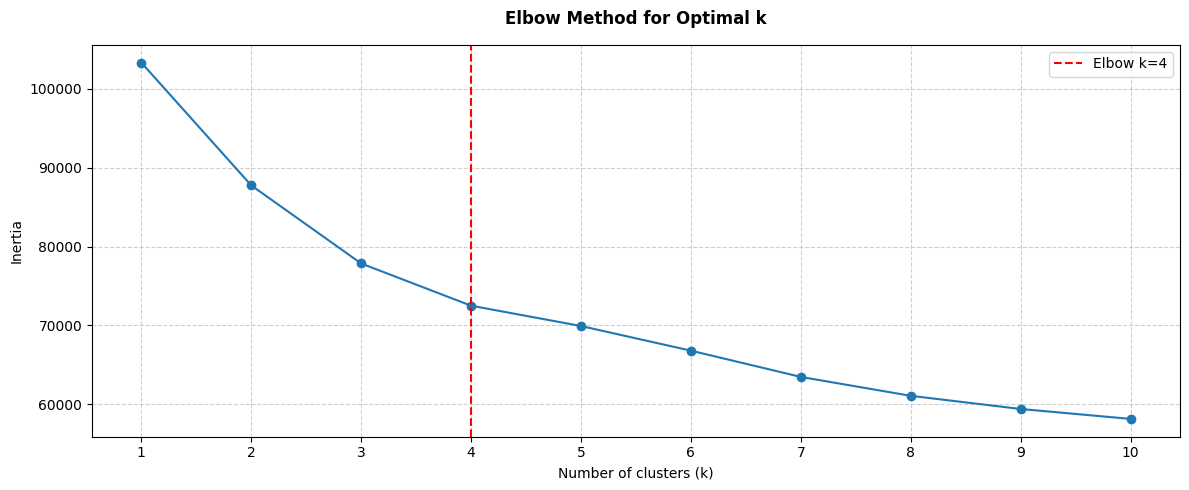

2026-06-01 17:21:51 | INFO | Optimal k suggested by Elbow: 4


In [62]:
# If X_prepared is sparse, convert to dense
X_use = X_prepared.toarray() if hasattr(X_prepared, "toarray") else X_prepared

# --- Elbow Method ---
inertia = []
K_elbow = range(1, 11)  # k = 1..10
for k in K_elbow:
    kmeans = KMeans(n_clusters=k, random_state=config.random_state, n_init="auto")
    kmeans.fit(X_use)
    inertia.append(kmeans.inertia_)

# Find the elbow point
kneedle = KneeLocator(list(K_elbow), inertia, curve="convex", direction="decreasing")
k_best_elbow = kneedle.knee

# Plot Elbow
plt.figure(figsize=(12, 5))
plt.plot(list(K_elbow), inertia, marker="o", linestyle="-")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k", fontsize=12, pad=15, weight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(range(1, 11))

# Mark elbow if found
if k_best_elbow is not None:
    plt.axvline(k_best_elbow, linestyle="--", label=f"Elbow k={k_best_elbow}", color = "red")
    plt.legend()

plt.tight_layout()
plt.show()

logger.info(f"Optimal k suggested by Elbow: {k_best_elbow}")

In [63]:
# Fit K-means with the chosen number of clusters (k=k_best_elbow following Elbow Method)
kmeans = KMeans(n_clusters=k_best_elbow, random_state=config.random_state, n_init="auto")
kmeans.fit(X_use)

# Assign clusters and calculate distance to cluster centroid
df_merged["Cluster"] = kmeans.labels_
df_merged["DistanceToCentroid"] = np.linalg.norm(X_use - kmeans.cluster_centers_[kmeans.labels_], axis=1)
df_merged["Cluster"] = df_merged["Cluster"].replace({0: "Cluster 0", 1: "Cluster 1", 2: "Cluster 2", 3: "Cluster 3"})

# --- PCA Visualization using Seaborn ---
# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2, random_state=config.random_state)
X_pca = pca.fit_transform(X_use)

# Add PCA components to dataframe
df_merged["PCA1"] = X_pca[:, 0]
df_merged["PCA2"] = X_pca[:, 1]

# Transform centroids into PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Plotly Visualization
fig = go.Figure()

# Color palette (clean & readable)
cluster_colors = {
    "Cluster 0": "#00B894",
    "Cluster 1": "#FDCB6E",
    "Cluster 2": "#0984E3",
    "Cluster 3": "#D63031"
}

# ---- Scatter points by cluster ----
for cluster, color in cluster_colors.items():
    cluster_df = df_merged[df_merged["Cluster"] == cluster]

    fig.add_trace(
        go.Scatter(
            x=cluster_df["PCA1"],
            y=cluster_df["PCA2"],
            mode="markers",
            name=cluster,
            marker=dict(
                size=8,
                color=color,
                opacity=0.8,
                line=dict(width=0.5, color="black")
            ),
            text=cluster_df["Cluster"],
            customdata=cluster_df["DistanceToCentroid"],
            hovertemplate=(
                "<b>%{text}</b><br>"
                "PCA1: %{x:.2f}<br>"
                "PCA2: %{y:.2f}<br>"
                "Distance to centroid: %{customdata:.2f}"
                "<extra></extra>"
            )
        )
    )

# ---- Centroids ----
fig.add_trace(
    go.Scatter(
        x=centroids_pca[:, 0],
        y=centroids_pca[:, 1],
        mode="markers",
        name="Centroids",
        marker=dict(
            size=18,
            symbol="x",
            color="purple",
            line=dict(width=2)
        ),
        hovertemplate=(
            "<b>Centroid</b><br>"
            "PCA1: %{x:.2f}<br>"
            "PCA2: %{y:.2f}<extra></extra>"
        )
    )
)

# Layout
fig.update_layout(
    title=dict(
        text="<b>K-Means Clusters Visualized with PCA (2D)</b>",
        font=dict(size=12, family="Segoe UI", color="white")
    ),
    xaxis=dict(title = dict(text="Principal Component 1", font=dict(size=12, family="Segoe UI", color="white")), showgrid=True),
    yaxis=dict(title = dict(text="Principal Component 2", font=dict(size=12, family="Segoe UI", color="white")), showgrid=True),
    template="plotly_dark",
    width=1500,
    height=600,
    legend = dict(orientation="h", title="Cluster"),
    hovermode="closest"
)

fig.add_annotation(
    text="Created By Thuan Dao.",
    xref="paper", yref="paper",
    x=1, y=-0.15,
    showarrow=False,
    font=dict(size=10, color="white", family="Segoe UI")
)

fig.show()

In [64]:
num_features = ["Sales", "Quantity", "Discount", "Profit", "Spend"]
new_cat_features = ["Segment", "ShipMode", "Category", "Region", "rfm_segment"]

def plot_boxplots_plotly(df, num_features, n_cols=4):
    """
    Plot boxplots of numerical features by Cluster using Plotly.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing Cluster and numerical features.
    num_features : list
        List of numerical feature names.
    n_cols : int, default=4
        Number of columns in subplot layout.
    """

    if not num_features:
        print("No numerical features provided!")
        return

    # Determine layout
    n_rows = int(np.ceil(len(num_features) / n_cols))

    fig = make_subplots(
        rows=n_rows,
        cols=n_cols,
        subplot_titles=[f"<b>Box plot of {f} by Cluster</b>" for f in num_features],
        horizontal_spacing=0.08,
        vertical_spacing=0.1
    )

    clusters_order = ["Cluster 0", "Cluster 1", "Cluster 2", "Cluster 3"]

    # Color palette
    cluster_colors = {
    "Cluster 0": "#00B894",
    "Cluster 1": "#FDCB6E",
    "Cluster 2": "#0984E3",
    "Cluster 3": "#D63031"
    }

    # Add boxplots
    for i, feature in enumerate(num_features):
        row = i // n_cols + 1
        col = i % n_cols + 1

        for cluster in clusters_order:
            cluster_df = df[df["Cluster"] == cluster]

            fig.add_trace(
                go.Box(
                    y=cluster_df[feature],
                    name=cluster,
                    marker_color=cluster_colors[cluster],
                    boxmean="sd",        # show mean & std
                    width=0.5,
                    showlegend=(i == 0)  # show legend only once
                ),
                row=row,
                col=col
            )
    # Layout styling and configuration
    fig.update_annotations(font=dict(family="Segoe UI", size=12, color="white"))

    # Layout
    fig.update_layout(
        title=dict(
            text="<b>Boxplot Overview of Numerical Features</b>",
            x=0.5,
            font=dict(size=15)
        ),
        template="plotly_dark",
        height=500 * n_rows,
        width=1500,
        legend = dict(orientation="h", title="Cluster"),
        boxmode="group",
        hovermode="x unified"
    )
    fig.update_xaxes(title_font=dict(family="Segoe UI", size=12, color="white"))
    fig.update_yaxes(title_font=dict(family="Segoe UI", size=12, color="white"))

    fig.add_annotation(
        text="Created By Thuan Dao.",
        xref="paper", yref="paper",
        x=1, y=-0.15,
        showarrow=False,
        font=dict(size=10, color="white", family="Segoe UI")
    )

    fig.show()

plot_boxplots_plotly(df=df_merged, num_features=num_features, n_cols=3)


In [65]:
def plot_countplots_plotly(df, cat_features, n_cols=2):
    """
    Plot countplots of categorical features by Cluster using Plotly.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe containing categorical features and Cluster.
    cat_features : list
        List of categorical feature names.
    n_cols : int, default=2
        Number of columns in subplot layout.
    """

    if not cat_features:
        print("No categorical features provided!")
        return

    # Layout
    n_rows = int(np.ceil(len(cat_features) / n_cols))

    fig = make_subplots(
        rows=n_rows,
        cols=n_cols,
        subplot_titles=[f"<b>Count of {f} by Cluster</b>" for f in cat_features],
        horizontal_spacing=0.08,
        vertical_spacing=0.1
    )

    clusters = sorted(df["Cluster"].unique())

    # Color palette
    cluster_colors = {
    "Cluster 0": "#00B894",
    "Cluster 1": "#FDCB6E",
    "Cluster 2": "#0984E3",
    "Cluster 3": "#D63031"
    }

    for i, feature in enumerate(cat_features):
        row = i // n_cols + 1
        col = i % n_cols + 1

        # Count values
        count_df = (
            df.groupby([feature, "Cluster"])
              .size()
              .reset_index(name="count")
        )

        for cluster in clusters:
            cluster_data = count_df[count_df["Cluster"] == cluster]

            fig.add_trace(
                go.Bar(
                    x=cluster_data[feature].astype(str),
                    y=cluster_data["count"],
                    name=cluster,
                    marker_color=cluster_colors.get(cluster, "#95a5a6"),
                    text=cluster_data["count"],
                    textposition="outside",
                    showlegend=(i == 0)
                ),
                row=row,
                col=col
            )

    # Layout styling and configuration
    fig.update_annotations(font=dict(family="Segoe UI", size=12, color="white"))

    # Layout
    fig.update_layout(
        title=dict(
            text="<b>Countplot Overview of Categorical Features</b>",
            x=0.5,
            font=dict(size=16)
        ),
        template="plotly_dark",
        height=500 * n_rows,
        width=1800,
        legend = dict(orientation="h", title="Cluster"),
        barmode="group",
        hovermode="x unified"
    )

    fig.add_annotation(
        text="Created By Thuan Dao.",
        xref="paper", yref="paper",
        x=1, y=-0.15,
        showarrow=False,
        font=dict(size=10, color="white", family="Segoe UI")
    )

    # Improve axes readability
    fig.show()

plot_countplots_plotly(df=df_merged, cat_features=new_cat_features, n_cols=2)

**Updated Customer Profiling by Cluster**

**Cluster 0 – Low-Value / Low-Engagement Customers**

* Lowest **sales, spend, and profit contribution**
* Small order sizes and lower purchasing quantity
* Few high-value transactions and very limited outliers
* Mainly buys **Office Supplies**
* Large share of **At Risk** customers
* Mostly **Consumer segment**
* Strong preference for **Standard Class**
* Represents customers with **low activity and weak retention potential**
* Best managed through **low-cost engagement strategies**

**Cluster 1 – High-Spending but Volatile Customers**

* Highest **sales, spend, and quantity per order**
* Contains many extreme outliers with very large purchases
* Highest profit variability, including some major losses
* More aggressive purchasing behavior
* Strong presence in **Furniture** and **Technology**
* High concentration of **Champions** and **Loyal** customers
* Strongly active in **West and East**
* Mostly uses **Standard Class**, but also higher use of premium shipping
* Represents a **high-revenue but high-risk segment**
* Requires tighter **discount and margin control**

**Cluster 2 – Stable Low-Contribution Customers**

* Low sales and spending with very stable behavior
* Very small spread across sales and profit distributions
* Lower quantity per order
* Few outliers and low operational risk
* Dominated by **Office Supplies**
* Highest share of **Potential Loyalists**
* Mostly Consumer customers with standard shipping behavior
* Represents customers with **moderate retention potential but currently low value**
* Good target for **upselling and nurturing campaigns**

**Cluster 3 – High-Value Growth Customers**

* Strong sales, spend, and profit performance
* High purchasing quantity with frequent large transactions
* Large profit spread, but more balanced than Cluster 1
* Strong contribution across **Technology** and **Office Supplies**
* High counts of **Champions**, **Loyal**, and **Potential Loyalists**
* Strong regional presence in **West and East**
* Heavy use of **Standard Class**
* Represents a scalable **core growth segment**
* High potential for **retention, cross-sell, and loyalty programs**

**Overall Business Insight**

> * Customer value is concentrated mainly in **Clusters 1 and 3**.
> * **Cluster 1** generates the largest transactions but also introduces significant volatility and profitability risk.
> * **Cluster 3** appears to be the healthiest growth segment with strong and relatively balanced performance.
> * Meanwhile, **Clusters 0 and 2** contribute lower business value and are better suited for cost-efficient servicing and targeted nurturing strategies.

In [66]:
def world_map_transaction_2(df=df_merged, feature = "State", cluster_id = "Cluster 0", logger=logger):
    """
    Create an interactive world (state-level) transaction map using Folium.

    This function:
    - Geocodes each unique state to obtain latitude & longitude
    - Attaches aggregated transaction metrics to each location
    - Visualizes results on a dark-themed Folium map with interactive tooltips

    Parameters
    ----------
    df : pandas.DataFrame, default=df_state

    feature : str, default="State"
        Column name representing geographic locations to be geocoded.

    cluster_id : int  
        The target cluster to visualize on the world map.

    logger : logging.Logger
        Logger instance for tracking progress and errors.

    Returns
    -------
    folium.Map
        An interactive Folium map object with transaction markers.
    """

    # 1. Copy input DataFrame to avoid modifying original data
    df_location = df.copy()

    # Filter: Only fraud transactions belonging to the selected cluster
    df_state = df_location[(df_location["Cluster"] == cluster_id)]

    df_state = (df_state.groupby(by="State").agg(
                    total_quantity = ("Quantity", "sum"),
                    total_sales = ("Sales", "sum"), # GMV
                    total_discount=("Discount", "sum"),
                    total_profit=("Profit", "sum"),
                    total_spend=("Spend", "sum"),
                    orders_count=("OrderID", "nunique")
                )
                .sort_values("total_sales", ascending=False)
                .reset_index()
    )

    # 2. Extract unique geographic locations (states)
    unique_state = df_state[feature].unique()
    state_coords = {}

    # 3. Initialize geocoder with rate limiting
    #    - Prevents hitting API request limits
    #    - Retries automatically on temporary failures
    geolocator = Nominatim(user_agent="location_mapper")
    geocode = RateLimiter(
        geolocator.geocode,
        min_delay_seconds=1,
        max_retries=3,
        error_wait_seconds=3,
        swallow_exceptions=False
    )

    logger.info(f"Fetching coordinates for {len(unique_state)} unique state...")

    # 4. Fetch latitude & longitude for each state
    for state in unique_state:
        try:
            loc = geocode(f"{state}", timeout=15)
            if loc:
                state_coords[state] = (loc.latitude, loc.longitude)
            else:
                logger.warning(f"Coordinates not found for {state}")
        except Exception as e:
            logger.error(f"Error fetching coordinates for {state}: {e}")

    # 5. Map coordinates back to DataFrame
    df_state[feature] = df_state[feature].astype(str)
    df_state["Coordinates"] = df_state[feature].map(state_coords)
    df_state = df_state[df_state["Coordinates"].apply(lambda x: isinstance(x, (list, tuple)) and len(x) == 2)]

    # 6. Initialize Folium map
    #    - Centered at the first available coordinate
    if len(state_coords) > 0:
        initial_coords = list(state_coords.values())[0]
    else:
        logger.warning("No coordinates found — initializing map")
        initial_coords = [0, 0]

    mymap = folium.Map(location=initial_coords, zoom_start=5, tiles="CartoDB dark_matter")

     # 7. Add markers with rich HTML tooltips
    for _, row in df_state.iterrows():
        coords = row["Coordinates"]

        tooltip_html = f"""
        <div style='font-size:13px; line-height:1.5'>
            <b>State:</b> {row[feature]}<br>
            <b>Number Order:</b> {row['orders_count']}<br>
            <b>Total Quantity:</b> {row['total_quantity']:,.0f}<br>
            <b>Total Discount:</b> {row['total_discount']:,.2f}<br>
            <b>GMV:</b> ${row['total_sales']:,.2f}<br>
            <b>Total Profit:</b> ${row['total_profit']:,.2f}<br>
            <b>Total Spend:</b> ${row['total_spend']:,.2f}<br>
        </div>
        """

        folium.Marker(
            location=coords,
            tooltip=folium.Tooltip(tooltip_html, sticky=True),
            icon=folium.Icon(color="lightgray", icon="info-sign")
        ).add_to(mymap)

    # 8. Save map to HTML file
    map_path = f"./saved-map-{cluster_id.replace(' ', '_')}.html"
    mymap.save(map_path)
    logger.info(f"Map saved successfully: {map_path}")

    return mymap

In [67]:
world_map_transaction_2(cluster_id="Cluster 0")

2026-06-01 17:21:52 | INFO | Fetching coordinates for 46 unique state...
2026-06-01 17:22:37 | INFO | Map saved successfully: ./saved-map-Cluster_0.html


In [68]:
world_map_transaction_2(cluster_id="Cluster 1")

2026-06-01 17:22:37 | INFO | Fetching coordinates for 46 unique state...
2026-06-01 17:23:22 | INFO | Map saved successfully: ./saved-map-Cluster_1.html


In [69]:
world_map_transaction_2(cluster_id="Cluster 2")

2026-06-01 17:23:22 | INFO | Fetching coordinates for 47 unique state...
2026-06-01 17:24:08 | INFO | Map saved successfully: ./saved-map-Cluster_2.html


In [70]:
world_map_transaction_2(cluster_id="Cluster 3")

2026-06-01 17:24:08 | INFO | Fetching coordinates for 48 unique state...
2026-06-01 17:24:56 | INFO | Map saved successfully: ./saved-map-Cluster_3.html


<!-- Include Google Fonts for a modern font -->
<link href="https://fonts.googleapis.com/css2?family=Roboto:wght@700&display=swap" rel="stylesheet">

<div style="
    border-radius: 15px; 
    border: 2px solid #003366; 
    padding: 10px; 
    background: linear-gradient(135deg, #3a0ca3, #7209b7 30%, #f72585 80%);
    text-align: center; 
    box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.5);
">
    <h1 style="
        color: #FFFFFF; 
        text-shadow: 2px 2px 4px rgba(0, 0, 0, 0.7); 
        font-weight: bold; 
        margin-bottom: 5px; 
        font-size: 28px; 
        font-family: 'Roboto', sans-serif;
        letter-spacing: 1px;
    ">
        🙏 Thanks for Reading! 🚀
    </h1>
    <p style="color: #ffffff; font-size: 18px; text-align: center;">
        Happy Coding! 🙌😊
    </p>
</div>
